Dylan Ross

Perform basic differential expression analysis (Welch's t-test) to identify top features within each block for all mutation state comparisons.

## Setup

### Imports

In [ ]:
import os
import pickle

import polars as pl
from scipy import stats
from matplotlib import pyplot as plt, rcParams

# set max font size 
rcParams["font.size"] = 7

### Constants

In [2]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures",
    "volcano"
)

# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
    "diffex"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

### Load Data

#### Utility Function: Load a mutant vs. WT comparison data subset, add ∆z and t-test p-value

In [3]:
def load_data_add_delta_z_and_ttest_p(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset, 
    adds ∆z and t-test p-value columns for the comparison of mutant vs. WT samples
    """
    # load subset sample columns
    with open(os.path.join(CACHE_DIR, f"{subset_id}_cols.pkl"), "rb") as pf:
        wt_cols, mut_cols = pickle.load(pf)

    # load subset omics data
    omics_subset = pl.read_ipc(os.path.join(CACHE_DIR, f"{subset_id}.arrow"))

    # select out the block of interest, add columns, return
    return (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
        # add the ∆z and t-test p-value columns
        .with_columns(
            (
                pl.concat_list(wt_cols)
                .list.drop_nulls()
                .alias("wt")
            ),
            (
                pl.concat_list(mut_cols)
                .list.drop_nulls()
                .alias("mut")
            ),
        )
        .with_columns(
            (
                (
                    pl.col("mut").list.mean() - pl.col("wt").list.mean()
                )
                .alias("delta_z")
            ),
            (
                pl.struct("wt", "mut")
                .map_elements(
                    lambda x: stats.ttest_ind(
                        x["wt"], 
                        x["mut"], 
                        equal_var=False  # Welch's t-test
                    ).pvalue,  # type: ignore
                    return_dtype=pl.Float64
                )
                .alias("ttest_p")
            )
        ).drop(
            "wt",
            "mut"
        )
    )

#### Load data for all comparisons

In [4]:
comps = {
    (subset_id, block): load_data_add_delta_z_and_ttest_p(subset_id, block)
    for subset_id in [
        "B_NPM1-WT", 
        "W_NPM1-WT", 
        "B_FLT3-ITD-WT", 
        "W_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT", 
        "W_FLT3-ITDxNPM1-WT"
    ]
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics"
    ]
} | {
    (subset_id, "Acetylomics"): load_data_add_delta_z_and_ttest_p(subset_id, "Acetylomics")
    for subset_id in [
        "B_NPM1-WT", 
        "B_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT"
    ]
}

/Users/dylan.ross/Projects/AML_outcome_disparities/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260311_analysis/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_

## Volcano Plots

### Utility Functions

#### Make the volcano plot

In [5]:
def volcano_plot(
    df, 
    min_abs_delta_z, 
    max_p_value, 
    figname=None, 
    delta_z_range=None, 
    point_labels=None
) :
    def _get_color(fold_change, p_value):
        if p_value <= max_p_value:
            if fold_change >= min_abs_delta_z:
                return RED
            if fold_change <= -min_abs_delta_z:
                return BLUE
        # default color
        return GREY
    fig, ax = plt.subplots(figsize=(4, 4))
    c = [
        _get_color(dz, pv)
        for dz, pv in df.select("delta_z", "ttest_p").iter_rows()
    ]
    ax.scatter(df["delta_z"], df["ttest_p"], c="#00000000", marker="o", edgecolors=c, s=6, linewidths=1.)
    # add point labels if provided
    if point_labels is not None:
        for lbl, dz, pv in point_labels.iter_rows():
            ax.plot(
                [dz, dz + 0.2 if dz > 0 else dz - 0.2],
                [pv, pv],
                #c=_get_color(dz, pv),
                c="k",
                lw=0.5, 
                marker=".",
                ms=2
            )
            ax.text(
                dz + 0.15 if dz > 0 else dz - 0.15,
                pv,
                lbl,
                color=_get_color(dz, pv),
                size=6, 
                va="center",
                ha="left" if dz > 0 else "right",
                #rotation=-15 if dz > 0 else 15,
                rotation_mode="anchor", 
                bbox=dict(
                    fc="w",
                    #ec=_get_color(dz, pv),
                    ec="k",
                    lw=0.5,
                    pad=0.3
                )
            )
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(max_p_value, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(-min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(0, lw=1., c="k", zorder=-1)
    for d in ["top", "left", "right"]:
        ax.spines[d].set_visible(False)
    if delta_z_range is not None:
        ax.set_xlim(delta_z_range)
    ax.set_xlabel("∆z")
    ax.set_ylabel("p-value")
    if figname is not None:
        plt.savefig(figname, bbox_inches="tight", transparent=True, dpi=400)
    plt.show()
    plt.close()

#### Make the plot plus select out the top/bottom features

In [6]:
def plot_volcano_and_select_top_features(
    df,
    dz, 
    pv,
    subset,
    block,
    label_top_n=10,
    export_top_n=200
) : 
    # select the top up/down features
    top_up = (
        df
        .filter(
            (pl.col("ttest_p") <= pv)
            & (pl.col("delta_z") >= dz)
        )
    )
    top_down = (
        df
        .filter(
            (pl.col("ttest_p") <= pv)
            & (pl.col("delta_z") <= -dz)
        )
    )
    # make the plot
    volcano_plot(
        df,
        dz,
        pv,
        figname=os.path.join(
            FIGURE_DIR, 
            f"{subset}_{block}.png"
        ),
        # add text labels for the top N up and down features 
        point_labels=(
            pl.concat([
                (
                    top_up
                    .select(
                        "Feature",
                        "delta_z",
                        "ttest_p"
                    )
                    .sort("ttest_p")
                    .head(label_top_n)
                ),
                (
                    top_down
                    .select(
                        "Feature",
                        "delta_z",
                        "ttest_p"
                    )
                    .sort("ttest_p")
                    .head(label_top_n)
                ),
            ])
        )
    )
    # write top up/down features to file
    for df, up_or_down in [(top_up, "up"), (top_down, "down")]:
        if len(df) > 0:
            # write just the identified features
            (
                df
                .sort("ttest_p")
                .head(export_top_n)
                .select("Feature")
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.txt"
                    ),
                    include_header=False
                )
            )
            # write the full table
            (
                df
                .sort("ttest_p")
                .head(export_top_n)
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.csv"
                    ),
                )
            )
    # return the selected top up/down features (+ their full data)
    return top_up, top_down

### Make the volcano plots for selected comparisons

============ B_NPM1-WT ============
Transcriptomics


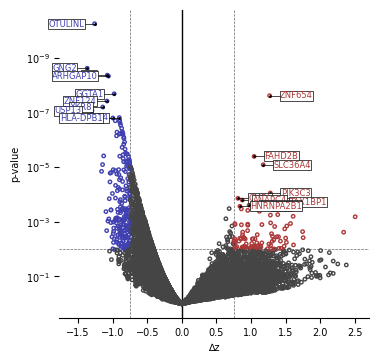

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CIAPIN1""",null,-1.418768,-0.407063,-0.678315,-3.41901,null,-0.729438,-0.5369,null,0.088611,null,-0.217184,-0.257256,1.241435,1.126426,0.554071,0.965613,-0.59479,-0.42782,0.208009,1.538694,0.574275,0.531435,1.533792,null,1.371702,null,null,null,null,0.004631,-0.127785,-0.814983,1.475889,-0.83392,null,…,null,0.966019,-1.412289,null,-0.132592,-0.670483,null,null,null,1.505092,-0.018376,-0.747354,-0.720849,-0.208407,0.067972,-0.662593,null,-1.156676,0.12513,0.26051,-1.627842,null,null,null,null,1.270434,null,null,0.610503,0.878025,1.038906,0.040376,0.226011,null,null,0.76032,0.00896
"""MRE11""",null,-1.208952,1.047163,0.652233,-1.519555,null,-0.084362,-0.008857,null,-0.092804,null,-0.674892,-0.144425,-0.857289,0.467048,-0.774883,2.020149,-0.317208,0.341278,-0.41608,-1.323226,0.943526,-1.01661,4.039439,null,-0.54497,null,null,null,null,0.081666,1.817147,0.777203,-0.958611,-0.22688,null,…,null,-0.125658,-0.001946,null,-0.573925,-0.450631,null,null,null,-0.921674,-1.017899,0.159366,-0.251097,-0.878122,-0.327722,-0.929682,null,-0.485981,-0.743172,1.39347,-1.49637,null,null,null,null,1.416046,null,null,1.026414,0.708799,0.83355,0.646589,0.069063,null,null,0.879338,0.002376
"""FAM136A""",null,-1.364976,1.219096,-0.589182,-3.026094,null,0.998563,0.427234,null,0.472224,null,-0.357872,2.265376,1.223518,-0.673752,-0.222469,1.826437,-0.072234,-0.381181,0.483184,-0.225353,-0.074087,-1.135558,1.472696,null,-0.090471,null,null,null,null,0.228984,1.445207,0.840362,0.212729,-0.302112,null,…,null,-0.287253,-0.772832,null,-0.645971,0.830143,null,null,null,-1.272455,-0.925587,-0.09261,-0.428006,-0.474645,-0.140982,-1.362385,null,-0.765154,-1.504965,0.365758,-1.327256,null,null,null,null,1.138752,null,null,0.825181,0.266561,1.384166,0.172298,0.779804,null,null,0.854326,0.004269
"""MAPK9""",null,-0.776974,1.070059,1.162617,-1.048198,null,-0.623871,0.138046,null,-0.433709,null,-0.634687,0.374882,0.032108,0.334261,-0.938757,1.629227,-0.086986,0.849468,-0.255528,-0.897595,0.804211,-0.726898,4.166605,null,-0.375966,null,null,null,null,-0.681958,0.653001,1.637971,0.220757,-0.383624,null,…,null,0.691253,0.055848,null,-0.194604,0.733863,null,null,null,-0.984234,-1.05215,-0.36259,-0.164172,-1.249335,0.234102,-1.630511,null,-0.615035,-0.851754,0.412064,-1.93195,null,null,null,null,0.699412,null,null,0.606615,1.401289,1.063396,-0.033155,1.156839,null,null,0.915618,0.004228
"""ANAPC4""",null,-1.595616,2.549508,0.175788,-2.782017,null,0.200929,-0.139013,null,0.034589,null,-0.785694,0.34801,-0.340101,0.249953,-0.917398,2.791867,-0.124896,-0.578339,-1.128325,-1.290254,-0.220752,-1.439553,2.405581,null,-0.340728,null,null,null,null,-0.747246,1.1308,0.810742,-0.308736,-0.480964,null,…,null,0.863943,-0.487985,null,-0.184308,-0.735184,null,null,null,-0.701363,-0.696147,-0.361811,0.41006,0.479999,0.425293,-0.194115,null,-0.453027,-0.6337,1.43195,-0.36018,null,null,null,null,1.109289,null,null,0.787623,1.074531,0.876899,0.469454,0.353186,null,null,0.873823,0.0

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MCUB""",null,1.065172,-0.418198,-0.246708,-0.652201,null,-1.247145,0.495031,null,0.618782,null,-0.646523,0.736239,0.225911,0.029019,-0.946468,2.677934,0.898552,0.170946,2.608596,0.060891,0.311312,-1.129196,-0.995128,null,-0.456792,null,null,null,null,-1.140642,-0.999883,-0.815733,1.900348,-0.071013,null,…,null,1.406946,-0.906663,null,-0.594937,-0.778231,null,null,null,-0.611734,0.872667,0.108321,-0.88195,1.837571,-0.301961,1.823072,null,0.557875,1.021402,1.24399,-1.151542,null,null,null,null,-0.737566,null,null,-0.489747,-0.840579,-1.384387,-0.606327,-0.510034,null,null,-0.854678,0.000356
"""CEACAM21""",null,-0.027438,-0.112613,0.829789,-1.400774,null,0.4681,-0.513615,null,1.314176,null,-0.640689,1.826389,2.092479,0.210638,-0.008462,2.635976,-0.50695,-0.15882,1.12693,-0.286078,1.088341,-0.585631,-1.145909,null,-0.51834,null,null,null,null,2.400572,0.003506,1.854098,0.3249,-0.309213,null,…,null,-0.662803,-0.597205,null,-0.839865,-0.171305,null,null,null,-0.091534,0.184678,0.02409,0.836407,0.162665,-0.686637,0.060601,null,-1.028016,-1.076809,2.615661,0.267856,null,null,null,null,-1.208071,null,null,-1.028959,-1.001929,0.225074,-1.163114,-1.050647,null,null,-0.977961,0.004169
"""MATK""",null,-1.030829,1.69059,-0.332423,3.330042,null,1.367093,1.520024,null,0.490773,null,-0.265969,0.175988,1.993802,-0.550483,0.05749,0.632846,0.289106,0.381188,1.507522,1.307972,0.756294,-1.057507,-0.433391,null,-1.375176,null,null,null,null,0.12092,0.078896,1.732776,-0.174997,-0.488454,null,…,null,0.534957,-0.170925,null,-0.77339,1.171006,null,null,null,-0.849223,-0.171496,-0.152966,-0.636479,-1.620702,-1.193244,-0.482161,null,-0.546925,-1.310924,-1.343077,-1.341721,null,null,null,null,-0.409394,null,null,-0.745057,-0.95508,-0.370973,-0.595453,-1.241157,null,null,-0.807623,0.000649
"""RPUSD1""",null,-1.422576,1.223498,-0.811592,0.828906,null,-0.009467,1.437642,null,0.057854,null,0.661066,-1.0736,1.839718,-0.755976,0.692882,1.212074,0.297989,0.005427,1.069393,-0.427239,1.147521,-1.464547,1.42475,null,-1.467345,null,null,null,null,1.294526,-0.801299,-0.180081,1.242716,0.666532,null,…,null,-0.683946,-0.595691,null,0.240703,0.083873,null,null,null,2.687846,0.087877,0.764125,-0.448837,0.040784,-0.0751,2.324013,null,-1.071941,-1.541173,-0.074782,-1.431151,null,null,null,null,-0.835042,null,null,-0.711898,-0.678023,-1.228431,-0.498878,-1.077221,null,null,-0.940891,0.000018
"""TSR3""",null,-0.151508,0.074485,-0.517566,4.024491,null,-0.633472,0.884893,null,-0.310089,null,-0.251855,0.091691,0.439315,-1.035508,-0.309903,1.491089,0.811032,0.141521,1.45554,-0.225628,0.38289,-1.293053,-0.422587,null,-1.655078,null,null,null,null,0.520663,-0.599446,1.401323,1.000751,0.414654,null,…,null,-1.237413,0.20159,null,0.559743,1.075881,null,null,null,1.594234,0.449522,-0.574385,-1.0271,0.561669,-0.246862,0.336065,null,-0.617361,-0.39901,0.725596,-1.871403,null,null,null,null,-0.33229,null,null,-0.644337,-1.245917,-0.923295,-0.945649,-0.895305,null,null,-0.932904,

Proteomics


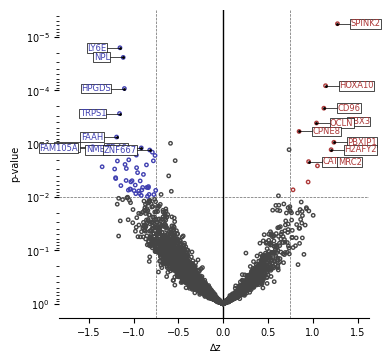

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ATP8B4""",-0.82754,1.191326,-0.580083,-0.031687,null,null,null,null,null,null,-1.644191,-1.002383,-1.761926,-1.259805,-0.814558,-1.718367,-1.236569,-2.551685,-0.182197,-0.79815,1.03107,-1.070946,-0.310645,-0.272563,0.363773,0.53989,-0.998695,-0.930064,0.424567,-0.500973,-2.171013,0.952665,-0.151611,0.28517,-0.522613,1.499142,…,0.381262,-2.797841,-1.12422,0.267145,0.11061,-1.140175,0.524447,0.066189,1.911065,0.223933,1.145049,0.606927,0.423116,1.101346,-0.350735,0.449943,0.872374,-0.457761,0.840368,-0.319348,0.141629,1.389604,-1.172613,0.127639,0.69232,null,null,0.279617,0.220311,0.262749,2.144563,1.239107,0.899336,-0.216925,1.107627,0.779578,0.007322
"""CAT""",-0.131117,0.131812,-0.973319,1.025617,null,null,null,null,null,null,-2.03785,-1.56646,-0.286758,-1.96826,-1.461018,-0.311323,-0.62125,-2.207095,-1.317326,0.769584,-0.439878,-1.447926,-0.820189,0.486788,-0.323553,-0.593299,-0.963967,-1.32495,0.267318,-0.721893,-0.83708,0.360413,-1.157816,2.009841,-1.318455,-0.016539,…,0.869971,-0.99836,-0.063913,1.420023,-0.45705,-0.443872,1.182341,0.165643,0.500843,-0.015043,0.664567,2.826362,-0.628215,0.780882,1.509732,-0.033413,1.186863,0.174022,0.848878,-0.526328,0.504251,0.843508,-1.713623,0.171932,1.121981,null,null,-0.272539,0.000609,0.819766,0.720945,1.184537,1.560468,0.890843,2.065341,0.953525,0.002167
"""CD96""",null,null,-0.699843,-0.263315,null,null,null,null,null,null,0.535876,0.48455,-0.933131,0.499695,-2.487763,-0.520079,0.924051,null,-2.485888,0.797755,-0.141629,-0.886038,0.033234,null,0.49808,1.248686,-1.202261,null,0.22717,-0.63251,0.968503,1.839327,-0.746422,null,null,-1.418558,…,-0.505526,-1.067627,-0.33092,-0.290383,null,0.079998,-0.408677,-0.951747,null,-0.106841,0.668269,-0.632279,-0.408156,-0.733107,-1.433606,-0.809374,0.439812,-0.537758,0.565708,1.623134,-0.886218,null,-1.160118,null,1.571443,null,null,0.792425,null,0.690221,1.154577,1.368149,0.480272,null,null,1.123799,0.000216
"""CPNE8""",0.178366,0.962533,-0.1186,0.04488,null,null,null,null,null,null,-1.992766,-1.329772,-1.250015,-1.117623,0.377718,-1.731552,-1.045199,-2.367358,0.088457,-0.922766,-0.61893,-0.532004,-1.233543,0.218449,-0.574858,-0.408452,-1.457077,-1.562146,-0.100827,0.279627,-1.449163,-0.770115,0.306695,0.618835,-1.295255,-0.287721,…,1.227563,-1.298279,0.429789,0.552386,0.918275,1.68354,1.39192,0.512073,0.974741,0.206386,0.952438,0.771492,-0.599483,1.485029,1.053501,1.85597,1.37149,-0.08904,1.397861,-0.687735,-0.67724,1.280881,-1.554573,0.159439,0.763139,null,null,-0.086174,0.623523,0.317669,1.436781,1.594456,0.977277,0.629578,0.925571,0.847068,0.000589
"""H2AFY2""",0.708307,0.185285,-0.446767,0.850879,null,null,null,null,null,null,-1.770423,-1.143409,-0.620367,-0.92566,-1.266514,-1.377342,-0.796981,-1.560151,-2.037841,-0.404707,-1.163814,-1.189003,2.022923,-2.330444,0.485065,-0.692036,-1.256093,-0.931098,0.964714,-0.637065,-0.342223,-0.457883,-1.062177,-1.545912,-1.158462,0.63186,…,-0.154502,-0.560636,-0.767512,-0.164423,0.539832,1.2

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",-0.849585,0.015547,-0.395564,-0.898192,null,null,null,null,null,null,-1.679824,-0.251665,0.193138,0.915544,-0.325995,-1.877693,1.327621,-0.847815,1.530777,-0.304214,-0.370946,-0.109135,-0.789633,-0.247103,0.838534,-0.834072,-0.802034,0.756583,-1.008619,0.152007,0.052055,1.088148,1.975611,0.637032,0.377247,0.325839,…,-0.652404,-0.002425,1.142121,2.15251,-0.873016,1.682252,-0.403075,1.339757,-0.042884,0.085292,0.680726,-0.804107,1.711031,0.135673,-0.828339,0.670911,-0.076736,-0.512542,-0.119378,0.691289,-1.521658,1.756305,0.288305,null,-0.073318,null,null,-1.838972,-0.37782,-3.008472,-0.455561,-0.632119,-0.599097,-1.474883,-0.563545,-1.141471,0.006104
"""ALOX12""",null,2.43145,null,null,null,null,null,null,null,null,0.432565,0.416826,0.30262,1.363449,0.23977,0.429405,0.034235,-1.463945,-0.58965,1.546862,0.117842,1.52446,1.416487,-0.925613,-0.874908,-0.784071,-0.74623,0.055452,-2.500077,-0.153398,0.222196,-0.913833,1.070116,0.11177,1.937788,0.171355,…,0.295773,-0.012345,-1.181325,0.960681,0.156305,2.843787,0.472139,-1.264747,-0.184636,-0.100116,0.447489,0.278213,0.050608,-0.208966,-1.205727,0.435118,0.017107,-0.380598,0.077911,-0.79605,-0.460335,0.219084,-0.915812,null,-0.234821,null,null,-1.828784,-1.177702,-0.967485,-0.942971,-0.976509,-0.083319,-0.581378,0.066208,-0.855914,0.002498
"""APP""",-0.371434,1.388209,-0.557631,0.390474,null,null,null,null,null,null,-1.918548,-0.119589,-0.064334,0.191585,-0.309756,-0.243311,1.564406,0.780602,-0.42934,2.094884,-0.296346,0.974404,0.126384,0.165168,-0.190713,0.010174,0.038998,0.566455,-2.270788,0.954003,0.470629,-0.319502,0.686696,0.730197,1.118208,1.106175,…,1.17751,0.931526,-1.603857,0.886378,-0.196879,1.124185,0.462896,0.209033,-0.665832,0.640154,0.261163,-0.407038,1.250202,-0.859207,-2.132373,1.036037,-0.83281,0.16217,-0.502424,0.913598,0.023363,-0.637781,-0.571947,-0.782377,-1.041151,null,null,-1.667161,0.871617,-2.059417,-1.292585,-1.2009,-1.213902,0.404584,-2.40849,-1.198821,0.0045
"""BCAT1""",-0.832455,-0.286519,0.12961,0.541121,null,null,null,null,null,null,-1.509712,-1.442812,-1.294404,-0.683947,-0.530383,-0.345858,-0.206533,1.333509,-0.372268,0.825783,-0.160143,0.029938,0.496682,-0.908349,0.766522,-0.99845,0.672324,1.000122,-1.226172,1.327614,1.198486,-1.270282,0.660339,0.802595,1.447149,-0.156687,…,2.414045,1.990418,-0.766753,0.056085,-0.98105,0.665707,-0.029017,1.377009,-0.003806,1.041842,0.18551,-0.478944,0.759935,-0.79353,-1.831234,0.586823,0.885907,1.087591,-0.361979,1.36969,-0.312255,1.498618,-0.911609,-0.145249,-0.827107,null,null,-2.246358,-0.806101,-1.549637,-0.051252,-0.429053,0.032713,-1.768327,-1.338365,-1.053316,0.002007
"""CD200""",null,null,0.853932,-0.319228,null,null,null,null,null,null,-1.328351,-0.941966,-0.828808,-0.587545,-1.350721,-1.252432,0.904625,-0.2463,0.161741,0.267781,0.286139,0.735405,-0.097235,0.00319,-0.972908,0.399197,0.152813,1.077068,-0.721152,-0.498492,1.139884,1.157714,0.050442,2.01234,0.190469,1.152311,…,0.70783,-0.50384

Phosphoproteomics


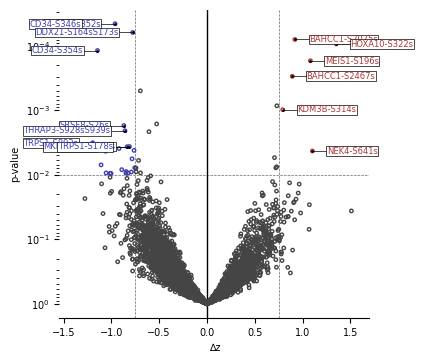

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BAHCC1-S2075s""",null,-0.58789,0.11932,0.242958,null,null,null,null,null,null,-1.504016,null,-2.014588,-1.780984,-0.613034,-1.912709,0.61726,-0.803893,-0.613718,-0.189799,-0.887435,-0.970822,-0.124342,-0.13121,-0.96563,0.387523,-1.507917,-1.108506,0.364823,null,1.26166,1.581598,null,0.728934,-0.736349,null,…,0.434047,null,-0.119811,1.506884,-0.516223,-1.121959,0.112989,-0.114056,1.437317,0.150892,null,0.821911,-0.350268,null,-0.707768,0.014628,0.236822,-0.871159,null,1.375658,-1.322976,1.98492,-0.921086,0.865073,0.437001,null,null,0.640923,0.442551,null,1.158711,0.562104,0.567005,1.746793,0.671337,0.919268,0.00008
"""BAHCC1-S2467s""",-1.673905,null,null,0.115639,null,null,null,null,null,null,-0.608553,0.271333,-2.09602,null,-1.711241,-1.216738,0.822056,-0.484808,-0.34288,0.880922,null,-0.892753,0.207428,-0.103979,-0.993905,null,-1.6395,-0.417913,0.461338,-0.612037,null,1.526063,0.702183,0.610008,0.014548,-2.061676,…,0.453889,-0.168338,0.151275,null,-1.281223,-1.149027,-0.679175,0.163815,0.956333,-0.37828,-0.127769,0.802121,-0.964425,1.0312,-0.936144,0.170895,null,-0.545553,-0.177366,1.773592,-0.549172,-0.326648,null,1.094408,1.136995,null,null,null,0.610634,-0.030686,0.730374,0.97953,null,0.427897,1.265628,0.891936,0.000297
"""HOXA10-S322s""",null,-0.476064,0.525419,null,null,null,null,null,null,null,-1.286872,null,null,-0.540427,0.084611,-1.258662,0.085059,-1.496873,null,-0.455259,-1.128042,null,-0.315392,1.320067,null,-1.201717,-0.753161,-1.659211,-0.00818,null,0.172259,null,1.078743,-0.446678,-0.794602,null,…,0.622428,-1.311368,0.839092,0.510655,0.526433,0.162578,0.525077,null,-0.86158,0.201121,-1.104381,null,0.452488,1.846281,0.59169,null,1.468494,-0.787732,1.222928,0.11144,null,-0.465238,-0.129071,1.501511,0.044947,null,null,1.463382,0.921179,0.622814,null,null,1.318389,1.703593,1.724321,1.352316,0.000094
"""KDM3B-S314s""",-2.078468,-0.431329,1.189013,-0.350903,null,null,null,null,null,null,-1.607079,-1.088739,-2.505129,-1.057342,-0.009063,-0.367264,0.879154,-0.091642,0.191533,-1.607667,-1.605712,-0.29096,-0.512191,1.66883,-0.869372,-0.130871,-0.678441,-0.73041,-0.70156,-0.654277,1.271429,0.553042,-1.247063,0.550044,0.934806,-1.215995,…,1.765624,-0.040661,-0.296391,0.968684,0.082087,-0.350456,-0.599797,0.497899,1.132103,1.191031,1.077351,0.651609,0.503641,1.535181,0.272457,0.187304,0.703769,-0.044473,-0.119312,2.23676,-2.094976,-1.553405,-0.721516,1.223993,0.351466,null,null,-0.11721,0.785963,0.087888,0.901639,0.304016,0.7148,1.492298,1.122632,0.792402,0.00098
"""MEIS1-S196s""",-1.061377,-0.204675,0.881845,-2.50326,null,null,null,null,null,null,-2.653929,-1.545415,null,-1.624985,-0.526933,-1.787562,-1.028869,-1.343966,-0.799544,-1.258615,-1.01757,0.375486,-1.230246,2.038541,-0.241764,-0.816212,0.976539,-0.356848,0.889271,0.142831,-0.150545,-1.410299,0.618696,0.636566,-0.177313,-0.47035,…,-0.797968,-1.026506,-0.264725,0.21025,1.035078,0.881447,0.675252,0.704632,0.822115,0.118275,-1.08347,1.04197,0.724369,1.008887

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BATF3-S31s""",-1.479216,null,0.175233,0.033991,null,null,null,null,null,null,-1.964694,-1.517812,null,null,null,null,null,0.06894,null,null,null,null,null,-0.513869,null,null,0.720107,-0.186684,-1.41594,0.206511,null,null,1.707963,0.345662,1.757555,0.739623,…,0.41504,0.135094,null,null,-1.105441,-0.746282,null,null,-0.017627,1.990603,0.442775,null,0.347453,-0.131386,null,null,null,0.417569,0.573075,null,null,2.283373,null,-0.384006,-0.494517,null,null,null,-0.931518,-1.682866,null,null,null,-0.467838,-0.334961,-0.846124,0.008922
"""CD34-S346s""",null,0.150103,1.146457,null,null,null,null,null,null,null,-1.149922,-0.060851,-2.452517,0.643332,-0.541031,-1.199828,0.893253,-0.038184,0.266082,-0.984985,-0.650801,-0.107104,0.988585,-1.395415,0.019987,0.045879,0.707656,0.381969,-1.164191,0.564699,0.873279,0.656827,2.198578,0.604281,2.464329,-0.189204,…,-0.352227,0.243007,0.654288,2.011526,1.233424,0.556164,-1.167644,0.780663,-0.341264,0.604038,-0.129598,-0.803628,1.663292,-0.296791,-1.411927,0.914998,-0.267364,-0.499211,-0.509875,0.754526,-1.579142,0.624031,0.366263,-0.825038,-0.276037,null,null,-1.841915,-1.160878,-1.326032,-0.452224,-0.073843,-1.322205,-1.536538,-1.255178,-1.166828,0.000046
"""CD34-S354s""",-1.464052,-0.987074,1.937006,-0.86786,null,null,null,null,null,null,0.183294,0.920068,-2.283773,0.914865,-0.734158,-0.195434,0.183158,0.887895,-0.137577,-1.181492,-0.308595,-0.072617,0.957336,-1.238682,-0.880316,-0.198376,0.409439,1.429781,-0.831151,1.424217,1.206885,0.434905,0.315952,-0.174477,2.495695,0.105425,…,0.145595,1.169317,0.082018,0.539442,-0.373709,-0.264022,-0.885437,1.19372,-0.160496,1.353417,-0.794577,-0.715413,2.234718,-0.680881,-0.9223,0.113883,0.739154,-0.425111,0.628994,0.900161,-1.401151,-0.490282,1.017429,-0.893385,-0.385058,null,null,-1.863285,-1.238113,-1.925147,-0.234924,-0.404849,-1.102898,-1.416046,-0.467493,-1.145907,0.000118
"""CEBPB-S231s""",0.118731,0.267625,-0.034982,-0.386242,null,null,null,null,null,null,-1.319165,0.748109,-2.159125,-2.310513,-0.32023,-1.585303,0.067234,-0.036974,-1.285384,-0.677686,-0.674253,-0.154369,0.005512,-1.433924,-0.740595,1.313206,0.339512,-0.221291,-0.543594,1.238071,0.371512,0.591723,-0.043877,-0.301157,0.168228,-0.628665,…,1.208256,0.032151,-0.677449,-0.103584,-0.412681,-1.521462,1.608757,-0.655732,1.010561,1.403239,1.804897,0.158461,0.493065,0.39092,-1.309085,2.124037,0.627379,1.775383,-0.405359,0.16676,0.062529,0.723143,-0.804828,-0.784655,-1.203805,null,null,-1.767612,-1.329586,-1.415406,-0.256398,0.504529,0.229803,-1.090888,-0.038799,-0.825325,0.009422
"""CLASP1-S1223s""",-1.379279,null,null,null,null,null,null,null,null,null,-1.645608,-1.229258,null,0.410668,-0.081086,-1.457659,0.627314,null,null,0.628965,-0.734375,null,0.16429,null,null,-0.163668,-0.273685,null,-0.940475,0.645363,2.142578,null,-0.109945,null,null,-0.161718,…,1.193958,-0.154258,-0.064362,0.743319,null,-0.945782,-0.104631,null,null,1.167525,0.922805,null,-0.71943,1.620952,0.241298,null,1.

Acetylomics


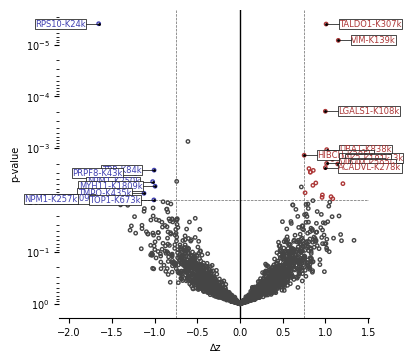

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADVL-K278k""",null,null,0.706336,null,null,null,null,null,null,null,0.356447,0.231033,0.281444,1.448961,-0.10468,-2.003716,-0.938734,-1.104669,0.560048,-1.03115,0.157916,0.459284,0.709505,0.539688,0.307147,0.968981,-0.233349,-0.435023,0.387213,-0.029786,0.073339,-0.75233,0.50013,1.275198,-0.556495,-1.534293,…,-1.583616,0.318768,0.597075,-1.289393,-0.119145,-0.139295,-0.907944,-1.978272,-0.796259,-0.482818,-0.877625,1.648409,0.686585,-0.486404,0.268596,0.318042,-1.056962,-0.980025,-0.114423,1.663548,-2.474029,1.433462,null,null,null,null,null,0.061302,0.903338,0.987125,0.541825,0.697374,0.304609,1.992381,1.576907,0.998925,0.00237
"""ADK-K61k""",null,null,null,null,null,null,null,null,null,null,0.404898,-0.62233,null,null,1.570234,0.834752,null,0.276982,null,0.68384,null,-0.368263,1.354361,-0.281642,-1.290004,null,-0.588885,0.452538,-0.38243,1.439009,null,-0.140659,0.369114,-1.406856,-1.426501,-0.249715,…,3.18097,1.238832,-1.664702,null,-1.109136,-0.352466,-0.359907,0.607467,-1.00747,0.063701,-0.3996,0.854656,-0.713521,-0.92745,0.903049,-0.6688,null,-0.10409,-2.382834,-0.95778,0.642704,-0.744451,null,null,null,null,null,null,1.923102,1.059982,null,0.542555,null,0.696256,0.611635,1.065349,0.008606
"""AFF1-K582k""",null,null,1.880392,null,null,null,null,null,null,null,-1.188505,-0.58148,null,-0.233832,0.616133,-0.172734,-1.136233,0.6331,-0.363954,0.148959,-0.748278,-0.223364,-0.37509,0.711616,-1.585293,-0.844045,0.57938,-0.210909,-0.342535,0.087459,0.449929,-0.068148,0.51621,0.061703,1.355538,-2.061089,…,-0.418899,0.079373,-1.56952,1.02041,0.202848,0.109771,0.263816,0.596876,0.978111,0.891622,0.713351,0.742526,0.812819,0.971778,0.462747,0.348547,-1.348399,0.225483,0.031194,1.111127,-0.826781,-2.967418,null,null,null,null,null,0.563966,0.537919,0.846827,1.01659,-0.204543,0.94709,0.579816,1.76495,0.857454,0.002676
"""AK2-K181k""",null,null,0.579289,null,null,null,null,null,null,null,-0.371754,-0.96374,-3.437052,0.22611,0.120975,-0.15588,-0.381657,-1.116005,0.271344,-0.207039,-0.01754,0.146564,1.177568,1.942495,0.325811,0.964743,-0.138277,-0.366084,0.530926,-0.563868,-0.727688,1.325392,-0.166159,0.14507,-0.255794,-0.271146,…,-0.233188,-0.778759,-0.540166,1.459777,0.920477,0.186411,0.704525,-0.742485,-1.141444,-0.840894,-0.976285,0.741232,0.808039,1.403874,1.407058,1.314934,-1.801975,-0.957065,-1.746325,-0.953613,-1.073253,-1.17207,null,null,null,null,null,0.261045,0.179675,0.972369,1.120853,1.627322,0.275847,1.31711,1.89719,1.081859,0.001634
"""DNAJA1-K37k""",null,null,null,null,null,null,null,null,null,null,-0.843149,null,1.707056,null,null,null,null,-1.008683,-1.384461,null,null,-1.960742,null,-1.665721,-1.085049,null,-1.902426,-1.2967,-0.454156,0.833894,null,-0.296841,null,-0.788847,-2.017092,null,…,1.923127,-0.181345,null,null,-0.52856,-0.34226,null,1.10969,0.354304,1.176087,0.47187,-0.190952,-0.069461,-0.421359,null,-0.561116,null,0.472614,0.083006,null,-0.063513,1.238183,null,null,null,null,null,null,1.169964,0.0541

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MYH11-K1809k""",null,null,1.763019,null,null,null,null,null,null,null,-0.142046,null,null,null,null,null,null,1.345739,null,null,null,1.118184,null,null,null,null,1.572795,1.318176,-0.910099,1.69443,-1.13208,-0.531635,null,-0.304304,1.467088,null,…,-0.319123,null,null,null,-0.431254,-0.694214,-0.609672,-1.020673,0.338169,1.251642,-0.801931,-0.431875,1.663864,-1.064648,null,null,-0.803284,1.379203,-0.845408,-1.004415,0.910035,-0.762616,null,null,null,null,null,-0.04834,-1.365257,null,-1.030956,-1.047444,null,null,-0.922556,-0.993275,0.005409
"""NONO-K109k""",null,null,0.379768,null,null,null,null,null,null,null,-0.630931,null,null,-0.213999,null,null,null,0.483235,null,null,-0.588854,null,null,1.04991,null,0.9822,0.904766,0.827291,1.198217,null,1.282961,null,null,0.227726,0.959218,null,…,0.174482,null,null,-0.257633,0.51699,-1.688885,null,null,1.530612,-0.477939,null,null,1.253865,null,null,null,-1.062153,-0.765395,null,null,null,0.433416,null,null,null,null,null,-0.645338,-2.289622,null,null,null,-2.130361,-0.917935,-0.619371,-1.548202,0.00942
"""NPM1-K250k""",null,null,0.184722,null,null,null,null,null,null,null,null,null,null,0.502052,-0.515231,-1.469609,1.83058,0.24255,null,1.419242,-0.623294,null,0.687479,1.199884,null,1.194092,null,-0.699679,null,-0.015858,1.219453,null,1.224599,1.013776,-0.149179,1.172602,…,null,0.507535,1.25997,0.941243,-0.931363,null,-2.533206,null,-0.215456,null,-0.514664,null,null,-0.78922,-0.107797,null,-1.458713,null,-1.65546,0.799635,null,1.215508,null,null,null,null,null,-1.594012,-1.19966,-0.648711,null,null,-0.935063,-1.024929,0.091457,-1.02133,0.004407
"""NPM1-K257k""",null,null,0.274998,null,null,null,null,null,null,null,-2.390201,-0.276041,null,-0.234842,-1.482852,-0.801523,1.692997,-0.055613,0.165419,0.870535,-0.670903,null,0.781827,0.8043,null,0.841484,-0.098,0.346702,0.20556,-0.750534,1.393854,0.735543,1.01879,1.699763,-0.20996,0.212785,…,0.546123,-0.331368,-0.709278,0.429569,-0.424008,0.262793,-1.173273,null,0.949793,0.33636,1.019843,null,1.565725,0.10689,0.283879,null,-0.550842,0.237699,-0.656722,1.081905,0.941388,0.837765,null,null,null,null,null,-2.909007,-2.840683,-1.255377,null,null,-0.847245,-1.352973,-0.245871,-1.747032,0.009507
"""PRPF8-K43k""",null,null,0.523867,null,null,null,null,null,null,null,0.047821,-0.996099,-1.115191,0.883658,-0.696113,-0.373777,1.822172,0.741739,-1.471105,-0.512486,0.549929,0.037816,1.030677,0.13927,-0.478874,0.80954,0.541379,-0.428024,-0.241027,-1.146302,1.033713,1.373352,0.995385,2.281137,0.968081,0.871134,…,-0.178546,-0.222297,1.027525,1.256233,0.122904,-1.293518,-0.420635,-0.406147,0.398895,0.423289,-0.346543,0.134763,0.053974,-0.2394,0.320975,1.775423,-0.789449,1.416824,1.046592,-0.611836,-2.149687,-1.160277,null,null,null,null,null,-0.659349,-1.322106,-1.924192,0.428223,-0.349339,-1.522743,-1.752922,-1.550521,-1.22347,0.003044
"""RPS10-K24k""",null,null,-1.921688,null,null,null,null,null,null,null,-0.010931,-0.112461,0.322108,-0.726426,0

Lipidomics


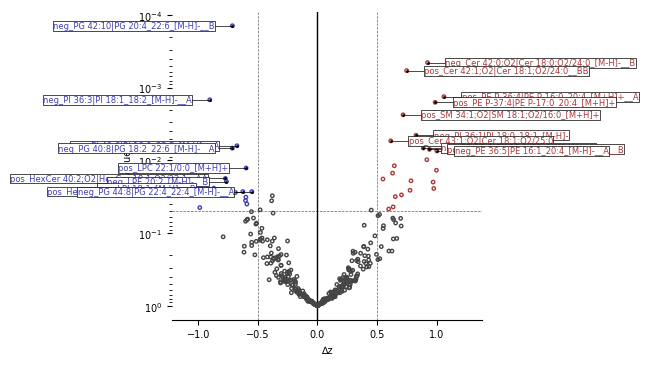

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.18435,null,0.852677,null,-2.468666,-1.980475,-0.90299,-0.459218,-0.874813,0.323036,-0.073667,0.852171,-0.815738,1.202509,-0.364585,-1.142606,-0.890606,-0.799543,-0.46435,-0.265044,-1.114378,-1.288024,0.074244,-0.059613,1.402354,0.446002,-0.516637,-0.956535,-0.839891,-0.528721,0.854735,0.279864,-0.387571,-0.322311,0.04359,0.0595,…,0.014601,1.103042,0.112821,0.596856,-0.612459,-1.389322,-0.278186,1.210277,-1.359954,0.924322,-1.08676,2.478824,0.512053,0.188655,0.302156,0.245364,-1.0144,0.000409,-1.475517,0.481712,0.032386,2.25479,null,null,null,-0.887282,0.798565,1.858192,-0.635687,1.508183,1.271814,0.349975,0.427862,0.784573,1.298375,0.777083,0.025741
"""neg_PG 34:1|PG 16:0_18:1_[M-H]…",-0.187739,null,0.050242,null,-1.819144,-3.05387,-0.912789,0.623155,-0.83366,0.893929,-1.106345,-0.399988,-0.79824,0.060949,0.416028,-0.26987,1.819228,-0.08059,0.648336,0.210139,-0.096195,-0.78182,0.276939,1.131143,-1.318946,0.058516,-0.384283,-0.271766,-0.345697,-0.298216,0.490249,0.811857,0.0232,-0.115382,-0.328059,-2.055953,…,-0.133081,0.721722,-0.698045,1.388893,0.66785,-2.253895,0.130198,-1.575813,0.022791,0.416943,-0.945085,-0.231697,0.63961,0.261862,2.045512,-0.29049,-0.031893,-0.281114,-0.473914,0.59292,-0.817331,1.596201,null,null,null,-0.849663,1.393401,2.009224,0.403648,-0.05107,-0.161836,1.056758,1.453125,2.392807,1.059018,0.998562,0.013647
"""neg_PE 36:5|PE 16:1_20:4_[M-H]…",-1.702495,null,-0.51313,null,1.599926,0.745456,0.63223,1.80622,1.717921,1.583855,-1.436696,0.81537,-0.294098,-0.613113,-0.077921,0.978469,-0.609248,0.500334,0.738179,-0.104674,0.366812,-0.412246,0.179018,0.964931,-0.333065,0.557087,-0.300976,0.672258,1.960123,-0.730473,-0.038119,1.98644,0.825583,0.907777,-0.88732,-1.592258,…,0.449685,0.196595,-0.435159,-1.624861,0.202881,-1.454633,-1.437103,-0.501322,0.254172,-1.956822,-1.040536,-1.300072,0.013157,0.329224,-0.123096,-0.745103,-0.159885,-1.842501,-0.816732,-1.160815,-0.76651,-0.268898,null,null,null,1.569649,0.671835,0.548935,0.127679,1.195339,1.451339,1.403485,-0.45927,2.47954,-0.256666,1.001596,0.007405
"""neg_PI 38:3|PI 18:0_20:3_[M-H]…",-0.042631,null,0.540329,null,-0.939721,-1.505726,0.713462,1.37226,-1.62888,2.187071,-0.848309,0.377104,-0.47445,-0.422751,-1.023594,-0.642314,-0.218642,0.252588,1.834913,-0.295508,-0.721621,-0.427381,0.631919,0.286996,-0.918877,-0.863445,0.93951,0.251182,0.717813,0.061175,-0.025792,1.283179,1.101532,0.714568,0.6409,-0.650697,…,-0.448922,-0.640652,-0.212128,1.428308,-0.535864,-1.341177,-0.197767,1.024189,0.236703,0.170339,-1.072263,2.078754,0.586053,-0.351079,0.599148,0.022823,-1.938687,-1.800841,-1.6168,-0.383615,-1.973951,-0.673483,null,null,null,0.230399,2.46773,2.828171,0.79733,0.314964,1.082635,0.723882,0.054321,0.647602,-0.688208,0.970277,0.019869
"""neg_PI 36:1|PI 18:0_18:1_[M-H]…",-0.092944,null,1.025883,null,-2.758405,-0.531446,-0.26754,0.377088,-1.111072,-0.975627,0.900877,-0.038665,1.069213,-1.093574,-0.125252,0.549391,1.87

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 18:1_[M-H]-__B""",-0.192176,null,-0.679443,null,null,null,-1.9456,-1.096782,null,null,0.856665,-0.808455,-0.707475,-1.430288,-2.889455,1.172899,-1.363523,-0.846031,-0.232566,-1.395245,0.399035,-0.234046,0.042062,0.137127,0.488433,0.467383,-1.364006,1.07489,0.578572,0.17519,-0.665203,0.494587,0.155608,-0.751223,-0.779181,0.832775,…,-0.228339,0.832828,1.959945,1.072255,-0.458636,0.178202,-0.646816,0.289428,1.064493,1.049533,0.364768,0.191905,0.787427,-1.62434,-1.297221,0.309149,1.070416,2.010791,0.351884,1.616026,0.500546,0.469841,null,null,null,null,-2.863016,-0.574443,-0.671826,-0.582348,0.305228,0.102668,-1.16893,-1.085664,-0.328055,-0.870219,0.02412
"""neg_LPE 20:2_[M-H]-__B""",0.149748,null,-0.618175,null,-1.256569,1.70372,-1.01578,0.331478,0.521106,-0.741867,-0.423374,-0.554895,1.653012,-0.074595,-0.666409,0.602429,0.178388,-0.126344,0.552815,-0.328857,-0.265861,-0.358219,-1.371938,-0.209975,-0.773876,0.787041,-0.471227,-0.936926,-0.530202,0.348069,-0.245326,1.598047,0.239504,-0.600951,-1.262712,-0.574292,…,1.196462,-1.245616,0.56514,0.360629,1.131789,1.755441,-0.307985,0.646669,-0.635749,0.222452,1.119198,-0.763462,-1.300445,-0.862817,-1.285094,-0.543449,-0.020171,1.018323,0.709875,3.793831,-0.199767,0.884547,null,null,null,0.878495,-1.930045,-1.054398,-0.387597,-0.04625,-0.666851,-1.686385,-0.16519,-0.491049,-1.108334,-0.763666,0.019509
"""neg_PG 42:10|PG 20:4_22:6_[M-H…",0.347396,null,0.749373,null,0.512516,0.171182,-0.508622,0.030227,0.215251,-0.113265,2.378351,0.584806,null,1.587046,-0.125514,0.127634,-1.517862,1.413877,-1.734428,0.999647,0.891677,2.258667,1.458434,0.329331,2.423573,1.184204,0.197438,1.410817,0.475015,0.437931,1.056838,-0.035828,-1.01379,-1.253043,-0.118926,-0.437401,…,0.498959,-1.598975,-0.435748,-1.159376,-1.196571,0.037028,-0.530015,-0.987321,-0.269791,-0.065467,-1.740659,-0.659661,0.824577,-0.593259,-1.364343,0.975402,-0.12695,0.560102,-1.803746,-0.596681,0.239507,-0.899428,null,null,null,-0.622988,-0.155464,-0.651791,-1.083093,-0.414178,-0.598413,-0.375554,-1.327171,-0.639646,-0.33922,-0.713401,0.00014
"""neg_PG 40:8|PG 18:2_22:6_[M-H]…",0.674639,null,1.485179,null,-0.205839,-1.610096,-2.253761,0.345164,-0.441882,0.357441,1.907526,1.165508,null,1.245419,-0.653333,1.000217,-0.526787,0.496068,-1.547836,0.668242,1.34418,0.769587,0.946994,0.942137,0.418195,1.493066,0.214527,0.844432,0.218116,0.482469,2.113315,0.770184,-1.668108,0.842629,-0.386468,-0.11268,…,0.530548,-1.685259,-1.734981,0.037512,-0.237844,1.178024,0.26557,-1.375861,0.562966,-0.716655,-0.615687,-0.998913,1.526568,-0.129734,-0.621713,0.332903,0.296087,0.793129,-2.245335,0.652585,0.698017,-1.487843,null,null,null,-1.386625,-0.384525,-0.598371,0.408415,-0.317421,-1.709052,-0.943006,-0.040918,-0.767048,-0.474804,-0.714072,0.006786
"""neg_PI 36:4|PI 18:2_18:2_[M-H]…",-1.248855,null,0.362043,null,-1.479671,-0.78242,0.7346,-0.578647,0.315918,-0.840731,1.184269,0.511013,-0.322395,-0.378252,0.424764,0.699567,0.079483,0.125722,

Metabolomics


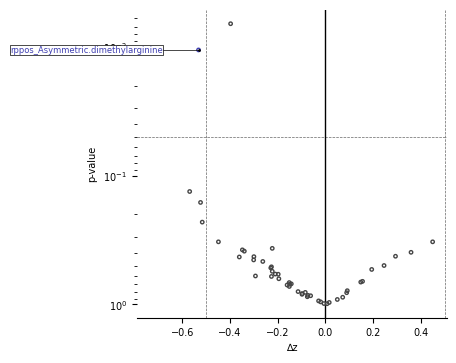

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Asymmetric.dimethylargin…",-0.748212,null,2.329708,null,-1.070975,0.439137,-1.487901,-0.447447,-0.452977,0.566629,0.616603,0.768408,1.336114,-0.458948,-0.580273,0.26682,-0.597199,1.482295,0.493616,0.582129,-0.000548,-1.3204,1.816296,-0.766258,-0.321119,-0.822305,1.701702,-0.084615,-0.052229,0.302268,-0.235249,1.484934,-2.098618,1.931128,0.42029,-1.74585,…,-0.300408,1.179569,1.383112,0.994241,-0.136369,-0.141225,0.54685,-2.180024,0.089168,1.037896,-0.162531,0.721014,-0.367629,-0.188123,-2.198667,-1.645721,-0.253575,-1.098217,-0.225697,1.419581,-1.310104,0.31882,null,null,null,-0.825228,-0.821697,-0.607922,-0.030656,-0.54919,-0.642668,-1.070979,0.382523,-0.563206,0.087988,-0.532354,0.010581


============ W_NPM1-WT ============
Transcriptomics


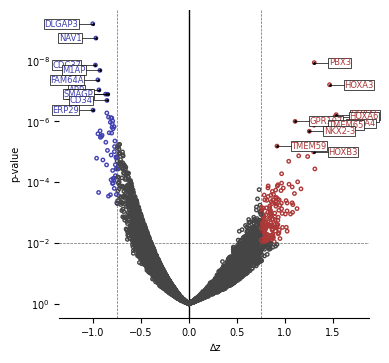

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PRKAR2B""",null,0.503693,null,-0.798638,1.120164,null,-0.887592,-0.504683,0.404151,-0.650455,-0.335296,-0.409874,-0.012468,-0.447729,0.316738,-0.737546,-0.785867,-0.922414,null,-0.201732,-0.153078,null,null,-0.576547,-0.444227,-0.800278,0.581444,null,-0.476573,-0.720642,-0.4572,-0.678204,-0.463402,-0.931819,0.241964,null,…,2.227513,0.898258,1.035403,-0.600108,1.13585,1.431036,-0.41532,-0.299976,0.348396,-0.683751,null,4.536926,null,-0.570646,null,1.213538,null,null,0.241883,0.176646,0.16028,-0.630155,0.246273,null,3.087245,null,-0.543999,0.863931,-0.128535,1.108142,0.142972,2.364677,-0.243661,null,null,0.929274,0.001423
"""GDE1""",null,0.752159,null,0.239327,-1.333929,null,1.271917,-0.308497,-0.010203,0.529415,-1.827138,-1.044539,-0.052167,-0.850695,2.687378,-0.081101,-0.923516,-0.495358,null,-1.995396,-0.875364,null,null,1.158227,-0.845342,-0.558815,-0.750991,null,0.540053,-0.736022,-0.154408,0.555953,-0.096565,-0.573011,-1.110077,null,…,0.332101,-0.290778,0.385797,1.176478,-0.278235,-0.305938,0.375886,-0.748963,0.544902,0.33544,null,1.578229,null,0.346151,null,0.480357,null,null,2.477082,1.155676,0.789723,1.951945,1.635547,null,-0.264095,null,0.979517,0.4482,1.686914,-0.384073,0.15071,-0.029875,0.642958,null,null,0.824345,0.000133
"""RUFY3""",null,0.479429,null,0.044723,-1.190876,null,0.941423,-0.130974,-0.508654,1.030838,-0.176473,1.480891,-1.602008,-0.425567,-0.699068,-0.691423,-1.477564,-0.419389,null,-0.785177,-0.266658,null,null,-0.358593,-1.012537,-1.248999,-0.881283,null,-0.663696,1.00859,-0.315703,-0.130473,-0.864527,-0.022928,0.499204,null,…,1.371306,-0.206187,-0.128729,0.571899,-0.550714,-0.253482,0.629053,0.780822,0.251295,1.093829,null,2.918928,null,0.696187,null,-0.429815,null,null,0.858575,2.799384,1.268379,-0.130027,0.756941,null,-0.082995,null,-0.256705,-0.005453,0.21003,3.181628,-0.557133,0.473179,1.510303,null,null,0.911218,0.000323
"""ABCC2""",null,-0.844409,null,-0.050872,-0.433444,null,-0.527842,-1.054512,-0.47419,-0.342835,-0.819785,0.071244,0.868013,-0.60224,0.173016,-0.889978,-0.291393,-0.925206,null,0.729715,-0.221732,null,null,1.333634,-0.525194,0.289301,0.771175,null,-1.011482,-0.576162,-0.885483,-0.825762,-0.76706,-0.830746,-0.767231,null,…,0.266903,0.246463,0.667399,0.411491,-0.557057,0.092124,2.523568,0.070517,0.724772,1.089046,null,1.208085,null,-0.08667,null,-0.683394,null,null,0.123068,-0.204664,2.639396,-0.187143,0.704888,null,-0.221291,null,-0.671766,-0.534519,-0.310943,4.889652,0.396497,0.38129,3.732314,null,null,0.907932,0.003016
"""CHPF2""",null,0.163,null,0.559633,-0.600811,null,2.012954,0.305875,-0.678446,0.456216,-0.328563,0.248483,-1.54053,0.271408,-0.483496,0.607022,0.570812,-0.290238,null,-0.534031,-0.122512,null,null,1.806907,0.645132,-0.4987,-0.98582,null,-1.231211,-0.192369,-0.88273,-0.888315,-0.080103,-0.117415,0.011223,null,…,0.094462,0.943086,0.374463,2.820981,0.896461,1.030634,1.897672,0.787673,-0.004438,1.468987,null,-0.253759,null,0.628894,null,-0.332365,null,null,2.338366,-0.23514,0.781417,-1.107674,2.035653,nu

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD133""",null,-0.789805,null,1.388163,-0.737406,null,-0.784391,-0.09336,-0.103397,-0.304368,1.461359,1.073347,-0.788044,-0.180067,-0.788551,0.274614,-0.599275,-0.45654,null,-0.408394,-0.741712,null,null,0.784267,2.130976,-0.787187,-0.787976,null,-0.769808,1.072043,1.117609,-0.426047,-0.353273,0.620907,0.625077,null,…,-0.785481,0.11144,-0.450069,0.069111,-0.764901,-0.423899,-0.769658,-0.158715,-0.163652,-0.787751,null,-0.785909,null,-0.785339,null,-0.667123,null,null,-0.74637,-0.785592,-0.782732,-0.088855,-0.731631,null,-0.59008,null,-0.330453,-0.788323,-0.550547,-0.785455,-0.769299,-0.776515,-0.728463,null,null,-0.805035,7.7152e-7
"""ELOVL5""",null,1.020658,null,1.77175,1.12318,null,0.395814,0.657666,1.764338,-0.129578,0.299825,-1.203816,-1.49115,-0.237753,-0.073522,0.837791,2.135597,-0.269048,null,2.174898,0.553883,null,null,2.930477,0.374473,0.801574,0.53041,null,-0.317143,-0.306787,-0.442767,0.240883,1.209595,-0.055096,-0.833745,null,…,0.25394,-0.003432,-1.741928,-2.491942,0.506372,-0.680084,-1.6003,0.12111,-0.368673,-0.827024,null,-1.23791,null,-0.417907,null,1.342858,null,null,-1.418156,0.22509,-0.727073,-1.746342,-0.868946,null,0.04363,null,-0.321611,-0.215182,0.665818,-2.011763,-0.166912,-0.44162,-1.321588,null,null,-0.839446,0.000288
"""CNN2""",null,-1.587074,null,0.089843,1.348678,null,0.717894,2.023579,1.23521,1.964519,1.217009,-1.309884,0.187844,0.220147,-1.351418,0.719436,1.369924,-0.107358,null,1.026545,3.155827,null,null,1.070001,-0.369994,-0.110421,-0.478815,null,-1.188373,-0.164723,-0.237547,0.321765,1.223242,0.559824,-0.577627,null,…,-0.899582,-0.123623,-1.207421,-1.325475,-0.284881,-1.200048,-0.75792,-1.054818,0.042043,-0.52111,null,0.063454,null,-0.978487,null,-0.589035,null,null,-1.8863,1.097544,-1.155023,-1.943366,-0.30179,null,-0.470721,null,-0.454923,-0.632298,0.376973,-0.954279,0.006263,-0.737927,-1.105916,null,null,-0.923615,0.000003
"""ARHGAP10""",null,0.819332,null,-0.131753,-0.311002,null,1.832339,-0.319012,-0.204472,0.687396,3.171402,-1.0651,-1.057095,-0.001433,1.555228,0.213884,-0.788284,0.931412,null,-0.06671,-0.871741,null,null,-0.200705,0.905808,-0.542453,0.215359,null,-0.727501,-0.690557,-0.640603,0.307897,-0.199336,0.869691,-0.4602,null,…,-1.284179,-0.777718,-0.661814,-1.294383,-0.532155,-0.307264,-0.352807,0.44475,-0.474021,-0.694759,null,-1.284831,null,-1.231509,null,-0.086672,null,null,-1.257814,-1.157624,0.167122,-1.250462,-1.023357,null,-0.558068,null,0.97105,-0.356419,-0.706351,0.602165,-0.603507,-0.59941,0.189463,null,null,-0.767235,0.000061
"""ERP29""",null,2.613654,null,0.400529,0.712288,null,-0.589051,1.551646,0.311941,-0.229149,-0.255258,-1.227193,1.462217,0.638809,0.198165,-0.118142,-0.382349,-0.622056,null,0.202686,-0.006847,null,null,-0.860655,-0.216879,0.878856,2.174254,null,0.638599,1.377317,0.532055,3.034639,1.498939,0.264849,1.355581,null,…,-1.440386,-0.440177,0.740355,0.188757,-0.224877,-0.850086,-0.90675,-0.249468,0.032933,-1.322718,null,-1.039679,null,-0.795473,null,0.161898,null,null,-1.559955,0.162295,-1.2951

Proteomics


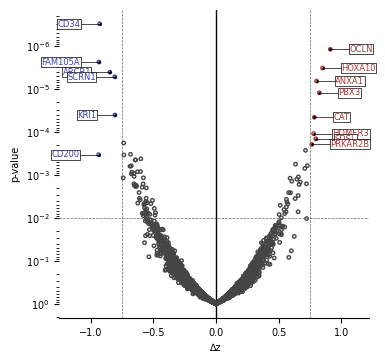

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ANXA1""",-0.06518,-0.344929,0.957281,-2.142164,-0.211283,-0.536254,-2.376397,-0.702281,0.122102,0.954419,-1.233053,0.106148,-0.827532,-0.636065,0.042115,-0.512114,-1.188125,0.399051,0.828426,0.848993,-0.36088,-1.109749,0.343915,-1.112489,-0.025598,-0.298367,-0.575521,1.024904,1.618668,0.839303,-2.293753,1.065981,0.135978,1.193013,0.248645,-0.29844,…,1.281232,1.643098,0.516196,0.731983,1.327557,-0.074011,0.533037,1.056968,0.417164,0.665714,0.378209,0.109387,0.885557,-0.491742,0.787898,-1.279781,-1.122118,-1.033414,1.532681,0.302567,1.813539,0.933288,0.547609,0.579914,1.398247,-0.180167,1.373133,0.654171,0.904882,1.393722,0.426171,0.342455,0.003081,0.160395,0.391571,0.801813,0.000007
"""CAT""",-0.423944,-0.6678,1.072218,-0.244101,-0.234633,-1.178206,-1.680806,-0.91465,0.139921,-0.082387,1.494574,-0.810874,-0.599857,-1.450283,0.835518,-0.335889,-0.945578,-0.881011,0.536864,0.525065,-0.549184,0.013291,-0.7464,-1.178636,-0.189561,-0.700774,0.24812,0.252884,0.321961,1.063116,-2.033087,0.643859,-0.565536,-0.590023,0.958376,-0.799621,…,1.199821,1.64963,0.060477,0.594352,-0.461571,0.172559,1.633248,1.683641,1.347437,0.479075,1.020049,1.087169,1.452558,0.149463,-0.493388,-1.219974,-1.486797,-0.76907,-0.343446,0.403043,1.983556,0.731356,0.294963,1.37092,1.243383,0.035392,-0.134393,-0.116541,0.849301,1.850738,1.15312,0.76802,0.913613,0.500087,-0.657365,0.784401,0.000045
"""HOMER3""",-1.151949,1.978111,-0.070733,-1.709572,-0.694699,-0.801079,-2.160142,-0.729158,-0.610623,1.278934,-0.372291,-0.033749,0.469274,-0.336265,0.320694,-1.082029,-1.224976,-0.437134,1.4832,-0.108509,-0.693026,-1.772191,-0.587109,-0.817725,-0.594935,0.03336,1.367282,1.410358,-0.32078,-0.490546,-1.353027,-0.999273,-0.877155,0.151033,0.372971,-1.665756,…,1.948394,0.963534,1.601085,-1.094083,-0.045858,0.466662,1.082662,0.116593,1.263491,0.734855,0.947072,0.77187,1.531695,-2.212678,1.699505,-2.205491,-0.209436,0.294236,-0.053859,0.619205,1.435415,0.314771,-0.122709,1.43733,0.66691,0.013002,0.560016,0.439269,1.066975,1.653083,0.84714,1.447275,0.169989,0.948837,0.458388,0.778364,0.000109
"""HOXA10""",-0.387213,0.07209,0.659633,-1.314581,-0.988098,-0.801455,-1.586178,-2.425386,-0.829796,0.259314,-0.06804,-0.467303,2.078631,-0.738372,1.149263,-0.040391,-1.001248,-0.580486,1.16485,-0.127275,-0.979191,-0.220558,-1.013267,-1.138292,-0.389954,0.331606,1.327445,-0.373015,0.361471,0.353509,-0.973056,-0.29207,-1.338294,-0.617186,1.001703,-1.160753,…,1.371476,1.76939,0.860429,0.872002,0.498162,0.660118,1.247227,0.966878,1.021805,0.008117,0.975821,0.836928,1.557542,0.30964,1.362033,-1.518035,-1.065922,-1.44863,0.777999,0.628903,1.636694,1.116071,0.685622,0.698803,1.144252,0.171696,0.053809,0.200648,0.500567,1.028154,0.203387,0.951279,0.714608,0.954298,-0.869418,0.849477,0.000003
"""OCLN""",-0.159867,0.962558,0.681898,-0.803189,-0.426296,-1.223587,-1.762581,-1.412321,-0.213394,0.123824,-0.676777,-0.10889,-0.420718,-0.943573,-0.191674,0.372629,-0.692399,-0.886609,0.330778,1.133348,-0.604541,0.681282,-0.813573,-0.675522,-0.41

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",1.242199,-0.276604,0.014818,0.496685,-0.197465,1.229728,-1.661001,-1.696032,-0.458131,0.990262,1.8688,0.032781,-0.069056,-0.205078,-0.871001,1.724275,null,-0.186125,0.054304,-0.090675,0.05239,-0.15966,1.065066,0.561542,1.9261,-0.607947,0.890605,-0.532857,0.112266,0.578762,-1.51821,0.709689,-0.413098,1.391581,-0.226516,1.103121,…,0.517183,0.026922,-0.210375,-0.710001,-1.000752,-0.71029,-0.745064,-0.313236,-0.435649,-1.403031,-1.365115,-0.845604,-1.32168,-1.806276,0.404541,-2.332196,-1.310893,-1.784774,null,null,-0.365148,null,0.285544,null,-0.301275,-0.78542,0.384381,0.330848,0.44957,-0.79798,-0.555623,-0.93005,-0.433353,0.064151,-0.145416,-0.847563,0.000004
"""CD200""",-0.79561,0.04359,null,0.829481,0.01675,0.76622,null,null,-0.194275,1.094623,1.629223,0.871097,null,null,-0.252244,null,null,null,0.126754,0.326822,null,null,null,null,1.795832,-0.155065,0.054656,1.16183,-0.224221,null,-0.200944,null,null,1.422315,null,-0.213226,…,0.261388,-0.062487,null,-1.128115,-0.530412,-1.521005,-0.537042,-0.530905,-0.272214,null,-0.921997,null,null,-1.365337,-0.130859,-2.112723,null,-1.641437,null,null,null,null,null,null,-0.464431,null,1.336829,0.451497,null,-2.492241,0.100377,null,-0.890621,-0.713938,0.655765,-0.93661,0.000338
"""CD34""",0.591847,-0.62821,0.498394,-0.372036,-0.527873,-0.532693,-0.716059,-0.923339,-0.289619,1.100623,2.327547,0.4434,-0.375518,0.63433,1.116936,0.557454,-1.155203,1.00783,-0.308689,0.122163,-0.762518,1.046084,1.926133,-0.410361,1.715835,-0.759709,-0.508517,1.302208,-0.492482,0.21516,1.002483,0.810046,-1.191224,1.397996,0.806277,0.60573,…,-0.434154,-0.535005,-0.202552,-1.18699,-1.124834,-0.109731,-1.622633,-0.432134,0.129017,-1.261608,-0.405657,-0.989683,-1.265107,-1.221464,-0.423185,-1.346289,-1.423904,-1.528572,1.081948,-0.504116,-0.531606,0.680005,-0.507793,-0.887468,-0.730903,-1.198144,1.609713,-0.067172,-0.38933,-1.190245,-0.846669,-1.131343,-1.191895,-1.154243,0.756959,-0.928947,3.0010e-7
"""FAM105A""",-0.494798,2.057282,1.247373,-0.660878,1.533807,0.502911,-1.811543,0.175023,-0.248358,2.054403,0.57404,1.123748,1.457044,0.862467,-1.103679,0.684849,0.134016,0.403373,0.818469,1.264498,0.670469,-0.748925,0.193901,-0.678864,0.084069,-0.704656,-0.439178,2.162671,1.031272,-0.638331,-1.011662,0.898104,-0.340339,1.185345,-0.041527,-0.454928,…,0.530042,-0.334278,0.388975,-1.366694,-0.58156,-1.202266,-1.737808,-0.440769,0.210238,-1.851119,-0.593959,-1.307941,-2.114364,-1.731917,0.941485,-0.701082,-1.592332,-0.931266,-0.622159,-0.38216,-0.973176,-1.195901,0.276196,-0.554686,-0.08086,-1.513751,1.192728,0.860024,0.662315,-1.336824,-0.880634,-1.080361,-1.366177,-1.655343,0.81784,-0.934279,0.000002
"""KRI1""",0.0865,1.077239,0.727734,0.449319,0.180147,-0.54593,-1.774595,-1.974748,-0.679144,1.612024,1.586768,-0.008316,1.101295,0.083973,1.464851,0.001724,-2.022985,0.250627,0.775015,0.353238,-0.786512,0.194041,1.759359,1.47583,1.149989,0.505993,1.229764,-0.094902,1.381146,0.342975,-1.068983,0.705872,-2.108692,0.328278,0.576776,-0.850432,…,0.287084,0.489

Phosphoproteomics


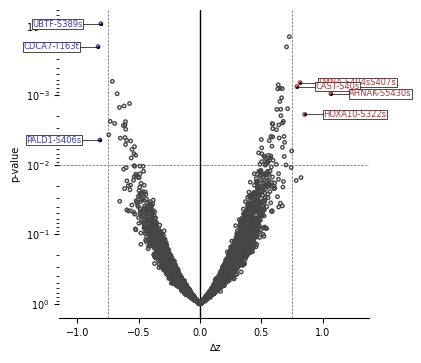

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AHNAK-S5430s""",-0.654094,-0.175374,-0.387775,-1.306584,null,null,-2.114429,0.226238,-0.703024,-2.35686,null,-0.178938,-0.590462,0.081118,null,null,-1.21598,1.532687,1.789352,null,-1.182857,-0.673757,null,1.018225,0.321382,-0.395579,0.740544,null,null,null,null,null,-1.456155,-0.869396,0.037334,-0.436484,…,null,2.497645,0.650959,null,null,1.258218,null,-0.586298,null,null,null,null,2.032778,null,null,null,0.022391,0.153648,0.426395,1.704153,null,0.192374,-0.333413,0.997509,null,null,null,null,1.007097,null,null,null,null,1.660192,null,1.068219,0.000948
"""CAST-S40s""",-1.068654,0.05141,-0.023546,0.204235,null,0.967867,null,-0.525738,-1.50702,0.493928,null,1.318727,null,null,1.18815,-1.476056,-1.153396,0.123453,1.863212,0.18958,0.235172,-1.132505,-1.037519,-0.067543,-0.988337,1.077679,0.416889,-1.332198,1.514514,1.266398,-1.515043,0.33189,-0.43043,-1.42248,-0.627829,-1.099785,…,2.636651,0.828274,null,-0.441567,null,0.870297,null,0.969917,1.643647,null,-0.376623,0.754985,0.092057,null,null,null,0.917246,1.205484,-0.359952,0.486195,1.221649,0.235774,0.269424,1.93051,0.626469,-1.477937,null,0.059867,1.105405,-0.407007,null,0.763927,null,2.058909,-0.206371,0.791093,0.000751
"""HOXA10-S322s""",null,-0.387888,0.270748,-1.254828,null,0.022738,-1.226645,null,-0.954612,null,-0.559219,-0.843613,0.405952,-1.228159,1.24792,-0.062194,null,-0.058565,0.391794,null,-0.141311,0.320062,0.049466,-1.110233,null,-0.467645,null,-0.133668,null,-0.955467,null,-0.857374,null,-0.494453,1.346867,null,…,0.470069,null,0.029403,null,null,1.211938,null,0.795372,null,-0.792431,-0.493402,-0.502262,1.657675,0.06306,null,null,null,null,1.871402,-0.194664,0.338466,0.921169,-0.129431,0.70067,null,null,null,null,0.141196,2.509597,null,2.468081,null,1.026199,-0.873059,0.854787,0.001889
"""LMNA-S404sS407s""",-0.862782,1.808339,null,-1.552818,null,null,-1.466282,-1.23188,-1.435089,-1.239745,null,-0.301074,1.488217,-0.72554,null,-0.933484,null,null,0.753027,-0.425254,null,null,-0.003817,-0.369866,-0.928137,0.60597,1.662124,null,1.576875,-0.18535,-1.688136,null,null,0.202626,null,-1.056845,…,1.512754,1.503759,0.816211,null,null,0.363537,null,0.05245,null,null,null,0.182116,0.708204,null,null,null,null,1.009251,0.257775,0.41367,0.826831,-0.04432,-0.288214,null,null,null,null,1.786328,null,null,null,null,null,1.769054,-0.126006,0.816955,0.000658


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CDCA7-T163t""",null,null,1.319032,-0.047716,0.443483,-0.114343,-2.200405,null,0.516022,null,1.490056,0.486536,-0.672991,null,0.606058,-0.84669,null,-0.258802,-0.480725,null,-0.085493,-0.988145,1.892393,0.337393,null,1.699895,null,1.351911,null,0.230345,null,null,-0.480258,1.498146,0.986856,null,…,-0.994026,null,null,-0.615854,0.995368,-0.382911,-0.489705,1.474045,-0.177548,-1.098109,-1.884914,-1.692086,-1.355458,0.311833,-0.475731,-1.8514,-1.233666,null,null,null,-0.246459,null,-0.290682,null,-0.626922,-1.246749,0.149446,null,-1.190339,-0.80044,-0.276755,null,-0.848094,0.493187,0.371034,-0.831943,0.0002
"""PALD1-S406s""",0.139108,null,null,-0.451794,null,0.33156,-2.101453,null,-0.42801,1.979194,1.847532,1.208344,-0.027988,null,-0.229749,0.093631,null,null,-0.067205,0.862185,null,null,2.045399,null,1.786277,-0.267424,0.103788,1.086497,-0.148626,0.429283,-0.09642,1.210305,null,0.27302,null,-1.346692,…,-0.570221,0.57013,null,null,null,-1.020201,null,0.373019,null,-1.297927,-2.797235,-1.094261,-1.00378,-0.710479,null,-1.565292,null,-1.369842,null,null,-0.455001,null,null,null,null,null,null,-0.066717,null,0.320376,null,-1.034115,null,null,0.488737,-0.817113,0.004414
"""UBTF-S389s""",0.291134,1.038481,1.026635,1.306942,1.503624,0.628325,-2.568215,-0.946048,null,null,null,-0.317814,-0.110573,-0.88103,-0.162581,-0.082993,-0.823492,0.472068,0.687891,1.395626,-1.210093,-0.110901,1.809396,1.935711,null,-0.628354,1.490742,1.113326,-0.009223,-0.475247,-0.959302,0.790109,-0.336219,null,0.820714,null,…,-0.358925,null,0.054103,-0.366887,-0.483127,-1.152934,-0.077076,0.596556,-0.071253,null,-2.296064,-0.817301,null,null,null,-1.908065,-2.644439,null,0.111089,-0.240616,1.085595,-1.384241,-0.991915,-0.497978,-0.320533,-1.252779,null,0.256799,-0.634934,-0.540385,-0.774775,-0.99553,null,-0.155483,-0.187605,-0.809269,0.000094


Lipidomics


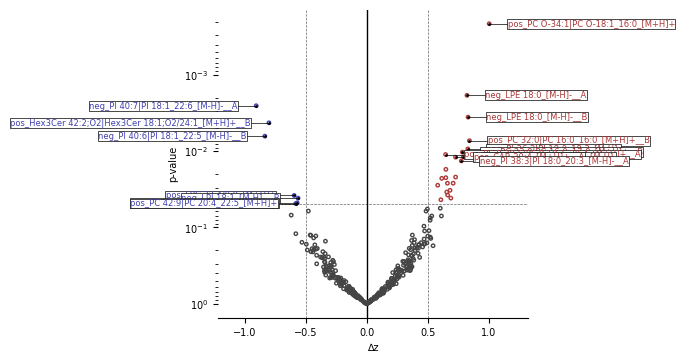

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 20:4_[M-H]-__B""",-1.217959,-1.344691,-0.816427,-1.050415,-0.352358,-0.520437,0.712664,0.246723,0.536047,-0.389379,2.546673,-0.137403,0.437424,0.480711,0.141586,0.840241,0.4177,0.454067,-0.542248,0.546063,1.12477,null,0.313037,1.460932,0.143107,-1.357808,0.787002,null,null,null,-0.258605,null,null,null,null,null,…,0.536386,-0.388609,2.05989,-0.11287,1.338484,0.843701,1.111489,1.561326,1.174794,0.215781,null,null,null,null,null,null,null,null,null,-1.451736,null,null,null,null,null,null,0.390458,null,null,null,-0.61545,null,null,null,null,0.661704,0.037613
"""neg_LPE O-18:1_[M-H]-__A""",1.632621,1.258694,-0.486388,-0.511211,1.454056,2.083311,-0.524331,-0.401939,0.3582,-0.759088,-0.944119,-0.230129,-1.295218,-1.900526,-0.343832,-3.162377,-1.335424,-0.268487,0.894856,-0.5249,-0.688233,null,-0.546708,0.107479,-0.402103,-1.504672,-0.779061,null,null,null,-0.840355,null,null,null,null,null,…,0.278769,1.637975,1.499812,1.124422,0.22291,-0.866065,-0.39854,-0.660148,0.998526,0.915514,null,null,null,null,null,null,null,null,null,0.194875,null,null,null,null,null,null,0.980856,null,null,null,-0.015226,null,null,null,null,0.646856,0.02226
"""neg_LPE 18:0_[M-H]-__A""",-0.489491,1.490462,-0.608143,-0.188888,-0.10952,0.094944,1.083852,-0.627959,0.238045,-1.661388,0.730095,0.530309,-0.60934,0.823348,-0.565284,1.547882,-1.409107,0.247454,0.476169,-0.521882,0.884824,null,-0.885062,-0.230812,0.212418,-2.875961,-0.695956,null,null,null,-0.554893,null,null,null,null,null,…,1.559746,0.113014,0.709191,0.416003,0.871913,0.514576,0.212633,1.512474,0.486398,0.729633,null,null,null,null,null,null,null,null,null,-0.889397,null,null,null,null,null,null,-0.121937,null,null,null,1.285767,null,null,null,null,0.819776,0.001855
"""neg_LPE 18:0_[M-H]-__B""",-0.474377,1.20688,-0.158231,-0.124113,0.29288,-1.070393,0.768266,-0.883941,-0.034019,-1.233477,0.021965,0.215701,-0.240262,1.14609,-1.031632,2.521988,-1.216066,0.581769,0.237599,-0.25021,0.728725,null,-0.30664,-1.83111,-0.156932,-2.261828,-1.453368,null,null,null,-0.239855,null,null,null,null,null,…,2.696234,0.317452,0.224568,0.182606,0.27757,0.356834,-0.285336,1.256789,0.426274,0.682558,null,null,null,null,null,null,null,null,null,-0.420949,null,null,null,null,null,null,0.692193,null,null,null,1.072286,null,null,null,null,0.828833,0.003581
"""neg_DLCL 36:4|DLCL 18:2_18:2_[…",-2.388132,1.333126,0.496352,0.973968,-0.115842,-0.689084,0.215902,0.504294,-0.429449,0.332747,-0.906969,0.888604,-1.191826,-0.924317,-1.981771,-0.603327,-0.886547,0.823236,0.328878,0.076357,0.487059,null,-0.500284,-1.020932,1.57289,-0.831931,-0.517406,null,null,null,0.238886,null,null,null,null,null,…,0.255743,-0.512155,0.155116,-0.393128,0.3999,-0.307691,0.672087,-0.460674,1.542224,0.629895,null,null,null,null,null,null,null,null,null,1.66248,null,null,null,null,null,null,2.315675,null,null,null,-0.166324,null,null,null,null,0.606165,0.043322
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 18:1_[M-H]-__B""",-0.393842,0.3938,1.49045,0.839188,0.972564,1.124702,-1.671654,1.22358,-0.65664,0.353674,-0.51893,2.068347,-1.824304,-1.373011,0.20396,-1.517621,0.814385,0.071714,0.148203,-0.246863,-0.079879,null,1.334034,-1.62916,-0.876037,0.92531,0.511364,null,null,null,0.349734,null,null,null,null,null,…,-1.740203,-0.885814,-1.019836,-0.436342,-0.644141,-0.344354,-0.128812,-1.274412,0.368159,-0.059848,null,null,null,null,null,null,null,null,null,-0.954402,null,null,null,null,null,null,0.073128,null,null,null,0.185636,null,null,null,null,-0.563159,0.041271
"""neg_PI 38:6|PI 18:2_20:4_[M-H]…",0.285493,0.21158,1.452834,-1.121151,0.562,0.007752,-0.926653,-0.977922,-1.017719,2.080943,-0.659235,0.981251,-0.692898,0.733934,0.229025,0.139942,0.017284,-0.186663,0.776121,1.19088,-0.561434,null,2.745807,-1.602519,0.800762,1.097542,-0.341446,null,null,null,1.403161,null,null,null,null,null,…,-0.413821,0.350669,-1.799146,-0.76257,0.257954,-0.776627,0.039394,0.504919,-1.104408,-1.83293,null,null,null,null,null,null,null,null,null,-0.160102,null,null,null,null,null,null,-0.639547,null,null,null,0.873603,null,null,null,null,-0.570293,0.047607
"""neg_PI 40:7|PI 18:1_22:6_[M-H]…",0.813278,0.596004,1.298655,0.738478,0.610638,1.416631,-1.353992,-0.388869,-0.206605,-0.427168,-0.049728,1.045813,-0.685876,-0.760736,-0.424438,-0.620316,-0.541353,-0.07748,0.200148,0.173423,-1.703934,null,2.648843,-1.939105,0.860748,1.199807,0.740875,null,null,null,1.184589,null,null,null,null,null,…,-1.495717,-1.245481,-2.207201,1.305096,0.37247,-0.275381,-0.733292,-0.750555,-0.559939,-0.49229,null,null,null,null,null,null,null,null,null,-0.631256,null,null,null,null,null,null,-1.162155,null,null,null,-0.870478,null,null,null,null,-0.905704,0.002538
"""neg_PI 40:6|PI 18:1_22:5_[M-H]…",0.418447,0.179615,1.225305,0.25206,-0.623791,0.001972,-0.070895,-0.406703,-0.952717,0.429583,-0.131546,0.656083,-1.371677,0.917328,-0.444487,1.052729,0.531485,-0.636603,0.336365,0.370596,0.6931,null,2.45676,-0.529379,-1.007443,2.994121,0.498273,null,null,null,1.065194,null,null,null,null,null,…,-0.942742,0.229484,-1.508664,-0.104943,-0.920156,-1.3941,-0.500445,-0.391193,-1.955459,-1.747753,null,null,null,null,null,null,null,null,null,-0.425885,null,null,null,null,null,null,1.101289,null,null,null,0.36182,null,null,null,null,-0.835195,0.006358
"""pos_LPC 22:4/0:0_[M+H]+""",-0.975635,1.281352,-0.099293,1.94993,0.219884,-0.544682,0.686046,2.247038,-1.031678,-1.131059,-0.179121,0.503219,1.358889,1.378509,0.342193,-1.124507,1.123311,0.106399,-0.187811,-0.673292,-0.310281,null,-0.505922,1.052529,-1.917519,0.878376,1.22323,null,null,null,0.351124,null,null,null,null,null,…,-1.325788,-0.058911,-1.616126,-0.191519,-2.045376,-0.569489,0.341499,-0.447447,0.29545,0.277965,null,null,null,null,null,null,null,null,null,-0.958164,null,null,null,null,null,null,-0.182573,null,null,null,-0.313232,null,null,null,null,-0.595412,0.038098
"""pos_PC 42:9|PC 20:4_22:5_[M+H]…",-0.92411,1.065385,0.625814,0.482761,-0.822067,-1.519629,0.795775

Metabolomics


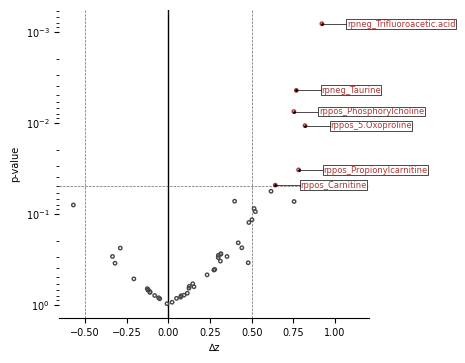

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_5.Oxoproline""",-0.492748,-0.723267,-0.081522,-1.8736,-1.134742,-2.413734,1.384347,-1.179767,-0.902655,-0.678288,0.546799,-0.573132,-0.31162,-0.403388,-0.321094,0.55601,0.144056,0.334543,-1.557922,0.890331,-0.954608,null,0.069897,0.362168,-0.817918,0.727401,0.846298,null,null,null,0.390753,null,null,null,null,null,…,0.209547,-0.492643,0.764594,-0.181671,-1.379601,1.633678,-0.265999,0.821763,1.840524,0.326025,null,null,null,null,null,null,null,null,null,1.512452,null,null,null,null,null,null,1.45155,null,null,null,0.718289,null,null,null,null,0.820685,0.010805
"""rppos_Carnitine""",-1.662275,-0.631292,-1.867461,0.954025,-0.729467,-1.725787,0.593478,1.46729,0.388906,-1.491298,1.049518,0.697744,-0.81938,0.31617,-1.014636,1.205526,-0.325944,0.415247,-2.239709,-0.366462,-0.915001,null,1.167296,-0.081893,-0.16612,0.630193,-0.549203,null,null,null,0.179366,null,null,null,null,null,…,-0.959973,-0.711198,1.045787,0.388624,-1.115609,1.695579,0.074893,1.51829,1.135286,0.874396,null,null,null,null,null,null,null,null,null,1.420136,null,null,null,null,null,null,0.681642,null,null,null,1.229353,null,null,null,null,0.642184,0.048728
"""rppos_Phosphorylcholine""",0.072128,-3.055312,-0.72547,-1.094427,-0.026359,-1.240776,0.430148,0.261736,-0.842994,-1.148287,1.429513,-1.874284,-0.029841,1.297002,0.229325,1.52232,0.264086,-0.298835,-0.404654,-0.172687,-0.467747,null,0.75994,0.176643,-0.155624,-0.458423,0.128544,null,null,null,0.045892,null,null,null,null,null,…,1.269444,0.049673,0.086431,0.403452,0.159466,0.460879,-0.623836,1.248747,0.579182,-0.774641,null,null,null,null,null,null,null,null,null,1.84579,null,null,null,null,null,null,1.486888,null,null,null,0.474222,null,null,null,null,0.753779,0.007561
"""rppos_Propionylcarnitine""",-0.118644,-1.117659,-0.49587,-0.040633,0.287524,-1.006914,-0.30785,0.015619,-0.022819,-1.203781,0.292462,-0.298783,0.580654,-0.480048,-0.831205,2.461562,-0.79951,-0.154721,-0.996889,-1.214251,-1.416112,null,-0.378772,1.132675,-0.219235,0.10991,-1.776773,null,null,null,-1.226964,null,null,null,null,null,…,0.174711,-0.773834,-0.252729,0.141137,1.046691,0.722536,-0.799272,3.411126,-0.949839,1.655825,null,null,null,null,null,null,null,null,null,1.381458,null,null,null,null,null,null,0.956101,null,null,null,0.661802,null,null,null,null,0.782153,0.033114
"""rpneg_Taurine""",0.372545,-2.167218,-2.474764,-2.118869,0.174327,-0.37079,0.490148,-0.059632,-0.443102,-0.203944,1.392271,-0.810215,1.04963,-1.016466,0.136776,-0.136695,-0.326937,0.356675,0.195663,-1.828614,-0.688298,null,0.488293,0.424645,0.703955,-0.533014,0.694111,null,null,null,-0.244553,null,null,null,null,null,…,0.532206,-1.017419,0.736136,1.212417,0.417195,0.866825,-0.255813,1.215724,-0.089957,0.428307,null,null,null,null,null,null,null,null,null,1.644523,null,null,null,null,null,null,1.208874,null,null,null,0.222924,null,null,null,null,0.768327,0.00443
"""rpneg_Trifluoroacetic.acid""",-0.645465,-1.850586,-0.508841,-1.646591,-0.534271,-0.378969,0.497714,1.494652,-0.403837,-0.598273,1.798179,0.09

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITD-WT ============
Transcriptomics


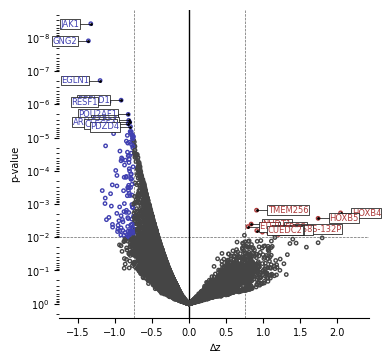

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HEL-S-132P""",null,-0.754743,-1.406562,0.049029,1.964372,null,0.04684,0.720504,null,0.83778,null,-0.243526,-0.307639,-1.416186,-1.6094,1.061962,0.087958,-0.078334,0.262721,1.488074,-0.133416,-1.509912,-1.191605,0.627044,null,-0.42315,null,null,null,null,0.158579,-0.480482,-0.79363,1.469512,-0.37455,null,…,-0.695062,0.524193,null,1.073149,0.021014,null,null,null,-0.57602,0.010809,-1.051954,-1.420102,-0.314586,-0.135454,-1.300136,null,-0.704943,-0.170347,0.725793,-1.630831,null,null,1.635977,0.97324,null,null,1.55108,null,-0.007731,0.623363,-0.458808,3.061628,null,1.25936,0.921507,1.257274,0.005697
"""ETFB""",null,-0.277714,-1.852763,-0.445415,-0.396359,null,-0.536659,0.088573,null,0.772728,null,-1.160726,-0.432355,-0.768786,-0.454703,0.102342,0.076785,-1.379894,-0.674153,1.037694,-0.387325,-1.203228,-1.420912,0.653058,null,2.821073,null,null,null,null,-0.034877,-0.543379,-0.526404,1.086019,-0.719753,null,…,-0.762167,-0.933898,null,0.215229,-0.210926,null,null,null,-0.071437,0.666083,-1.018168,-1.267385,1.360079,1.431167,1.301051,null,-0.746926,0.878656,0.552845,-0.535491,null,null,1.711994,1.067435,null,null,0.578562,null,0.684577,0.277777,1.148777,-0.388671,null,0.373196,0.58175,0.793771,0.004792
"""NUDT1""",null,-1.216912,-0.924802,1.407803,-0.173106,null,0.345451,-0.405347,null,2.627792,null,-0.229259,-0.679819,0.48291,-0.291851,-0.344857,0.946426,-0.485251,-0.111595,-0.165039,-0.411171,-0.579002,-1.689544,-1.161008,null,2.790526,null,null,null,null,0.27851,-0.419905,0.439012,0.607261,-0.331545,null,…,-1.121312,-1.533186,null,0.387213,0.407526,null,null,null,0.163615,-1.102677,-0.254478,-1.008344,0.093196,-0.467454,-0.550915,null,-0.655306,-0.490893,0.92977,-1.650982,null,null,1.585182,0.956182,null,null,1.120343,null,0.755742,-0.404014,0.665972,0.328553,null,1.268931,0.096904,0.838277,0.004016
"""CUEDC2""",null,-1.057542,0.779076,0.067488,-2.878676,null,-0.608711,0.710529,null,-0.408921,null,-1.065047,-0.623293,0.065594,-1.204934,-0.278739,0.897551,-0.412408,-0.038232,1.458592,-0.336414,-0.33886,-1.463673,0.902361,null,1.838404,null,null,null,null,0.998822,-0.164584,0.227,0.905326,0.340705,null,…,-0.975663,-0.056908,null,0.404527,-1.329083,null,null,null,2.419936,-0.535225,-1.239684,-1.204073,-0.143427,-0.837326,0.306226,null,-0.5989,0.107042,0.766366,-1.401788,null,null,1.872442,1.640684,null,null,0.420504,null,0.296676,0.785796,0.236749,0.20926,null,1.598137,-0.109708,0.91413,0.006292
"""NDUFS8""",null,0.768401,-0.571898,-0.564308,-3.048072,null,0.239885,0.268309,null,-0.034739,null,-0.896563,0.875072,1.29825,-0.935362,-0.661525,0.793975,-0.585886,-0.511885,1.403782,-0.649264,0.742588,0.658149,1.806341,null,-1.5666,null,null,null,null,0.308118,-0.959346,-1.155181,1.667424,-0.927568,null,…,0.040115,0.047122,null,-0.355147,-0.727013,null,null,null,0.561267,1.138796,1.111139,-0.48236,-0.848313,-0.147426,-0.906155,null,-0.599293,-0.174508,0.928095,-1.933925,null,null,2.435005,-0.171539,null,null,1.668555,null,1.005

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""KDM7A""",null,2.087755,0.27896,0.998083,0.233961,null,-0.495845,-0.699037,null,-0.510151,null,-0.338697,-0.715087,0.531623,2.21016,-0.783876,0.090395,0.045663,-0.842628,-0.681191,-0.450434,1.531962,0.133476,-0.073192,null,-0.89537,null,null,null,null,-0.974131,-0.100224,-0.525735,-1.015558,0.176282,null,…,1.612133,-0.909137,null,-0.290785,-0.190778,null,null,null,-0.338189,-0.221021,-0.090086,0.849299,1.859161,1.781733,0.262261,null,0.382626,1.931838,-0.884124,3.228693,null,null,-1.394194,-1.056265,null,null,-0.662098,null,-0.872906,-1.173879,-0.58059,0.991358,null,-1.354915,-0.879957,-0.918458,0.005212
"""FYN""",null,0.278498,-0.72437,-0.129364,3.53074,null,-0.936397,-1.151613,null,-0.604853,null,0.620101,0.311464,2.058116,1.115029,-0.141926,1.039696,-1.004165,-0.765355,-0.598767,-0.386992,2.522597,0.641346,0.006759,null,0.009028,null,null,null,null,-0.309465,-0.879477,0.135152,-0.736588,-0.001998,null,…,1.230898,0.008975,null,0.430121,0.96965,null,null,null,0.583247,0.251692,0.414688,-0.609784,0.376801,0.121353,-0.964941,null,-1.107367,1.288023,1.304929,-0.875304,null,null,-1.049085,-1.337171,null,null,-0.780936,null,-0.558007,-1.31748,-0.228705,-0.857929,null,-1.116262,-0.504117,-1.019234,0.000008
"""ARHGAP31""",null,0.37629,-0.35515,1.034283,-0.788517,null,-0.247754,-0.669469,null,-0.515415,null,-0.658797,-0.520082,-0.481398,1.828988,-0.677783,2.333807,0.230601,-0.730649,-0.36715,-0.814918,-0.095669,-0.7405,-0.660397,null,-0.47699,null,null,null,null,-0.602545,-0.700013,1.367895,-0.527579,0.344176,null,…,-0.340088,3.131174,null,0.320235,0.04187,null,null,null,1.336491,0.556435,-0.63991,-0.612344,1.947106,-0.744584,3.194299,null,-0.179484,1.99577,0.778291,0.015875,null,null,-0.614344,-0.702434,null,null,-0.591408,null,-0.845264,-0.747255,-0.661321,-0.583395,null,-0.81351,-0.533704,-0.801299,0.000003
"""ATG5""",null,-0.554348,-1.159396,0.805035,-0.937544,null,-0.084807,-0.336967,null,0.964336,null,1.652229,1.027557,0.041751,2.797291,0.528691,1.548812,-0.648289,-0.056679,0.877473,1.919392,0.190969,0.388351,0.550855,null,0.792423,null,null,null,null,-0.474144,1.713011,1.069786,0.474805,-0.498682,null,…,1.519405,-1.339462,null,-1.17294,-0.839722,null,null,null,-1.00298,-0.855342,0.601664,0.510639,-0.149982,-0.632087,-0.688958,null,0.846934,-1.292679,1.832118,-1.517281,null,null,-1.208025,0.003166,null,null,-0.099927,null,-0.307414,-0.649063,-1.023281,-0.508721,null,-0.30493,-2.256866,-0.835813,0.008582
"""GNAI3""",null,-0.249496,-1.299318,1.188154,2.088176,null,-0.251771,2.174619,null,0.467725,null,1.384077,-0.933331,-0.186111,1.250642,0.125327,0.530494,2.429799,0.657666,1.161541,1.509847,-0.352866,-0.704561,-0.55028,null,0.267828,null,null,null,null,-1.150496,-0.2072,1.346206,2.043998,0.515606,null,…,0.358523,-1.476441,null,-1.023283,-0.524106,null,null,null,-0.798263,0.079157,0.10589,-0.218844,-0.033024,-0.68855,-0.239715,null,1.25951,-1.500752,-0.748835,0.811485,null,null,-0.622265,-0.325675,null,null,-1.191104,nu

Proteomics


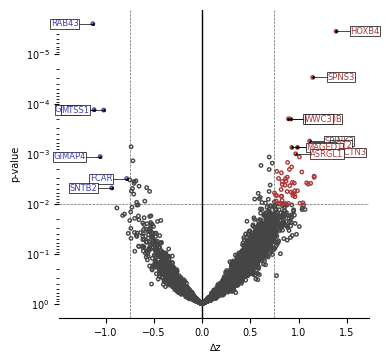

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADARB1""",-0.608695,-0.793523,-0.182165,-0.16652,null,null,null,null,null,null,-2.895838,-1.185995,-1.685241,-0.249028,-0.608739,-2.307337,1.605549,-2.042586,0.508154,-0.14692,-1.494039,-0.725938,-0.61021,0.760295,-0.095522,-0.813284,-0.915047,-0.593849,-0.061327,-0.486523,-0.032999,-0.282648,-0.284052,-0.627755,-0.06244,-0.71107,…,-0.916114,0.700038,1.454358,-0.18244,-0.325926,-0.321422,-1.256741,0.445412,0.370769,1.087319,0.616392,0.472459,0.79075,-0.296102,0.16588,0.487121,-0.301235,-0.076709,0.321551,-0.745133,1.213276,-1.160134,0.885725,null,0.908253,-0.032,0.873707,1.798249,0.102653,0.761354,0.279243,-0.843845,2.11905,1.939213,0.683512,0.935364,0.003699
"""ASRGL1""",0.515068,0.562151,-1.175554,1.037962,null,null,null,null,null,null,-1.080731,-0.731784,-1.73075,0.145211,0.137421,null,-1.63198,-1.941837,0.650352,-0.155582,-0.716337,0.764253,null,-0.091508,-0.274734,-0.696533,-0.179115,-1.177276,0.115506,-0.450308,-0.770202,0.170171,0.023189,-0.682867,-0.745252,1.830581,…,-2.639163,-1.535924,-0.261851,0.213702,-0.85268,0.673695,-0.192603,0.483726,0.280382,-0.302145,0.548324,-0.804662,1.849498,0.344461,0.881367,0.779889,-0.693746,0.714408,-1.419792,-1.121287,-1.115456,-0.410667,0.599746,null,-0.53908,1.153543,0.787307,1.736895,1.066462,1.211581,-0.169289,0.334713,2.10249,0.383086,1.080477,0.969552,0.000988
"""CDK11A""",-1.144132,-1.388036,0.944948,-0.530988,null,null,null,null,null,null,-2.441823,-1.526763,-0.930394,-0.767527,-0.817383,-1.970502,-0.333204,-2.278266,-1.199374,-0.952197,-0.989041,0.123968,0.425283,0.82102,-0.201534,-0.637079,-1.932794,-0.054378,-0.04524,-0.007304,-0.734955,0.744445,-0.845074,1.093017,1.468288,-0.380417,…,0.552478,-0.808001,0.526126,-0.072545,-1.207934,0.76681,-1.29059,1.583297,0.324349,1.287545,-1.034052,1.07492,1.153207,0.894059,0.671631,0.793878,0.671902,-0.421853,0.867329,-0.26117,0.447907,-0.557403,0.497715,null,-0.25528,-0.77168,1.108409,0.657489,-0.174115,1.321072,1.143174,0.254716,1.783842,1.946381,0.830067,0.823485,0.006979
"""CETN3""",-1.873463,-0.782932,-0.137028,-0.298718,null,null,null,null,null,null,-2.076426,-1.053185,-1.216217,-1.67821,-1.153274,-1.955602,0.605574,-1.215395,-0.341488,-0.201034,-1.617805,-1.304002,-0.545065,-0.637276,-0.452286,-0.413381,-0.966911,-1.156682,-0.164285,0.842292,1.132212,1.168754,0.527494,0.481431,0.533601,-0.266348,…,-0.525301,1.442998,1.131804,0.078363,-1.283241,-0.649002,-0.662881,1.815639,0.884543,0.226762,0.366277,0.324977,0.219523,-0.377267,-0.518975,1.030362,-0.409252,-0.55996,1.381213,-1.55002,2.255591,-0.503364,1.628417,null,0.248189,-0.447177,0.567392,0.797455,-0.174282,1.125149,1.189249,-0.731128,1.950949,1.286226,0.878791,0.821257,0.007119
"""CFAP36""",null,-0.575855,0.848091,-0.753801,null,null,null,null,null,null,-0.995726,-2.020474,-0.807001,0.012037,-0.646656,-1.252733,-1.480864,-1.542599,-0.582312,0.210045,-0.758459,-0.485419,0.099491,1.872864,-0.398252,-0.563713,0.945777,-0.494872,0.470753,0.142158,0.059095,0.471961,-0.82

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""FCAR""",0.610863,1.375337,-1.083509,1.330283,null,null,null,null,null,null,-0.901844,0.121482,-0.25646,-1.437949,0.851644,-0.295481,-1.421914,-0.37924,-2.174047,-0.035348,0.660773,1.250369,-0.373809,-1.662511,1.19611,0.32284,-0.098917,-0.026518,0.181212,0.515844,-0.471103,-0.289618,-1.176166,-1.827076,0.514535,1.375639,…,-1.793682,-0.831824,-1.087777,0.366635,0.277164,1.061026,0.433911,1.318225,0.088465,0.584813,0.012016,-0.656364,0.493814,1.012735,-0.334294,1.314058,1.122607,1.089834,-1.27294,0.663518,-1.320767,-1.310413,-0.07646,null,-2.029538,-0.25954,-0.939547,-0.883658,0.068342,-1.373458,0.351145,-0.469985,-0.656989,-1.324481,-0.324991,-0.781763,0.003106
"""GIMAP4""",0.543906,1.250047,0.677342,1.34522,null,null,null,null,null,null,-0.568898,-0.201106,0.208421,1.300893,0.932733,-1.225908,-1.122611,1.22474,-1.358604,-0.954405,0.074514,0.961407,0.0035,-0.830636,-0.584409,-0.512108,1.332208,0.608258,-0.610931,1.27118,0.507272,-0.336507,-1.262062,0.430211,1.612432,0.136762,…,0.674981,-1.889499,-0.846136,0.727862,-0.205612,1.768838,-0.431627,-0.3523,1.455849,1.152521,-0.694809,0.414549,1.101705,-0.958282,0.828653,1.114101,1.814669,1.260537,-0.224256,-1.471055,-0.600564,-1.333969,0.171339,null,-2.132866,-0.138453,0.478429,-1.375243,-1.206895,-0.79636,-1.407532,-1.360113,-0.925927,-1.944527,-0.066686,-1.056759,0.001127
"""GNG2""",1.028304,0.778635,1.004253,0.289748,null,null,null,null,null,null,-1.172925,-0.753517,-1.244691,-0.82566,-0.08987,-1.990816,0.548435,0.698289,-1.394237,-0.421571,-1.496799,0.642214,-0.687406,-1.378296,0.936767,-1.112521,0.822304,1.57528,-1.124526,0.805768,0.491151,0.096586,-0.477244,-1.120356,2.021262,1.605034,…,-0.155684,-0.152569,-0.598235,-0.280481,-0.356145,0.291599,-0.630221,-0.725717,1.587172,1.023113,-0.756476,0.838504,0.507218,0.269953,0.093639,0.929689,1.217007,0.415865,1.525538,-1.197075,-0.955137,0.873782,-1.212877,null,-1.12134,-1.748436,-1.198986,-1.241577,-1.261488,-1.498624,0.381534,-1.207784,0.325767,-1.348958,-0.213581,-1.120089,0.000129
"""MTSS1""",-0.104411,1.134858,2.158465,-0.411881,null,null,null,null,null,null,-0.942022,-0.509848,-0.540091,0.312319,-0.339152,-0.718987,-0.893961,0.860167,-1.497436,-0.064932,-0.453572,0.076773,0.871489,-1.2739,-1.169529,-0.406856,0.930654,-0.010692,-1.220375,0.55107,1.187101,-0.68416,-0.042321,0.307279,1.58949,-0.399998,…,1.108574,-1.492897,-0.66738,-0.818889,0.463916,2.20421,0.92542,0.654572,1.871113,2.188453,-0.286231,0.71371,1.303635,-0.499126,1.199535,1.163496,0.117873,-0.204809,1.667349,-0.934687,-0.836875,0.418463,-0.844478,null,-1.767711,-1.609227,0.024411,-0.8515,-0.823009,-0.899351,-0.832127,-1.729326,-0.180343,-1.005019,0.173624,-1.021144,0.000132
"""RAB43""",-0.159761,1.329425,0.277425,0.631404,null,null,null,null,null,null,-1.322862,-0.602332,0.388543,-0.513547,-0.035921,-1.32233,-0.396362,0.559977,-1.520188,-1.806718,0.379933,0.889388,-0.240202,-2.832068,-0.101946,0.03074,0.584422,1.031422,-1.404129,1.167011,1.404267,-0.047895

Phosphoproteomics


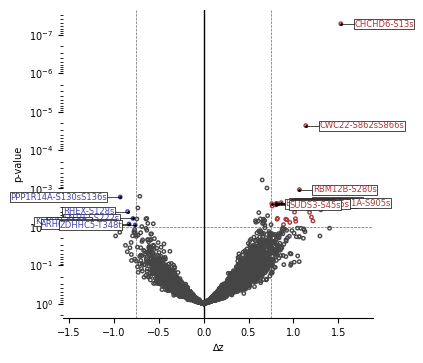

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BAHCC1-S2124s""",-1.052235,-0.027177,null,-0.609325,null,null,null,null,null,null,-0.311494,0.025109,-0.218431,null,-0.861199,-1.213404,1.237683,null,-0.249815,0.180822,null,-1.042287,-0.643291,null,-0.852207,null,-0.496672,null,0.692435,-0.452032,null,1.755884,1.153361,null,null,-1.361528,…,0.150543,0.207145,null,null,-1.097426,-0.781293,-0.362887,null,-0.181672,0.037087,0.487008,-0.578268,-0.414148,-0.783834,-0.348832,null,-2.199251,-0.70952,1.823304,-1.003962,null,null,1.213325,null,0.459333,0.10955,0.731218,1.694601,null,null,0.281965,null,2.750916,1.620716,null,1.304628,0.003611
"""BCKDHA-S339sS347s""",-2.175507,-1.814827,-0.031568,-0.779084,null,null,null,null,null,null,-1.533973,-1.60805,-2.282359,-1.018828,-2.032783,-0.673309,-0.577177,null,-0.222584,-0.975767,-1.310384,-0.492738,-0.380489,null,-1.103976,0.28406,-0.257408,null,0.134213,0.542543,0.397289,0.581269,0.400499,null,null,-0.325662,…,0.855411,0.810331,2.371008,null,-0.805339,-0.369162,-0.361268,null,0.921155,1.165111,0.706666,0.882656,0.703617,-0.629228,0.531246,0.347659,-0.33113,0.103021,0.902996,-1.142432,null,-1.044,1.522067,null,-0.726362,-0.64058,1.255999,0.855944,null,1.136344,0.589893,null,1.482368,1.399287,0.649302,0.889231,0.008768
"""CAT-S517s""",-0.171683,-0.499661,0.215802,0.47822,null,null,null,null,null,null,-2.073941,-1.562213,null,-1.911458,-1.968094,-0.706804,-0.939024,null,null,0.902418,-1.167656,null,-0.441628,null,null,0.585976,-0.946138,null,0.553075,-0.337783,-0.7673,null,-1.064433,null,null,-0.143565,…,-0.915324,0.583446,0.980729,null,-0.627967,0.411358,null,null,0.035535,0.483658,null,-1.067622,1.362436,1.091649,null,1.772105,0.071876,1.288066,-0.016206,null,null,-1.380781,0.873631,null,-0.597188,-0.328225,1.02023,1.640615,null,1.633223,0.45002,null,null,1.734465,1.231044,1.024909,0.007147
"""CBFA2T2-S33s""",-1.060678,-1.990839,1.123321,-0.976292,null,null,null,null,null,null,null,-1.602205,-1.705722,0.011627,-0.729865,-0.973629,-0.240165,null,0.605331,0.980684,-1.524401,-0.61107,-0.071963,null,-1.169713,-1.307839,null,null,null,0.161153,0.80991,1.028876,0.655677,null,null,0.072634,…,0.584766,-0.085501,1.474231,null,null,-0.138306,-0.312216,null,null,0.091348,0.23347,null,1.055743,-0.43643,0.510818,0.017242,null,0.269676,0.957605,-1.727865,null,-0.411426,1.676839,null,-0.421132,null,1.24446,null,null,1.091196,null,null,1.873663,1.372648,0.436247,1.200774,0.005562
"""CENPA-S17s""",-1.123017,-0.437616,-0.509433,-1.155435,null,null,null,null,null,null,-1.514953,-0.768568,1.643784,-0.782827,-0.842395,-1.222721,-0.107216,-0.796454,-0.899108,-1.647517,-0.901049,-0.718562,0.044518,-0.254762,-0.524132,-0.06973,-0.488885,0.066559,-0.51203,0.516147,1.085388,-0.314393,0.972052,-0.096819,0.56766,-1.368571,…,-0.136675,1.362795,0.365763,-1.019234,-1.607137,-0.644692,-1.08844,0.011972,0.389553,0.246645,0.710393,0.297025,0.041557,0.002835,1.550336,-0.32963,-0.983494,-1.087859,1.479242,-1.488735,3.165974,0.491457,0.660127,null,1.451741,-0.458

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ARHGAP30-S291s""",0.03264,1.796118,0.782238,null,null,null,null,null,null,null,null,-0.389863,-1.455548,0.533116,null,null,null,0.509521,-0.735725,null,0.119932,0.500792,null,0.081179,-0.209159,-0.127272,null,-0.37958,null,0.043575,0.230219,0.137082,-3.508699,null,0.852545,-0.230212,…,0.211478,null,-1.927879,null,null,null,0.647123,1.085959,null,0.813825,-0.248531,null,1.039325,null,0.582019,2.013657,null,1.220147,null,-0.860396,-1.853687,0.836419,null,null,-0.979831,null,null,null,-1.384694,-0.92742,null,-1.021918,-0.737721,0.347254,-0.262926,-0.83076,0.008446
"""KLF2-T173t""",null,null,null,null,null,null,null,null,null,null,-0.755706,null,null,-0.423382,null,null,null,0.432525,null,null,-0.56171,null,null,0.018654,null,0.458242,0.683827,-0.20086,-1.900991,null,0.698992,null,null,0.747059,2.602417,null,…,null,null,1.106948,-1.027967,-0.281189,null,null,0.221612,1.862341,null,null,1.508362,null,null,null,0.22998,1.031824,null,null,null,0.16193,0.817581,null,null,null,-1.706704,null,0.700411,-1.716109,-0.609068,-1.310954,-1.201516,null,null,-0.984084,-1.210881,0.00725
"""LYN-S187s""",null,null,0.285898,-0.255992,null,null,null,null,null,null,-1.085873,-1.473566,-1.575439,-0.962637,null,null,null,-1.011991,-0.472928,null,-0.748078,0.180857,null,0.120486,-0.487132,0.117629,0.449473,0.348449,-0.917962,0.399844,-0.881933,0.98153,-0.684831,0.700191,1.230757,0.52553,…,1.008979,null,0.681314,-1.336925,1.263766,null,0.318469,0.166103,1.447613,1.254672,-0.470615,1.237386,1.039894,null,1.099405,1.71739,-0.07616,0.357655,null,-0.916883,2.049317,0.078094,null,null,-2.613058,-1.364933,null,-0.380314,-0.845163,-1.195445,-1.794723,-1.200182,0.247918,0.955202,-1.033667,-1.099828,0.007604
"""PPP1R14A-S130sS136s""",null,null,null,-1.011037,null,null,null,null,null,null,2.384799,0.877412,null,1.862016,1.056542,-0.426798,0.545605,1.156159,-0.257111,-0.843245,0.477515,0.289731,2.463641,-0.451673,-1.098693,-0.832511,-0.869038,0.030256,-0.888131,0.27736,-0.354228,-0.831745,-1.461961,-0.416287,1.6543,0.276441,…,1.852209,-0.559541,-0.016653,-0.676768,1.875787,0.264311,1.452487,0.184053,-0.13125,-0.209511,-0.37394,-0.354519,0.22906,-1.284474,0.280916,0.420637,-0.913132,0.717304,0.084041,null,-0.481744,-0.794686,0.504954,null,-1.570742,-1.386008,-0.999033,-0.459486,-1.157441,-0.023721,-1.100151,-1.303129,0.471223,-0.540085,-1.726931,-0.929055,0.00167
"""RHEX-S128s""",null,null,1.767886,-0.706716,null,null,null,null,null,null,0.334756,-0.334782,-1.547168,-0.024848,-0.885524,-0.052446,-1.015285,1.192547,-0.844336,-1.134345,0.469187,1.981477,1.717578,-1.005965,0.578232,0.012615,0.624525,0.991533,-1.200754,1.608952,-0.059472,0.894035,-1.161223,2.535897,0.227449,0.227421,…,-0.424704,-1.192831,0.801274,-0.876858,-0.371327,-0.756811,-0.598264,0.330895,1.01136,-0.182131,-0.248139,1.25267,0.233821,-0.540121,-0.400748,0.347251,0.960733,-0.071377,-0.236496,-1.207865,-1.27014,0.905887,-1.316499,null,-1.074273,-2.041543,-0.322525,-0.048375,-0.855252,0.433

Acetylomics


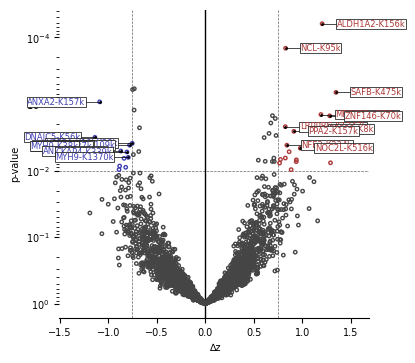

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH1A2-K156k""",null,null,null,null,null,null,null,null,null,null,-0.369883,-0.709942,null,null,-1.03039,null,1.590511,-1.145528,null,0.049072,null,null,-0.479702,0.431065,null,null,-0.596553,-0.680121,1.647852,0.289513,null,null,0.959803,-2.291537,0.267975,0.395996,…,-1.297267,0.155227,-0.013573,null,-0.321124,0.544323,null,1.142353,-0.138855,-0.179723,null,-2.027824,-1.13315,null,null,0.223496,0.499573,0.049143,0.395758,null,-0.529846,null,null,null,2.318601,0.689022,1.001942,0.458408,0.91526,1.61286,0.17286,0.84844,null,0.672348,0.966143,1.206985,0.000062
"""ALG5-K126k""",null,null,-0.662754,null,null,null,null,null,null,null,null,-0.079722,null,-1.02947,-1.126708,1.243909,-1.250657,0.542403,null,-2.828354,null,null,0.825993,-0.269741,null,1.015352,null,0.182459,null,-1.313132,0.356099,null,-1.253096,-0.412626,0.579144,0.608272,…,-1.308871,0.658676,0.925064,null,null,0.300732,null,0.874848,null,-1.085988,null,null,-0.465047,0.440006,null,-1.114964,null,-0.172107,0.079384,null,-0.75007,null,null,null,1.288498,null,1.197416,null,1.069671,-0.483958,null,0.375905,null,1.00237,1.113177,0.941122,0.006909
"""ATAD2-K47k""",null,null,1.667755,null,null,null,null,null,null,null,-0.718608,-0.131296,null,null,-0.241486,null,0.872572,0.447689,-0.262194,1.413834,null,null,-1.299691,0.256476,-3.744485,-0.92723,0.832211,-0.631423,-0.731477,-0.153372,0.596548,-0.198892,-1.348201,0.794848,0.191883,-0.253976,…,0.914175,0.03029,0.364563,0.050344,-2.961956,-0.918607,-0.032054,-0.008554,0.072634,-1.044955,0.104665,-1.027497,0.556658,1.258407,0.168244,-0.489101,-0.568851,0.074588,0.925359,null,0.466087,null,null,null,0.82646,1.313177,0.701266,1.095247,0.496173,null,0.095117,0.343224,1.854261,-0.726895,1.288841,0.866175,0.005221
"""CMBL-K36k""",null,null,null,null,null,null,null,null,null,null,null,null,null,-0.465829,0.607697,-0.922946,-0.773486,-0.221478,null,-0.727897,null,null,1.639143,2.08135,null,-0.673213,null,0.369678,null,-0.82336,-0.857175,null,0.003039,-0.712408,-0.294001,1.542139,…,0.764244,-0.699267,-0.054331,null,null,-0.512604,null,-0.802801,null,-0.50453,null,null,null,-0.795177,null,0.034201,null,-0.774209,-0.939383,null,-0.136115,null,null,null,null,null,0.364208,null,1.252454,2.574313,null,0.797942,null,0.548159,1.02865,1.293249,0.007648
"""ETFA-K85k""",null,null,null,null,null,null,null,null,null,null,-0.334157,0.841186,null,null,-0.320009,-1.846043,0.497647,-1.588849,1.463933,-0.240657,null,null,0.688242,-0.215161,1.041616,null,-1.2,-0.441393,1.338238,-0.00019,null,-0.004555,1.068572,0.590108,0.336792,-1.521951,…,-0.08022,0.293686,null,-0.579841,0.122757,-0.934771,-0.196665,-0.509088,-1.174888,-1.329621,-1.181273,-0.533101,-1.450993,-0.744942,-0.395419,null,-2.035999,-1.043126,1.550815,null,0.453911,null,null,null,1.56873,0.48151,0.644533,1.674403,-0.394629,null,0.792526,0.75462,-0.035173,0.805077,null,0.827466,0.006489
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ANXA11-K264k""",null,null,0.792781,null,null,null,null,null,null,null,-0.053411,0.294344,null,0.462808,null,0.529057,null,-1.070745,-0.148097,-0.964009,1.092665,0.20961,-1.397877,-2.012895,1.240693,-0.403283,0.592864,0.90986,-0.200201,1.469561,-0.323213,-1.249904,1.195869,-0.123948,1.141721,1.300537,…,-0.078527,0.185995,-1.092902,0.521755,1.174859,1.200596,0.156019,0.576274,0.793944,-0.18595,-1.701474,-0.616156,-0.892707,-0.542421,-0.412857,-0.257012,-0.076539,-1.003353,0.23435,1.714165,-0.315346,null,null,null,-1.415712,0.266289,-1.317147,-1.367905,0.539993,-0.68214,-1.311841,0.28241,-0.323123,-1.43983,-1.279569,-0.870457,0.005092
"""ANXA2-K157k""",null,null,0.389511,null,null,null,null,null,null,null,-0.200028,-0.483728,null,0.440728,-0.269419,0.281432,-1.669021,-0.311279,null,-1.058614,0.397034,1.14191,0.241228,null,0.242047,0.100727,1.664827,-0.30908,-0.648444,0.416344,-0.801626,null,-1.599126,-1.260698,0.679592,-0.43059,…,0.663241,-0.831162,-1.592199,1.004227,-0.060514,2.280994,null,0.603585,1.503838,1.047973,-0.015405,1.239477,1.700818,1.306903,0.753996,1.455752,1.134288,1.814498,0.458702,null,0.830699,null,null,null,-0.779656,-0.747608,-0.540138,-1.195855,-1.503408,-2.348281,null,-0.023805,-1.510865,-0.588904,0.049288,-1.089094,0.00093
"""ANXA6-K299k""",null,null,-0.424085,null,null,null,null,null,null,null,-0.504086,1.312762,1.561465,0.384061,1.927665,-0.525593,0.315394,0.536358,0.156988,0.59924,1.680834,1.934731,0.990073,-1.17016,2.38776,1.6913,1.295345,-0.4814,-0.512062,1.437254,-0.324935,-1.365038,-1.703312,-0.642849,2.199231,-0.498795,…,-0.849255,0.840885,-0.112859,-0.111141,0.27507,-0.807644,-0.196952,0.025634,-0.541637,0.318102,-1.201825,0.255802,0.503861,-0.879827,-0.332373,-0.18026,0.60865,1.134388,-1.069697,-1.761629,-0.13981,null,null,null,-0.573124,-0.08107,-0.162556,-0.705715,-1.497659,-0.846288,-1.277713,0.194213,0.562835,-1.513829,-1.900597,-0.837121,0.006561
"""ANXA6-K478k""",null,null,-0.367426,null,null,null,null,null,null,null,-0.220279,0.994721,null,0.211767,-0.708496,2.160963,null,0.935969,null,null,0.966734,null,null,-1.461287,null,-0.209603,-0.02244,-0.249623,-1.055805,1.347353,-1.543199,null,-1.7364,-0.750653,1.140776,-1.035402,…,0.694257,-0.527747,-0.633317,0.229533,0.967173,1.155509,null,0.079004,2.063297,1.168217,null,0.101569,1.207733,-0.39074,null,-0.002841,1.561591,0.99134,-0.181135,null,-1.080405,null,null,null,-1.492221,-0.121414,-0.623068,-1.621581,-1.708949,-1.54953,0.100708,0.456302,null,-0.852903,0.113658,-0.888574,0.009673
"""CKAP4-K339k""",null,null,0.045992,null,null,null,null,null,null,null,null,null,null,null,1.475156,null,-0.108534,null,0.443083,0.039128,null,null,-0.722008,null,0.598237,0.891986,0.93435,null,-0.484253,1.465914,-1.100434,-0.861541,-0.189104,null,null,0.001077,…,-1.637761,null,0.391968,null,-0.663111,0.080997,0.481154,null,0.151341,-0.342368,0.200989,-2.110297,-0.751633,0.681237,0.995688,-0.54012,1.986029,0.358481,null,1.369983,null,null,null,null,0.22

Lipidomics


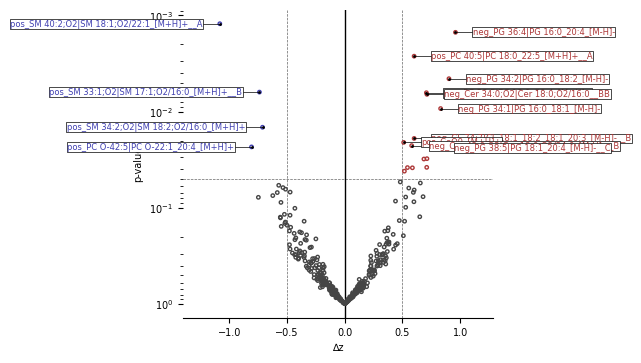

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-1.026088,null,-0.117171,null,-1.456102,-1.695909,-0.666708,-1.43029,-0.247797,-0.193849,-0.469651,0.955736,0.357302,1.52066,0.260954,-0.610372,-0.865169,-1.239476,-1.643506,-0.499413,-0.804387,-0.717376,0.41998,-0.015566,1.633892,0.439267,-0.722465,-0.404761,-0.500751,-0.864926,1.717083,-0.177731,-0.922053,-0.296107,-0.585334,0.28702,…,0.966795,-0.077692,0.031548,-0.914923,-0.258494,-0.654589,0.460993,-1.400365,0.660105,-1.135166,2.309031,0.687791,-0.684941,-0.144148,-0.064927,-0.832699,0.409253,0.147075,0.381762,-0.095872,2.137214,null,null,1.737035,0.944677,-0.125704,1.122952,0.613295,-0.841942,2.390645,0.004682,-1.065086,0.434039,0.950928,1.076928,0.710044,0.038041
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.340335,null,0.218527,null,-1.932322,-2.406405,-0.68671,-0.571188,-0.919682,0.759857,-1.572058,0.960614,-0.119528,2.181545,0.169754,-1.92751,-0.011521,0.430112,-0.226195,0.765619,-1.613844,-0.5874,-0.474094,-0.155141,-1.071227,-0.053454,-0.338196,0.494564,-0.106739,0.382773,0.760043,1.031869,-1.114737,0.564197,0.826685,-1.914357,…,0.571289,-0.152852,1.22022,0.821289,-1.637335,-0.028234,-0.979288,-0.498128,0.511179,-1.515896,0.658523,0.918499,0.438067,0.714617,0.105111,-0.269862,-0.935576,-0.814874,0.330286,-0.636788,0.94519,null,null,0.685042,1.021064,-0.160527,0.791535,0.917158,0.080528,1.255364,0.154534,1.222365,1.526971,2.502309,-0.212387,0.959211,0.001498
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.201948,null,0.807437,null,-2.425376,-1.950197,-0.901433,-0.469489,-0.874007,0.291913,-0.094215,0.806944,-0.816506,1.147944,-0.377379,-1.134662,-0.889379,-0.800744,-0.474485,-0.280492,-1.107187,-1.276204,0.049753,-0.080536,1.342462,0.411602,-0.525378,-0.953551,-0.840016,-0.53714,0.80944,0.249893,-0.399752,-0.336232,0.019916,0.035402,…,1.051129,0.087302,0.558435,-0.618646,-1.374801,-0.293283,1.155505,-1.346216,0.877172,-1.080304,2.390239,0.475893,0.161114,0.27159,0.216312,-1.009873,-0.022114,-1.458699,0.44636,0.009011,2.172177,null,null,1.524705,1.441831,-0.314636,1.469702,0.440681,-0.948954,2.636316,0.011458,-0.250176,0.833936,1.209136,0.070808,0.79655,0.024037
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.860827,null,0.214143,null,-2.285054,-2.733674,-0.90161,0.149202,-0.69581,-0.138814,-0.744371,-0.498259,0.258655,1.043455,0.897362,0.484119,0.832347,-0.810865,1.019337,0.205088,0.09749,-0.059863,0.137274,1.425652,-0.762361,0.035546,-0.94593,-0.801565,-1.078435,-0.614504,0.666295,0.998967,-0.568409,-0.499817,-0.770458,-0.77007,…,0.381552,-0.251847,1.884311,0.477229,-1.345769,0.173794,-1.647833,-0.431287,-0.272515,-1.373416,0.148059,-0.188654,0.510904,2.020612,-0.363926,-0.360044,-0.220717,-0.113946,0.804216,0.075392,2.515141,null,null,0.124661,0.144209,0.32372,-0.721573,1.534172,0.068811,1.330544,0.230418,0.910563,2.071497,1.864777,1.325967,0.902722,0.004551
"""neg_PG 38:4|PG 18:1_20:3_[M-H]…",0.649278,null,0.700724,null,-2.122897,null,-0.379281,-1.054205,-0.325795,0.26149,-0.439199,0.322172,2.76

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""pos_SM 34:2;O2|SM 18:2;O2/16:0…",-0.937639,null,-1.081971,null,0.55091,1.094313,-0.544383,0.088746,1.10462,-0.350267,-0.877878,-1.765617,2.502524,0.556313,0.029076,-2.007571,-0.158079,-0.11448,0.290828,1.105793,-0.70794,-0.215718,-0.538314,0.945664,-1.611254,-1.878051,-0.883852,-1.140067,-0.84647,-0.934947,0.295353,0.093994,-1.07946,1.554317,0.791486,0.192729,…,2.142828,0.544783,0.621257,0.270435,1.848861,1.043835,0.744117,-1.301189,-0.397645,0.201695,1.253746,-0.627496,1.002989,0.559709,0.330906,-0.229451,1.379897,1.650492,1.183369,-0.822692,-0.770238,null,null,-2.207772,-1.488786,-0.584517,0.095584,-1.130708,-0.257467,0.815421,-0.94943,-0.541291,-0.076978,-0.968027,0.021187,-0.713018,0.014554
"""pos_SM 33:1;O2|SM 17:1;O2/16:0…",0.937661,null,-1.447156,null,1.548402,1.395582,0.525834,0.171584,1.767521,-0.237558,-0.773187,-1.972775,2.274442,1.596801,-0.18164,-1.159549,0.154445,-0.229402,1.385898,0.727872,-0.519985,0.409457,-1.45008,1.000561,-1.071178,-2.051166,0.008151,-0.626108,0.748042,-0.930657,-0.214571,0.141193,-0.982275,1.314518,1.27547,0.647458,…,0.9166,0.990747,0.775325,-0.226708,1.88123,1.603735,0.274564,-1.08,-0.803016,-0.096004,0.165264,-1.206447,0.161333,0.932001,-0.012076,0.074243,0.076165,1.450533,0.591841,-1.223821,-0.307324,null,null,-1.668652,-2.014154,-0.014034,-0.297648,-0.950741,0.260687,0.078878,-0.415803,0.080842,-0.827775,-1.130283,-0.648652,-0.739935,0.006274
"""pos_SM 40:2;O2|SM 18:1;O2/22:1…",0.970345,null,-1.329058,null,1.652121,0.935363,0.886017,0.735755,2.042047,-0.88764,0.057865,-2.072394,1.686721,1.528247,-0.060278,-1.002918,-0.414336,0.150204,1.223817,0.857427,-0.080357,0.274652,-1.186525,0.735654,-1.390508,-1.64105,-0.329278,-0.848619,0.106047,-0.615394,-0.182578,-0.216951,0.632632,1.016985,1.469386,0.373793,…,0.223943,-0.272758,-0.244454,0.699895,1.963752,1.42705,1.244911,-0.02442,-0.193641,1.312231,0.449668,-0.375188,1.484729,0.764989,0.200323,0.391396,-0.305128,0.828026,-0.553282,-0.141538,-1.903087,null,null,-1.493064,-2.475641,-1.432773,0.165444,-0.098266,-0.551035,-0.314461,-0.611775,0.083438,-1.932495,-0.609532,-1.778874,-1.083239,0.00122
"""pos_PC O-42:5|PC O-22:1_20:4_[…",1.091798,null,0.429372,null,-2.878438,-0.029464,-1.508027,-0.231138,-1.33116,-0.26284,0.208687,-0.258291,-1.001176,0.0213,-0.257877,0.66177,-1.310124,0.744896,-0.375911,-1.8706,-0.268576,-0.517183,0.295484,-0.67006,-1.244778,-0.030952,0.912621,-0.503743,0.258227,0.216417,-0.404223,-0.370007,0.380409,2.069868,0.493401,1.220726,…,-1.066215,-1.432849,-0.43856,0.81706,1.244825,1.179258,0.899507,1.214973,0.911103,0.560933,0.409824,0.329947,2.712752,1.246473,1.412482,0.332589,1.274175,0.574351,-0.19548,1.435892,-0.364305,null,null,-1.610751,-2.807569,-0.338199,-0.198632,-0.078384,0.596322,-1.195202,-1.219916,0.081064,-1.341538,0.825643,-0.958147,-0.808364,0.023307


Metabolomics


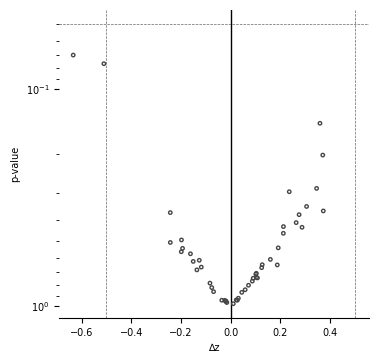

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITD-WT ============
Transcriptomics


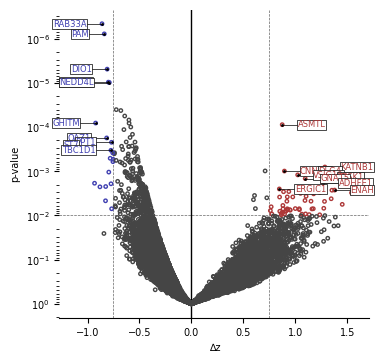

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PKD1""",null,-0.051203,null,0.548409,-1.346698,null,1.311629,-0.973918,-0.099316,-0.139383,-0.58261,1.173245,-1.224536,-0.591472,0.937574,0.169933,-1.866225,-1.293092,null,-0.665097,-1.329593,null,null,0.282309,0.445036,-0.845203,-0.303386,null,-1.110297,-0.136686,-0.216464,-0.750247,-0.109389,1.011133,0.321073,null,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.340921,null,null,0.854761,0.174917,0.354817,0.327415,null,null,1.86299,1.522687,0.023663,-0.076036,null,null,1.771021,-1.273913,2.825561,1.151014,1.66726,null,null,null,0.946806,0.007417
"""TRAF3IP2""",null,-0.222064,null,-0.323481,-0.329278,null,1.534188,-0.282395,-0.236499,-1.681889,0.528962,-0.809286,-1.466993,-0.011539,-0.717661,1.274756,-0.782921,1.671044,null,-0.99606,-0.164871,null,null,-1.442367,-1.490303,-1.606516,-1.210633,null,-0.889139,0.233698,0.887087,-0.108705,-0.244339,0.405059,2.341039,null,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.341757,null,null,0.344823,0.103737,2.154503,-0.98289,null,null,0.953908,0.410272,0.131712,1.293168,null,null,0.721118,1.669122,0.913976,1.410317,-0.084051,null,null,null,0.759346,0.007776
"""GNA15""",null,-0.848509,null,-0.288334,-0.8965,null,0.125049,-0.936966,-0.476272,-0.020517,1.223277,0.622357,-0.431538,3.425311,-1.417382,0.097056,-0.649836,3.34142,null,-0.919489,-0.441351,null,null,0.812363,0.323819,-1.138945,-0.941057,null,-1.070431,-0.38362,-0.201566,-0.966581,-0.737148,-0.019632,0.936308,null,…,null,null,null,null,null,null,null,null,null,null,null,null,0.537648,null,null,1.393793,-0.500892,0.85433,-0.582798,null,null,1.666826,2.027892,-0.143305,-0.047479,null,null,1.816909,0.151628,2.550549,1.632713,1.180452,null,null,null,1.094611,0.001457
"""IFT80""",null,-1.190498,null,1.756642,-1.00948,null,0.039022,-1.077924,-0.427494,-1.109736,-1.17712,0.429742,0.340206,-0.936547,-1.059425,-0.246272,-1.731362,-1.578612,null,-0.524972,-1.54783,null,null,0.669285,0.136634,-1.0917,-0.492071,null,-1.287973,0.772857,1.09252,-0.594067,-0.590977,-0.061771,0.332065,null,…,null,null,null,null,null,null,null,null,null,null,null,null,1.588124,null,null,1.550313,0.622342,0.716052,0.314776,null,null,0.106077,0.551785,-0.683191,1.534085,null,null,1.510978,-1.559181,2.684569,0.559092,0.927452,null,null,null,0.909968,0.007963
"""MKNK1""",null,0.617989,null,-0.74427,-0.874249,null,1.264447,0.044023,0.45466,0.491583,-0.982578,0.412163,0.206604,-0.366488,0.102081,-0.74688,-1.001952,-0.362705,null,-0.636583,0.076097,null,null,-0.974695,-0.886688,-0.563951,0.405473,null,-0.486055,0.07978,-0.129421,-0.786254,-0.863122,-0.063595,-0.805737,null,…,null,null,null,null,null,null,null,null,null,null,null,null,3.948058,null,null,-0.284259,0.403999,-0.334091,2.026307,null,null,1.223027,3.198054,0.318036,1.543819,null,null,0.006826,-0.22315,-0.444068,1.48758,0.104975,null,null,null,1.132748,0.009575
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ST7""",null,0.569372,null,2.525946,0.466514,null,-0.833452,-0.426826,-0.338225,-0.240832,1.151625,-1.100472,-1.179564,-0.760301,0.504839,0.326113,-0.747847,-0.963624,null,0.680479,-0.811555,null,null,0.97598,2.56043,0.525738,1.05455,null,-0.430504,1.65082,-0.229204,0.410789,0.576563,0.287748,-1.056201,null,…,null,null,null,null,null,null,null,null,null,null,null,null,-1.555066,null,null,-1.461427,0.484325,-1.569599,-0.550104,null,null,-0.66342,-0.214944,-0.573529,-0.813613,null,null,0.501848,-0.738946,-0.8544,-1.150315,-1.540793,null,null,null,-0.934126,0.000251
"""NEDD4L""",null,2.401289,null,-0.774281,2.411114,null,-0.382207,-0.71407,0.191302,-0.905534,-0.36536,-0.639582,-0.713055,-0.520711,-0.233647,1.352755,0.073138,0.669687,null,0.880262,0.078061,null,null,-0.906439,-0.185228,3.152248,2.371409,null,-0.813637,-0.897857,-0.630711,1.66099,0.884892,-0.789418,-0.895083,null,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.951953,null,null,-0.717164,0.207773,-1.000523,-0.894597,null,null,-0.767169,-0.838075,0.031355,-0.409981,null,null,-0.875833,-0.761742,-0.618055,-0.889323,-0.565965,null,null,null,-0.790189,0.00001
"""TBC1D1""",null,2.737423,null,-0.222906,-0.529031,null,-0.812906,0.282628,-0.24211,0.12906,-0.325574,-1.108669,0.309082,-0.255057,2.156514,1.251909,-0.619268,-0.318566,null,0.57785,-0.893102,null,null,-1.118771,-0.230785,2.181246,1.908826,null,2.228235,0.864702,-0.202895,1.2258,0.076337,0.351595,0.549743,null,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.368059,null,null,-0.51466,0.415732,-1.015053,-1.428111,null,null,-1.13019,-1.321323,-0.497447,0.036746,null,null,0.097256,-0.615082,-0.965335,-0.944559,-0.620085,null,null,null,-0.77438,0.000334
"""SDHA""",null,2.301985,null,0.627719,0.781452,null,-1.234134,-0.35307,-0.00172,-0.337965,1.599837,-0.462216,0.990652,-0.425067,1.312579,0.131246,-1.113905,-1.249725,null,0.754836,-1.382404,null,null,-0.147993,-0.780899,1.436083,1.025939,null,1.57179,-0.15386,-0.658537,0.30212,0.037414,0.585728,1.000108,null,…,null,null,null,null,null,null,null,null,null,null,null,null,0.761838,null,null,-0.536997,0.886507,-1.415351,-1.872234,null,null,-0.469468,-0.693538,-0.83176,-0.538737,null,null,-0.190192,-1.858633,-1.469478,-0.559547,-0.007459,null,null,null,-0.767822,0.007049
"""ANKRD13""",null,0.115935,null,-0.714874,0.305236,null,-0.660757,0.262316,0.398231,0.512161,1.190848,-0.632466,-0.908135,-1.074572,-0.169894,-0.423317,2.632772,-1.442151,null,1.269919,0.113185,null,null,-0.659254,-0.787056,-0.843685,-0.552072,null,1.097785,-0.842477,-0.458844,1.026716,-0.50429,-0.59777,-1.023199,null,…,null,null,null,null,null,null,null,null,null,null,null,null,0.002743,null,null,-1.0022,0.855022,-0.094627,-2.288267,null,null,-1.31118,-1.462459,0.194885,0.265717,null,null,-0.883016,-1.535141,-1.17979,-0.678095,-0.352437,null,null,null,-0.826645,0.004652
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Proteomics


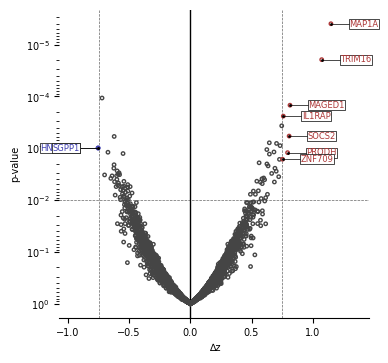

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""IL1RAP""",-0.600493,1.359504,0.426053,-1.412426,-0.544017,-0.57565,-2.12488,-1.815266,-2.195783,1.34522,-0.543202,0.023259,-0.124803,-0.243251,0.791255,-1.315773,-1.39927,0.467329,1.060623,-0.050548,-0.9247,-0.012467,0.542666,-1.155644,0.368584,0.403109,0.084188,0.486713,0.81567,0.138695,-1.460794,0.208421,-1.699989,0.268407,0.467397,-0.043795,…,0.801668,-1.146442,0.989108,-0.830498,1.496025,0.422338,0.662355,-0.92921,-0.334643,0.692868,1.551973,1.363612,0.073934,1.440829,0.119386,0.345913,-0.782934,0.714869,1.835825,-0.330543,0.604313,1.572775,1.270844,0.788906,1.902156,1.988918,-0.60169,-0.296545,-0.330584,0.461542,1.71089,0.013407,-0.790931,1.054692,-0.598569,0.759826,0.00024
"""MAGED1""",0.300119,-1.783277,0.633567,-0.731963,-1.11713,0.719189,null,-0.705639,0.677084,1.016305,1.290833,0.566096,-0.593087,-1.326374,-1.424686,-0.152592,-1.302872,-0.11546,-0.202374,-0.120603,-0.481109,-0.170305,0.330533,0.555913,0.164683,0.003673,-0.309781,1.672284,-0.497809,0.553406,-1.43274,-0.987037,-0.888315,0.364913,-0.059338,-0.868639,…,0.707436,null,-1.1081,-0.067797,1.987484,-1.15281,0.228962,0.231416,0.581993,0.224529,1.788848,2.014591,-0.269955,2.627814,0.45666,-0.082053,-0.059893,-0.708897,1.891668,0.855189,-0.324531,1.168999,0.794049,0.138941,1.910327,-0.879186,-0.633414,0.55416,0.199804,0.130177,0.390446,0.508278,1.148149,1.662401,0.812417,0.814443,0.000148
"""MAP1A""",0.633355,-0.339799,1.090892,-1.236583,-0.097987,0.26325,-1.813366,-1.849559,-0.803396,0.124168,-0.652482,0.564114,0.285845,-0.708258,-0.727359,0.309815,-1.38643,-0.242974,-0.345779,-0.185391,-0.786984,-0.157175,0.953711,0.069562,-0.559414,-0.419188,-0.84552,1.920235,-0.112875,0.65075,-1.267476,-0.471019,-1.418145,-0.438048,-0.092023,0.641176,…,-0.721229,-0.822271,0.518718,-0.16952,1.68724,-0.027286,1.618157,0.066699,-0.797727,0.261376,1.49064,1.872314,-1.175404,1.821909,1.179129,-0.158503,-0.263735,0.020873,1.258831,0.597997,-0.332167,2.395393,1.975347,0.712186,1.799435,1.95608,-0.965317,1.882735,-0.595293,1.056613,2.255789,1.1399,-0.320885,2.884403,0.548109,1.148885,0.000004
"""PRODH""",0.201842,0.68627,1.014204,-1.652753,null,-0.257338,-0.316328,-1.099283,null,-0.187209,0.49477,-0.574982,-0.660515,-0.595426,-0.526771,0.218706,null,0.397645,-0.517972,0.478319,-0.590951,-0.221092,-0.86911,-1.112636,-0.252786,-0.650631,-0.304342,2.194592,0.777071,0.563542,-0.703133,null,-1.960042,null,1.230511,-0.135306,…,-1.640872,-1.217654,-1.530263,-0.821493,0.194616,0.889021,0.533516,0.338885,0.33802,null,2.172669,1.051867,null,null,0.390337,0.264839,0.932025,0.46711,2.131407,null,-0.695857,2.329067,1.449912,0.485174,1.581683,-0.76025,-1.208004,-0.886179,-0.528518,-0.943501,2.047479,0.541727,1.385595,1.588026,-0.730153,0.794798,0.001218
"""SOCS2""",-0.397624,0.794985,0.317249,-1.417996,0.486637,-0.636186,-1.203618,-1.370969,-0.057083,0.048802,-0.257971,-0.514964,0.657599,0.279623,1.424394,-0.063113,-0.386013,-0.180228,1.331658,-0.064555,-0.240397,-0.674478,0.087658,-1.220955,-0.348451,0.31967

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HNRNPLL""",0.743771,2.027672,0.27844,-1.189738,0.565591,-0.719008,-1.555242,-1.115478,0.483122,-0.140321,0.791262,-0.165907,0.621384,-0.454654,1.843673,0.338881,-0.025533,0.563,1.367942,1.503277,0.14146,-0.001607,-0.643976,-0.147773,0.413497,0.893192,1.474779,-0.038025,1.60677,0.652393,-0.808333,0.134196,-0.27525,0.256228,-0.574126,-1.374816,…,0.83932,0.37076,0.84946,0.322029,-0.470532,0.628247,-1.849123,-0.885252,-2.277801,-0.685248,0.226853,-1.30079,-1.571743,1.310435,-0.579581,0.766122,0.825263,-1.18721,0.376201,-2.058143,-0.324166,-1.126511,-1.499481,0.634082,-0.833629,-1.171786,-1.199794,-1.649279,0.542825,0.028965,-0.392093,-0.923814,1.327781,-2.312618,0.663523,-0.754295,0.00099
"""SGPP1""",0.418142,1.239834,0.081016,-0.75866,null,null,-0.351805,-0.397789,null,1.560821,1.380686,-0.233953,1.800358,-0.262345,null,-0.047467,null,0.392447,0.232167,1.507596,-0.18864,-0.95065,0.116963,-0.763143,-0.802677,0.763575,1.358688,null,1.472599,-0.809366,null,-0.779205,-2.117135,null,-0.288241,-0.303434,…,-0.057515,0.427431,-0.419427,-0.999171,1.080898,0.318645,-1.286944,0.135076,-1.57109,null,-0.292844,-0.110847,null,null,-1.523973,-0.819561,0.854438,-1.04321,0.561834,null,-0.386412,-0.149248,null,-0.36824,0.515099,null,-1.108708,-0.791583,-0.633938,-2.570637,-0.242653,-0.612916,-0.191411,-1.800833,-1.382816,-0.753357,0.000992


Phosphoproteomics


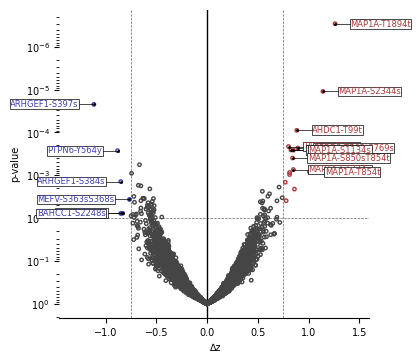

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AHDC1-T99t""",0.440189,0.544099,null,-0.920394,null,0.439691,null,-2.165503,-0.767079,1.348338,0.740031,0.753502,null,-0.494105,-0.211237,0.316469,-1.268195,null,-0.321491,-1.270198,null,null,1.515567,-0.907065,0.832202,-0.2381,-0.002096,0.259647,0.009966,-0.309999,-0.685295,null,-2.543737,-1.365468,null,-0.256084,…,-0.371504,-1.408189,-1.424517,-0.469069,2.181066,-0.366331,1.137797,null,-0.71133,1.290456,1.192102,1.167661,-1.388482,1.420947,0.624147,0.079182,null,-0.195469,1.018016,1.36537,0.277769,1.176465,null,1.4038,1.291234,1.828798,-0.736211,1.194792,-1.011246,0.596593,1.346255,0.242801,0.087643,0.263325,0.090462,0.883542,0.000089
"""MAP1A-S1134s""",0.878294,0.318199,0.869389,-1.879615,-1.0844,0.15068,null,-2.122904,-1.2773,0.562141,0.068796,0.555939,-0.718417,-1.430313,-0.147971,-1.666622,null,-0.208391,-0.681881,-0.597976,-0.15645,-0.542299,1.272356,0.186964,0.466339,-0.468629,-0.129455,1.229777,0.306334,1.216417,-0.921329,-0.258866,-1.799273,-0.779661,-0.270226,0.332932,…,-0.813467,-1.019025,1.445388,-0.504177,1.479669,-1.885425,1.397951,1.702304,-0.871707,0.358276,0.807179,1.814007,-0.779661,1.375889,1.001756,0.228209,-0.857875,-0.083538,1.07879,0.158114,0.123688,2.00169,0.432566,0.931483,1.732321,1.539827,-1.010087,1.449955,-0.771633,0.793555,2.027727,1.016441,-0.774808,1.837689,0.517327,0.849326,0.000259
"""MAP1A-S1147s""",0.319895,0.402897,0.827798,-1.34772,-0.374505,-1.164147,-1.977074,-0.93196,-2.271883,0.440958,-0.067231,0.696112,-0.48459,-1.271875,0.450859,-0.818526,-1.253058,-0.01168,-1.960053,0.037654,-0.928082,-0.15215,1.452915,null,0.103141,-1.184431,0.230702,1.178551,-0.184054,0.556204,-0.839941,null,null,-0.004251,0.342841,0.805367,…,-0.397695,-0.777009,1.617048,-0.855199,1.415092,-0.94664,0.814952,-0.660519,-0.733771,0.532365,0.96268,1.350166,-1.622751,1.240143,0.99348,-0.080353,-0.534339,null,0.1309,1.149472,-0.633008,1.500537,1.45078,0.953123,1.889101,1.897793,-0.862051,1.289203,-0.691393,0.63012,2.123555,1.14697,-0.716028,3.06863,0.353703,0.812556,0.000861
"""MAP1A-S1224s""",0.502727,0.276682,0.990774,-1.538509,-0.399074,0.105879,-1.507725,-1.632843,-0.120916,0.51805,null,0.602651,0.130694,-0.805251,-0.38556,0.367626,-1.470119,-0.031766,-0.060889,-0.555668,-1.66314,-0.340981,0.665382,0.006333,0.092403,-1.109115,-0.43269,1.409149,-0.190511,1.041955,-0.841443,0.289146,-1.026109,0.070177,0.085522,0.648694,…,-0.413738,-0.920474,null,-0.673052,1.442545,-1.100845,1.30299,-0.3783,-1.621062,0.247823,0.848084,1.280094,-1.88322,1.688783,1.440284,0.038681,-0.542425,0.042763,0.365543,0.609485,0.398352,2.510034,1.450497,1.040704,1.815473,1.467229,-1.677613,2.06058,-0.870539,1.127056,1.68813,0.937518,-0.282357,2.399937,0.9463,0.850269,0.000734
"""MAP1A-S1549s""",-0.287937,0.419747,0.637021,-0.65623,null,-0.630773,-1.752119,-1.57439,-1.038167,0.324727,-0.101032,0.616545,-0.765376,-0.86264,-0.762209,-0.773963,-1.176436,-0.123254,-0.146103,-0.229503,-0.873744,-0.267793,1.043297,0.560387,0.201348,-0.469805,0.299248,2.198228,0.096

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ARHGEF1-S384s""",null,null,null,-0.707648,null,1.445655,null,null,-0.571953,1.0985,null,0.823997,null,0.246005,1.173374,-0.348817,null,null,1.076824,0.943461,null,null,0.562138,-0.344393,1.222317,0.693505,null,-0.797425,1.001877,0.777572,-1.280835,1.079724,0.270792,0.075384,null,-0.723674,…,1.543068,-0.360007,0.659311,1.248013,0.790288,null,-0.526356,null,-2.073225,-0.246582,-0.834596,-0.044911,-2.04369,null,-0.090144,-2.022982,null,-2.347321,0.529095,0.005644,-1.121593,null,-0.38607,1.064786,0.703506,-0.265958,-1.904063,null,-0.440365,-0.395393,-0.286115,-1.683039,null,-1.156889,1.180368,-0.849725,0.001397
"""ARHGEF1-S397s""",null,null,0.937437,-1.272497,1.577377,null,-1.551849,null,2.121558,-0.106907,null,1.056559,-1.046923,-0.312383,null,-0.107877,null,-0.346872,0.134387,null,0.278817,-0.636794,-0.142141,-0.241859,0.053557,-0.1476,null,null,null,0.687048,null,1.307662,0.98164,0.352676,0.265903,-0.563338,…,null,null,1.329278,1.081879,1.215899,null,null,-1.31414,-2.369303,-0.797842,-0.739838,-0.562104,-1.444376,null,-1.170159,-0.956327,1.335721,-1.042499,null,-0.687844,-1.796841,null,-0.836363,null,null,null,-0.459928,null,-0.616213,-0.984433,-0.241543,-1.186907,null,-1.3608,null,-1.114828,0.000022
"""BAHCC1-S2248s""",null,null,0.8901,0.235063,null,null,null,null,-0.426568,0.944826,null,1.244588,-0.20528,null,null,-0.743614,null,-0.058178,0.943092,null,-1.301821,-1.547277,0.700061,1.166162,1.364728,-0.657755,null,null,null,-0.353703,null,-0.181175,0.008331,0.281626,0.62419,-0.634051,…,null,null,0.025924,-0.795283,null,null,-0.275288,-1.637277,-1.930697,-0.238188,null,null,-1.503022,null,0.140108,null,0.291114,-0.577281,-1.47032,-0.893975,null,null,-1.000379,null,null,null,-1.631177,null,-0.754915,1.769726,null,null,null,0.257875,null,-0.8501,0.007788
"""ENO1-S254s""",-0.630121,null,1.339891,-0.31893,null,-0.512265,null,null,-0.208323,2.18711,null,0.229795,null,-0.126087,0.717427,1.236541,-0.612195,0.189059,1.158351,null,-0.740102,-0.571164,0.833311,0.103025,-0.430574,0.967794,1.362452,0.922376,null,0.416714,null,null,-1.067721,0.347656,0.207159,-1.108367,…,1.311059,-0.015504,1.272245,0.610258,null,0.09275,null,-1.687364,-2.004151,-0.704997,null,null,-1.579737,1.462543,0.091405,-1.807637,null,-1.791735,null,-0.919976,null,-0.298451,-0.993094,null,null,0.18929,-1.404414,null,0.430549,-0.928088,null,null,null,null,1.142797,-0.8321,0.007714
"""MEFV-S363sS368s""",null,0.828577,0.454657,-1.087831,1.271068,null,null,-1.041233,0.496954,null,null,1.610519,-0.131233,-0.372271,null,-0.80818,null,-0.333925,0.536373,null,-0.034417,-1.137919,0.271511,-0.672526,null,0.276649,null,null,null,-0.306591,null,-0.015077,0.385988,0.377983,-0.059077,null,…,-0.402332,1.288077,2.210737,0.309865,-0.800732,null,null,-0.573667,-2.003704,-0.953173,0.413057,0.421037,-1.073467,null,null,-1.31868,-0.422392,-1.53369,null,-1.52027,-0.282019,null,-1.129062,null,null,null,null,-0.697939,1.842659,-1.430525,-0.407598,0.834219,-0.541168,null,0.083358,-0.764004,0.003666
"""PTP

Lipidomics


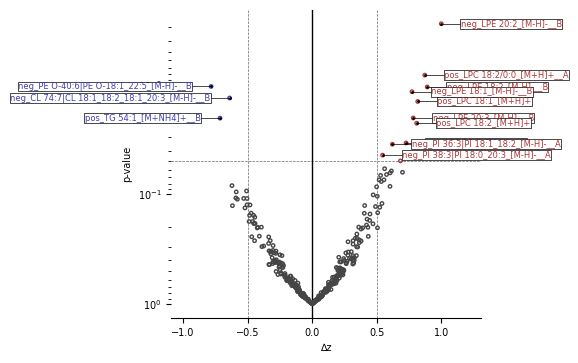

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 18:2_[M-H]-__A""",1.420281,-0.267702,1.31816,-1.439427,1.503057,0.893269,-1.371378,-1.05602,0.693017,-0.822763,-0.75133,-0.558537,-0.3708,-0.530223,-0.033731,0.024713,-0.842727,-0.168322,1.49849,-0.665057,0.593332,null,-1.163259,-0.777834,0.041376,-1.147001,-1.22368,null,null,null,-0.748973,null,null,null,null,null,…,null,null,null,null,null,-0.005437,null,null,null,null,2.770082,1.337629,0.413868,1.319843,-0.468878,-1.078606,0.807444,null,-0.899368,1.457716,null,0.815022,null,1.047507,null,null,null,null,null,null,null,-0.416334,0.281846,null,null,0.726832,0.03408
"""neg_LPE 18:2_[M-H]-__B""",1.451696,-0.093356,1.532802,-1.307174,1.476267,0.845817,-1.068176,-0.818556,0.387551,-0.896021,-0.718418,-0.683664,-0.510652,-0.54604,-0.043065,-0.398974,-0.934531,-0.104751,1.238145,-1.224199,0.263104,null,-1.488956,-1.004609,-0.834018,-1.142905,-1.437993,null,null,null,-0.678668,null,null,null,null,null,…,null,null,null,null,null,0.450061,null,null,null,null,3.189458,1.658883,0.821236,1.030009,-0.021825,-0.802961,1.161555,null,-1.22932,0.821883,null,0.734388,null,0.338251,null,null,null,null,null,null,null,0.303381,0.590724,null,null,0.890602,0.010502
"""neg_LPE 20:3_[M-H]-__B""",0.535003,-0.54031,0.460307,-2.528882,0.441635,-0.30605,0.076249,-1.456609,-0.22306,-1.564305,-0.222994,-1.073928,0.130539,0.581543,1.485188,0.906228,-0.817906,-0.661831,0.224113,-0.561268,1.489278,null,-0.121803,-0.66274,-2.204033,-0.800759,-0.189871,null,null,null,0.978988,null,null,null,null,null,…,null,null,null,null,null,1.304415,null,null,null,null,1.529705,1.520708,0.039473,1.224676,-0.358408,-1.129362,2.123972,null,-0.979933,-0.106383,null,0.873891,null,0.281034,null,null,null,null,null,null,null,0.083896,1.538778,null,null,0.782374,0.020155
"""neg_LPE 16:0_[M-H]-__B""",-0.27803,1.142755,-0.22279,-0.404531,0.275011,-0.183081,0.81559,-0.853468,-1.335883,-0.132942,1.153002,0.580541,-0.713498,0.853573,0.181232,0.108274,-1.291171,0.346735,0.020609,-0.722097,-0.680759,null,-0.800493,0.754859,-1.698401,-0.98654,-0.758438,null,null,null,0.562128,null,null,null,null,null,…,null,null,null,null,null,0.968853,null,null,null,null,1.540079,-1.282407,1.069471,1.055043,1.837773,0.783628,1.781368,null,-1.353477,-1.210194,null,0.874045,null,0.186048,null,null,null,null,null,null,null,0.492432,0.198261,null,null,0.683373,0.049649
"""neg_LPE 18:1_[M-H]-__B""",2.880928,-0.439585,1.184506,-0.210627,0.911174,1.565951,-0.341859,-0.159541,0.202349,0.036194,0.323992,-0.937784,-1.43826,-0.301051,-0.721833,-0.483348,-1.801915,-0.102082,1.479712,-0.732793,-0.555491,null,-0.739236,-0.670063,-1.629177,-0.740656,-1.872711,null,null,null,-0.251089,null,null,null,null,null,…,null,null,null,null,null,0.183557,null,null,null,null,2.112679,1.169169,0.546321,0.040935,0.669203,0.046158,0.624879,null,-0.753176,0.965681,null,2.376011,null,-0.322928,null,null,null,null,null,null,null,0.310885,-0.124352,null,null,0.772386,0.011606
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PE O-40:6|PE O-18:1_22:5_[…",-0.948679,1.436089,-1.049479,0.14685,-0.423854,-2.017245,-0.046435,0.35105,0.844115,0.666148,0.647178,0.927342,0.016328,0.28925,0.3462,-0.155283,0.625206,0.936393,-1.368786,0.257942,0.709756,null,0.35724,1.989206,2.399788,0.475857,1.130296,null,null,null,0.939392,null,null,null,null,null,…,null,null,null,null,null,-1.197377,null,null,null,null,-1.070471,-0.507971,0.553113,-0.106589,-0.768412,0.010873,-1.29074,null,0.57207,0.890814,null,-2.299983,null,-1.089201,null,null,null,null,null,null,null,-0.980003,-0.672053,null,null,-0.783306,0.010397
"""neg_CL 74:7|CL 18:1_18:2_18:1_…",-0.305415,2.536713,0.254675,2.645134,-0.340074,0.384398,-1.932589,2.328883,-0.219747,-0.500811,0.294118,0.211649,-0.713569,-0.211987,-0.309021,0.277788,-0.065129,0.773617,1.04352,-0.15258,0.182411,null,-1.143188,-0.755611,1.35266,-0.362784,0.114016,null,null,null,-0.202682,null,null,null,null,null,…,null,null,null,null,null,-0.150192,null,null,null,null,-0.429871,-0.594338,0.378158,0.540287,-1.237425,-0.163587,-1.195691,null,-0.022364,-0.529048,null,0.076531,null,-1.170315,null,null,null,null,null,null,null,-1.6259,-0.376341,null,null,-0.639971,0.013253
"""pos_TG 54:1_[M+NH4]+__B""",0.772429,-0.907214,1.155719,0.494507,-1.920487,-0.636043,-1.030208,1.550726,1.500657,1.44761,-0.730389,1.259104,0.37964,2.14423,0.999894,-0.945072,-0.245635,-1.249001,0.083887,0.802524,1.155838,null,0.420376,1.345426,-0.157103,-0.126332,-0.567106,null,null,null,1.121226,null,null,null,null,null,…,null,null,null,null,null,0.047244,null,null,null,null,-1.366203,-0.764445,1.30491,-0.611482,0.106119,-1.347758,-0.362497,null,-0.152691,0.297977,null,-1.403046,null,-2.222575,null,null,null,null,null,null,null,-0.772555,-0.011242,null,null,-0.714615,0.020234


Metabolomics


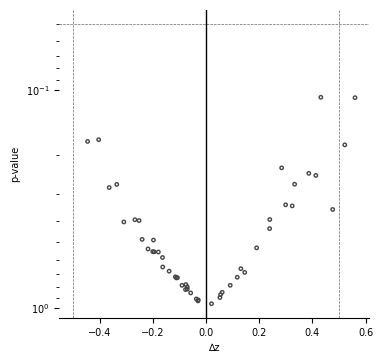

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITDxNPM1-WT ============
Transcriptomics


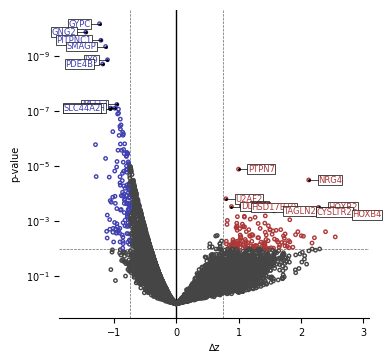

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""FUCA2""",null,0.185286,-0.812713,0.039826,-0.969541,null,-1.556096,-0.522812,null,-1.911576,null,-0.844719,-1.596656,-1.428914,-1.174746,-0.891918,-1.257217,1.493754,0.151864,0.780026,1.149079,-0.42759,-0.803393,-1.212044,null,0.172627,null,null,null,null,-0.058873,0.026859,-0.814359,0.276252,0.877986,null,…,0.49875,0.291086,0.903541,null,0.251697,-0.630644,null,0.955893,-1.4257,null,null,null,0.798888,1.254877,-0.983701,-0.103425,2.230187,0.712745,1.137062,null,2.077709,0.683967,-1.12541,-0.658861,null,null,-0.350122,0.931215,0.854169,null,1.502612,1.208943,0.762312,null,0.661533,0.909496,0.004687
"""C7orf24""",null,-1.710163,0.749899,1.214018,-0.439618,null,-0.403586,1.587374,null,-0.154072,null,-0.909025,-0.331967,-0.428755,-0.14787,0.834611,0.535829,0.089326,-0.621599,-0.203667,0.010705,-0.18912,-1.634718,-1.503395,null,2.642006,null,null,null,null,2.054873,1.071066,-0.633958,-0.364373,0.104803,null,…,0.184538,-1.096281,0.36666,null,-1.160456,-1.902431,null,0.18376,-0.855574,null,null,null,0.122255,-0.385462,-0.394513,0.437708,-0.869553,-0.313214,-1.023906,null,-0.311743,-1.138122,0.314348,-1.815586,null,null,0.381826,1.464079,1.251623,null,-0.085209,0.755435,1.603921,null,1.515289,1.124402,0.002401
"""LDAF1""",null,-0.658486,-1.169469,0.504861,-1.965145,null,-0.254361,2.411735,null,-0.212182,null,0.030632,0.269667,-0.197877,-0.247374,0.040112,-1.283453,-1.013252,1.649034,-0.802589,0.264638,0.710946,0.983242,-0.429937,null,-0.668241,null,null,null,null,-1.06876,-0.415787,0.361007,1.816973,-0.343413,null,…,-0.288427,-0.320871,-0.422603,null,0.498629,-1.150857,null,-0.635272,2.995378,null,null,null,-0.316198,-1.084103,1.174017,-0.598604,-0.409003,-0.405285,-0.014967,null,-1.059604,-0.636849,-0.91307,-1.391792,null,null,1.930539,1.544901,1.010396,null,-0.502613,0.508443,1.589795,null,0.871535,1.135183,0.009143
"""MAN2B2""",null,-0.425865,-0.251788,-0.056707,1.298069,null,-1.351029,0.778551,null,-0.82126,null,0.159405,-1.712957,-0.674722,-0.729108,-0.475262,-0.75103,-0.397983,-0.166286,-0.828927,-0.454439,-0.836878,-1.265651,1.477444,null,0.021609,null,null,null,null,-0.360999,-0.831473,-0.253504,0.727771,0.039184,null,…,0.134892,-0.257673,-0.598569,null,0.142969,-1.103743,null,-0.062292,1.566825,null,null,null,1.752051,1.231562,-1.4701,-1.48525,2.403471,2.816631,1.770045,null,-0.718055,0.156807,-0.537383,-0.664051,null,null,0.700423,0.910375,0.039725,null,0.582812,1.24808,0.39259,null,1.10941,0.813619,0.001317
"""TOMM34""",null,-1.704899,1.101837,-0.635518,3.381353,null,1.102727,0.87404,null,0.092455,null,-0.58092,0.949489,-0.543145,-0.533534,-0.039077,0.926666,-0.490834,0.490091,0.202977,-0.089228,0.539806,-1.110295,-0.323553,null,0.259984,null,null,null,null,0.469771,-0.089715,0.783392,-0.070171,-0.47294,null,…,0.174278,-0.69117,-0.167996,null,0.42551,0.681012,null,0.083774,-1.495824,null,null,null,-0.198779,-1.749611,0.150167,0.20767,-1.178545,-1.474866,-1.327289,null,-0.882284,-0.728859,0.457017,-2.0298,null,n

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""KDM7A""",null,2.085019,0.258349,0.984578,0.212906,null,-0.524113,-0.729313,null,-0.53856,null,-0.365412,-0.745521,0.513509,2.208634,-0.814991,0.067921,0.022747,-0.874323,-0.711291,-0.478253,1.523733,0.111427,-0.097284,null,-0.927586,null,null,null,null,-1.007126,-0.124583,-0.554299,-1.048962,0.154656,null,…,-0.188864,0.517843,-0.776275,null,1.604697,-0.941489,null,-0.317027,-0.216031,null,null,null,-0.364899,-0.246574,-0.114344,0.834325,1.854166,1.775972,0.241485,null,0.363039,1.927562,-0.916229,3.237233,null,null,-0.767507,-1.232947,-0.958557,null,0.349956,-0.894237,-1.387181,null,-1.016956,-0.964478,0.002692
"""ZNF200""",null,-0.902685,-0.778953,1.145721,3.295952,null,-0.398878,-0.138527,null,-0.126564,null,-0.195449,0.654759,1.002838,0.397078,-0.693692,2.605772,-0.717235,-0.289217,-0.219197,-0.582715,0.916775,-0.621102,3.188792,null,-0.207685,null,null,null,null,-0.991077,0.425478,0.13372,1.122707,-0.791013,null,…,-0.848943,-0.413447,-0.20278,null,2.004863,0.147723,null,-0.54666,-0.991984,null,null,null,-0.25163,-0.797669,1.120633,0.244697,-0.108559,0.17369,-0.453228,null,-0.99632,-0.917011,-0.360503,0.961543,null,null,-0.828185,-0.784653,-0.35738,null,-0.831393,-0.308344,-0.825699,null,-0.703641,-0.757436,0.000068
"""ELOVL5""",null,1.059222,-0.549701,1.400762,-1.16654,null,0.229399,0.486601,null,1.192544,null,-0.383586,3.677548,0.654342,-0.063435,-0.655491,3.348824,0.116596,0.845255,0.085229,-0.825615,-0.088911,-0.70216,-0.770528,null,0.783693,null,null,null,null,-1.247714,0.063486,0.363769,0.450655,-0.086127,null,…,-0.347515,0.0062,0.975153,null,-1.815215,0.037457,null,-0.610168,-0.241598,null,null,null,-1.090983,0.282435,-0.859606,-0.100953,-1.002407,-0.066194,-0.58671,null,-0.280567,-0.211006,1.925702,0.013325,null,null,-0.99425,-0.852619,-0.412418,null,-0.066953,-1.025663,-1.1931,null,-0.8827,-0.886156,0.000377
"""HGF""",null,-0.776759,0.232989,-0.070532,-0.592506,null,-0.413975,0.357795,null,0.344806,null,-0.349275,-0.816407,-0.647012,-0.699218,0.022919,-0.343147,-0.255849,0.298701,0.016935,-0.233687,0.107269,-0.772169,-0.848121,null,-0.212199,null,null,null,null,4.319336,0.800823,-0.50117,0.565893,0.196897,null,…,-0.012067,-0.756827,1.605266,null,-0.732634,-0.839624,null,-0.341331,-0.763584,null,null,null,-0.091021,2.525269,-0.487976,1.838385,0.507891,-0.845785,0.295345,null,-0.441914,-0.85114,0.52923,2.657745,null,null,-0.60869,-0.826757,-0.748143,null,-0.711284,-0.735799,-0.543685,null,-0.520371,-0.766486,0.000008
"""TBPL1""",null,-0.879322,-0.760397,0.306358,1.660741,null,-0.326866,-0.850528,null,2.467516,null,-0.119688,2.12921,0.171574,1.373617,-0.256417,0.9777,0.365325,-1.102043,1.658475,0.873664,0.72703,-1.117106,-0.797561,null,-0.548719,null,null,null,null,-0.368882,1.977231,0.875803,0.05204,0.298632,null,…,0.383841,-0.410295,1.114762,null,0.318645,-0.111405,null,-1.011252,0.663405,null,null,null,-1.30899,-0.870095,1.168281,1.081042,-1.131133,-0.254881,-1.405145,null,-0.146572,-1.251136,-0.306641,-

Proteomics


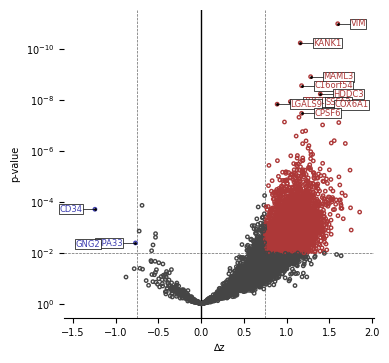

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS""",-1.542259,-1.395823,-0.447862,-0.980851,null,null,null,null,null,null,-1.947741,-1.136345,-1.120729,-0.939463,-1.616692,-1.874056,-0.217609,-0.456842,-1.511112,-0.832212,-0.748149,-0.401336,0.450722,-0.796796,-0.682444,0.138926,-0.347163,0.467166,-0.936152,0.857692,2.113329,0.791053,-0.308266,1.023863,0.542062,0.3426,…,0.970821,-0.031399,1.46986,1.405213,0.285131,-0.128239,0.343336,-0.42078,-1.988544,-0.236326,-1.397439,-0.034244,1.58668,0.135788,-0.206442,1.022811,1.102638,-0.013074,0.928004,0.054984,0.159476,0.366877,0.970719,-1.267366,2.645251,-0.18844,-0.013034,null,0.70166,1.336155,0.708376,1.706465,1.578477,0.316274,-0.136293,0.870115,0.009994
"""AACS""",0.016082,0.891129,0.014929,0.230692,null,null,null,null,null,null,-2.154921,-2.036157,0.586052,0.044943,-1.254978,-1.919572,-0.983412,-0.481312,-1.884537,-0.58567,-1.136294,0.515246,-0.747527,0.509453,0.612145,0.656307,-0.171533,-0.217533,-0.81261,0.097776,-0.319522,-0.960065,-1.13896,-2.883177,0.162554,-0.091256,…,0.790871,0.368588,-1.067844,1.252179,-0.501623,-0.753393,-0.789782,-0.314534,-0.266404,1.436187,1.556085,0.029323,0.206673,1.82686,-0.603951,-0.186946,1.051341,0.529674,0.916148,1.730691,-0.131115,0.849734,-0.400351,-0.354508,1.41537,-2.019163,1.083997,null,0.887867,-0.319743,1.710934,2.057709,1.274579,0.507716,0.761482,1.118099,0.002742
"""AAGAB""",-0.618605,1.092347,0.103645,0.071595,null,null,null,null,null,null,-2.510515,-2.470933,-0.670336,-0.968585,-0.292929,-0.822523,-1.921802,-1.082432,-1.353139,-0.438344,-0.97086,-0.404948,0.233059,0.080315,-0.240851,0.042966,-0.103969,-0.46013,-0.664431,0.246239,-0.266921,0.975007,-0.644519,-1.278079,0.085209,0.16072,…,1.392536,0.040528,-0.830976,0.87779,-0.380387,-1.154639,-1.146293,-0.645516,-0.191312,1.884401,0.652709,0.748392,-0.131609,1.855103,-0.217422,-1.114269,1.671624,-0.052839,-0.266978,2.161232,-0.276165,0.936151,-0.834007,0.013851,1.742052,-1.213686,0.33313,null,1.381746,0.373073,1.750704,2.40928,0.452147,0.892648,0.916453,1.194558,0.001875
"""AAK1""",-0.207097,1.02427,0.009679,-0.033026,null,null,null,null,null,null,-1.689299,-2.03898,-2.07001,-0.8117,-0.413482,-2.366944,-1.3957,-1.303839,-1.260513,-0.104213,-0.959681,-0.405905,-0.786658,1.283918,0.075197,-1.203633,0.144542,-0.16955,-0.742618,0.58737,-0.363489,-0.120275,-0.885915,-0.648691,-0.160846,0.122917,…,1.473592,0.481692,-1.030489,-0.087672,0.111969,-0.151138,-0.596446,-0.380569,-1.146551,1.230414,0.089163,0.396183,1.171746,1.470221,0.621141,-0.204764,2.463535,0.590068,0.554144,2.023098,0.569228,0.775063,1.620893,-1.274666,-0.375303,-1.276747,0.101477,null,0.850621,0.237815,1.66316,1.993524,0.70526,1.411545,0.694378,1.075034,0.001991
"""AAMDC""",-0.206425,-0.716536,0.783744,-0.058159,null,null,null,null,null,null,-1.037646,-1.939039,-1.345919,-0.033993,-1.129138,-1.613604,-1.352352,-0.391569,-1.6348,0.33674,-1.712471,-0.055434,-0.386299,0.672554,0.572812,0.658969,-1.539663,-0.659174,-0.148407,-0.30471,0.390307,0.0286,-0.746569,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD34""",-1.33872,-0.980798,1.080388,-0.131088,null,null,null,null,null,null,-0.660135,0.297102,-0.850579,0.941584,-1.443437,-1.528937,0.518846,-0.072907,-0.629734,-0.02597,-0.018339,-0.166496,1.03868,-2.054367,-0.424055,0.094191,0.973697,0.987715,-0.44802,1.132376,1.150005,0.767481,1.480259,-0.149164,1.650466,0.193302,…,1.083628,-0.913241,0.151168,-0.447166,0.862103,1.416539,1.066651,0.618699,0.106913,-1.849179,1.148626,-0.642678,0.794784,-0.990593,-0.608879,1.740851,-0.905314,-1.568392,0.253007,-0.313234,-0.459378,-0.165622,0.65807,-1.681517,1.681857,0.484016,-0.958597,null,-0.065967,-0.864971,-1.499578,-1.121057,-0.881617,-1.388331,-2.070577,-1.242501,0.000196
"""GNG2""",0.987054,0.731423,0.962429,0.230861,null,null,null,null,null,null,-1.26674,-0.837316,-1.340219,-0.911182,-0.157821,-2.104162,0.495725,0.649158,-1.493337,-0.497443,-1.598348,0.591744,-0.769626,-1.477014,0.893331,-1.204894,0.776134,1.547091,-1.217185,0.759204,0.437073,0.033086,-0.554446,-1.212915,2.003723,1.577556,…,1.989337,0.841976,0.757222,0.96487,-0.225208,-0.222017,-0.678326,-0.352984,-0.430455,0.232757,-0.711076,-0.808853,1.559267,0.981739,-0.840346,0.792722,0.453524,0.210594,0.03007,0.886084,1.180263,0.35999,1.496161,-1.291466,-1.043752,0.828842,-0.339391,null,-0.071136,-1.567922,-0.636551,-1.27725,-2.276018,-0.542974,-0.628692,-1.030414,0.004545
"""GPA33""",0.281515,-0.556526,0.783872,-0.108813,null,null,null,null,null,null,-1.263055,-1.002622,1.286596,0.390773,0.240369,-1.34405,0.355541,-0.008036,-0.901885,0.68619,0.430101,-0.143771,-0.802969,0.150439,0.964203,0.065272,0.985084,1.020368,-1.472047,1.271817,0.156676,1.08182,-0.650867,-0.577541,0.780508,0.728762,…,-0.088484,0.644107,2.340322,-1.108188,1.469293,0.805168,1.494614,0.170557,-2.003808,-0.485881,-1.817537,-0.788839,1.039603,0.345817,0.345893,0.668575,-0.25265,-0.865987,0.154762,-0.947338,-0.612628,-1.11764,1.818458,-2.147858,-0.254639,0.912806,-0.201842,null,-0.925906,0.170046,-1.198953,-0.197268,-0.942481,-0.940218,-1.236946,-0.768405,0.004106


Phosphoproteomics


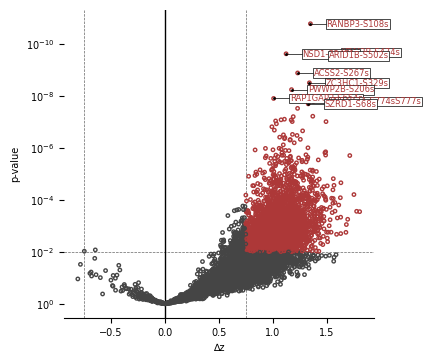

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S20s""",-0.232702,0.797706,-0.735363,null,null,null,null,null,null,null,-1.530117,null,-2.493254,-0.6046,-0.76177,-1.265441,-1.106084,null,-0.510382,-0.590834,-1.100266,-1.147387,-0.583367,null,-0.292071,-0.106818,-1.024001,null,-0.417458,null,-0.313824,0.018426,null,null,null,null,…,0.892703,0.053347,null,0.235535,null,-0.651687,0.01545,null,-0.730482,1.019936,-0.220521,null,1.661606,null,1.047111,-0.54162,null,0.404963,1.057119,2.168077,0.231329,null,2.085892,-0.893581,null,-1.332266,0.479436,null,0.354492,null,1.92029,1.802266,0.59829,1.556108,1.191039,1.308435,0.000891
"""AAK1-S670sT674tS678s""",null,null,0.455455,null,null,null,null,null,null,null,-1.329943,-0.843083,null,0.45729,-0.454744,-1.302413,-1.110538,-0.810255,-0.249454,-0.338462,-0.847554,0.090271,-0.573825,0.550462,-2.846388,-0.93214,0.023267,-0.734712,-0.796241,0.452822,0.01258,0.052558,-0.850748,0.82642,0.761471,0.012194,…,0.972581,1.518777,-0.788581,-0.460917,-0.195487,-1.237785,-0.243975,-0.648986,-1.214978,0.999944,-0.095225,0.374329,1.433229,1.511664,1.262773,-0.237777,2.402747,0.875055,0.016575,1.413604,0.866005,-0.55373,1.60941,-1.704015,-2.134276,-0.983334,null,null,0.789232,0.80306,1.606202,1.584997,0.50505,0.892894,0.858839,1.121168,0.000056
"""AAK1-T606t""",-0.322396,0.10375,0.797769,0.103229,null,null,null,null,null,null,-1.806668,-1.441886,-2.269473,-0.775226,-0.606671,-1.972968,-1.451819,-0.869878,-0.559534,0.112661,-0.834578,-0.410351,-0.803694,1.262689,-0.663979,-1.717362,0.311043,-1.273521,-1.136501,0.306615,-0.183597,-0.34626,-1.348001,0.265863,0.722519,0.430393,…,1.346173,0.259503,-0.860097,0.07884,-0.073961,-0.500951,-0.410384,0.003157,-0.442278,0.693932,-0.456918,0.879153,1.262155,1.7895,1.254882,-0.215905,2.262415,1.042247,0.375981,2.247974,0.817115,0.935572,1.692447,-1.248356,-0.904164,-0.90432,0.234047,null,0.315854,0.345743,1.355507,1.921856,0.894243,1.619147,0.325176,0.984317,0.003636
"""AAK1-T620tS624s""",-2.395924,0.42425,0.647879,0.218306,null,null,null,null,null,null,-1.574906,-1.36241,-2.258463,-0.413229,-0.487655,-2.322964,0.492773,-0.709911,-0.134459,-0.262526,-1.048038,0.012668,-0.633445,0.669615,-0.978641,-1.045371,0.033262,-0.849793,-1.082221,0.19884,-0.131475,0.111885,-1.425769,0.031455,0.5668,0.504861,…,1.303581,0.546097,-0.582118,0.329194,-0.147537,-0.647646,-0.049956,-0.204543,-0.801346,1.083412,-0.355012,1.146894,1.65399,1.467295,0.779671,0.190812,1.973767,0.621884,0.378532,2.257744,0.573753,0.849716,1.402597,-1.394672,-1.117278,-1.023326,-0.188633,null,0.875268,0.578818,1.624735,2.064824,0.751864,1.263896,0.400437,1.034804,0.003799
"""AAK1-T674tS678s""",-0.458286,-0.195471,0.610625,-0.117859,null,null,null,null,null,null,-1.530335,-0.658471,null,0.234339,-0.132423,-2.121357,-1.368472,-0.890955,0.161861,-0.187648,-0.749091,-0.08093,-0.687459,0.84429,-1.800279,-1.154295,-0.043728,-1.187935,-0.627721,1.325322,0.025383,-0.102012,-0.901031,1.102721,0.449038,0.245429,…,0.724955,0.596065,-1.246509,-0.963103,0

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Acetylomics


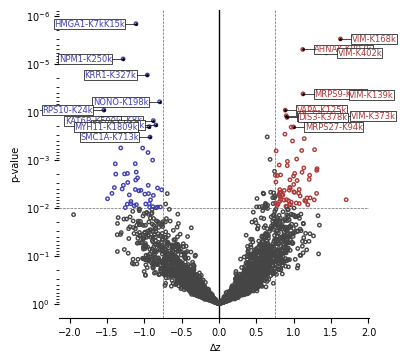

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AFF1-K582k""",null,null,1.842701,null,null,null,null,null,null,null,-1.175368,-0.578397,null,-0.236507,0.599381,-0.176421,-1.123961,0.616067,-0.364474,0.139944,-0.742432,-0.226212,-0.375425,0.693282,-1.565584,-0.836613,0.563237,-0.213964,-0.343409,0.079463,0.43593,-0.073567,0.501113,0.054133,1.326539,-2.033499,…,1.34959,0.896637,-0.662967,-0.418508,0.07151,-1.550072,0.996962,0.192941,0.101405,0.252899,0.580442,0.955363,0.870307,0.694989,0.723681,0.792809,0.949135,0.448535,0.336227,-1.332614,0.215201,0.024129,1.086176,-0.819635,-2.924818,null,null,null,0.209152,0.437668,1.233552,1.744433,0.384053,1.206317,1.130043,1.012213,0.001928
"""AHNAK-K1191k""",null,null,-0.409537,null,null,null,null,null,null,null,-0.592183,-0.639776,null,-1.295853,-0.31846,-1.387377,null,0.555547,-0.680948,-1.690519,0.163981,0.15759,0.617604,-0.809699,-1.926661,-1.066366,0.127992,-0.76505,-0.507607,1.055319,-0.24687,-1.383066,-1.028338,-0.975132,0.300195,-0.155278,…,0.385321,1.215696,-0.668325,1.606989,1.03937,-0.884531,-1.565864,0.139531,0.302018,1.460872,-0.003613,-0.289214,1.931619,1.619072,0.208486,-0.130458,1.139304,1.092819,0.110837,1.615991,0.411436,0.826509,0.090287,null,-1.708284,null,null,null,1.327493,0.166164,1.414802,1.353841,0.447004,1.43492,0.976478,1.140014,0.000363
"""AHNAK-K1918k""",null,null,null,null,null,null,null,null,null,null,null,0.116698,null,-1.077334,-0.629778,null,-0.960479,0.397342,null,-2.7875,-0.282341,null,0.80186,-1.573226,null,null,null,-1.215966,null,1.541509,0.362796,null,-0.913062,-0.617904,0.431838,-0.516472,…,null,-0.68269,-1.459443,null,0.362071,0.005361,null,0.371305,null,1.074159,null,-0.419893,null,1.039593,null,null,0.8693,1.401553,null,1.155102,null,-0.181257,0.009081,null,-1.682145,null,null,null,0.794499,0.731038,1.471463,null,0.185265,1.200594,null,1.009385,0.004761
"""AHNAK-K807k""",null,null,-1.751149,null,null,null,null,null,null,null,null,null,null,0.008424,-0.412703,-0.837621,null,0.073031,null,-0.716726,-0.811798,null,-0.430997,-0.804611,-1.542543,null,null,-0.50653,null,null,-1.245212,null,null,-1.219413,0.102464,null,…,0.226334,1.150678,-0.880686,1.169924,null,-1.284869,-0.682797,0.061237,null,1.524512,null,0.84338,0.986118,null,-0.307228,null,null,1.675753,-0.337583,1.779743,null,null,0.885455,-0.485065,-0.463861,null,null,null,1.250547,null,0.940287,0.809248,0.95447,1.251557,0.533258,1.120543,0.000005
"""AK2-K117k""",null,null,null,null,null,null,null,null,null,null,-0.008585,-1.591884,null,-0.199731,-0.502757,1.142713,-1.222617,-0.85071,-0.133281,-0.182676,null,0.352736,0.100909,0.638634,-0.166255,null,-1.907048,-0.183925,-0.04387,1.831751,-1.509467,-1.845057,0.611476,0.466322,-1.307914,-1.374329,…,-1.729501,-2.255212,0.080462,1.726934,-0.297407,0.531581,0.251702,0.378032,0.226147,1.690658,-0.529042,0.263327,0.382444,0.402075,-0.041529,0.519221,-0.03034,1.838554,-0.37134,1.044589,0.578604,-1.490641,-0.357511,-0.102454,-1.125087,null,null,null,0.528293,0.345335,0.732078,0.306848,1.60

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A2M-K1176k""",null,null,-1.021367,null,null,null,null,null,null,null,-0.022805,0.740725,null,null,1.036347,-0.016397,null,null,null,null,-0.169428,null,0.399796,null,null,1.676335,1.254875,null,-1.307356,1.226833,-0.307434,null,null,null,null,null,…,null,-0.954165,null,0.305864,-0.622492,1.143473,null,null,0.522644,-0.12323,null,null,-0.181653,-0.924142,null,2.032756,-0.083596,-0.017049,null,1.323734,0.508461,2.050839,-1.138338,null,null,null,null,null,-0.080826,-0.826109,-1.676824,-1.075612,-1.279265,-0.192983,-2.255521,-1.279158,0.003395
"""ALOX5-K40k""",null,null,null,null,null,null,null,null,null,null,null,0.485379,null,-0.217117,null,0.085023,-0.984442,null,null,null,1.996371,0.067829,-0.856409,null,null,0.889368,null,null,null,0.761981,-0.585636,-1.638066,-0.133479,null,null,1.523337,…,-0.021924,-1.034732,null,null,-1.75939,0.99175,0.272922,null,null,1.62363,null,null,null,-0.172096,-0.367988,null,0.311762,null,0.076886,0.433671,null,1.330575,-1.176438,1.222496,null,null,null,null,-2.117554,-0.393169,-0.879937,null,-0.73076,-1.18658,null,-1.227475,0.008412
"""ANXA6-K442k""",null,null,-1.298938,null,null,null,null,null,null,null,-1.584894,0.929181,2.235474,1.131694,1.028694,-0.024441,-1.134847,0.708309,-1.112366,-0.157849,1.096048,0.606614,0.237907,-0.702506,0.871185,1.589277,1.632743,-0.144752,-0.485847,0.586267,-1.696116,-1.224692,-0.943512,-0.28425,1.641895,-0.879413,…,0.625287,1.478279,-1.505648,-1.080525,0.236875,0.809339,-0.508429,0.759086,0.190768,0.619826,-0.395172,1.211631,0.205681,0.094194,-0.87248,3.336362,0.41545,-0.551275,0.100087,-0.255121,0.665106,0.835428,-0.576879,-0.453372,-0.497468,null,null,null,-0.885815,-0.402202,0.02065,-1.023376,-2.074932,-0.924139,-1.27273,-1.045089,0.00433
"""ANXA6-K620k""",null,null,-0.213779,null,null,null,null,null,null,null,0.213125,1.042752,0.856447,1.087893,1.544895,0.821191,-0.609595,1.023124,-1.496793,-1.538831,1.334323,1.241489,-0.198436,-0.090239,1.801933,0.824332,1.03014,0.531822,-0.159533,0.620799,-1.471876,-1.862128,-1.165722,-0.466844,1.576453,-0.37497,…,1.052345,1.34007,-1.041011,-2.108701,-0.318516,0.630415,-1.142617,0.745952,0.460038,1.19708,0.424278,0.314363,0.698836,0.535972,-1.254095,0.698033,0.997996,-0.878903,0.210452,-0.467836,0.338873,0.350185,-0.785431,0.024009,-0.949093,null,null,null,-1.06954,-1.449928,0.081453,-1.472545,-1.918156,-0.503015,-1.359862,-1.224891,0.001926
"""AP2A1-K177k""",null,null,null,null,null,null,null,null,null,null,1.335108,0.359865,0.71219,null,null,null,null,-0.115959,-1.348868,null,null,-0.446412,null,-1.012228,1.878349,null,0.435969,0.375155,1.540512,-1.035857,-0.697402,0.208983,0.768422,-0.644677,0.604251,0.386211,…,0.159041,null,-2.286094,-1.411601,-1.30261,null,null,1.064639,1.163291,null,0.033834,0.927404,-0.453904,-0.309354,-0.141708,-0.233518,0.284242,null,0.76879,2.304087,0.72722,0.818191,null,-1.376464,-1.061249,null,null,null,-1.703348,-0.948914,null,-0.191545,null,-0.821271,-1.623605,-1.180729,0.008225
…,…,

Lipidomics


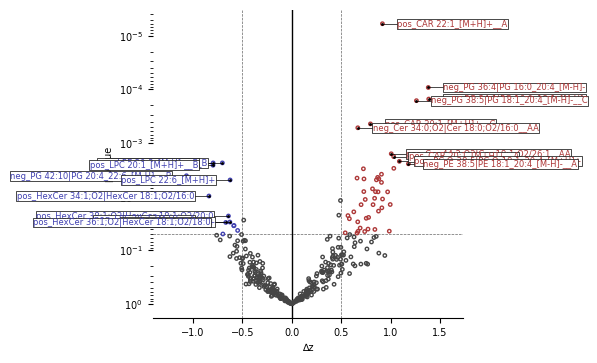

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPG 18:0_[M-H]-__A""",0.207264,null,0.009843,null,null,null,null,-0.671926,-3.084814,-0.626124,-0.559052,0.127463,-3.918838,-1.251469,-1.313047,-0.178312,0.155247,-1.49335,-0.233815,-0.010606,0.309195,0.5105,-1.01285,0.126134,0.710277,0.544393,-0.581155,0.952186,-0.098639,0.929812,-1.055715,0.071139,1.383071,-0.990469,-0.091,-0.411431,…,1.470782,1.138978,-1.184113,-1.284489,-0.472194,-2.200263,0.5147,0.417679,0.384227,0.776708,1.260723,0.070628,0.839909,-0.420967,-0.790856,0.214582,0.89625,1.470955,0.873993,1.494056,0.105975,-0.227746,-0.512046,0.613668,-1.011364,null,null,0.094922,0.001746,1.314456,0.437056,1.028189,0.446243,0.831853,0.549278,0.660333,0.004533
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.304298,null,0.205666,null,-1.877715,-2.336927,-0.671176,-0.559277,-0.89684,0.730015,-1.528752,0.924474,-0.121785,2.107107,0.158423,-1.873054,-0.017167,0.410613,-0.225106,0.735596,-1.569228,-0.574981,-0.465229,-0.156281,-1.043631,-0.057784,-0.333594,0.473044,-0.109398,0.364759,0.730195,0.993495,-1.085776,0.540492,0.794747,-1.860314,…,0.975552,-0.021828,0.976691,0.444138,0.547362,-0.154064,1.175937,0.78952,-1.591981,-0.033355,-0.954576,-0.48851,0.489138,-1.474352,0.631859,0.883681,0.418319,0.686194,0.095807,-0.267403,-0.912236,-0.795319,0.313918,-0.62282,0.909535,null,null,1.017552,1.520874,1.923878,0.151462,1.420306,1.782571,1.387895,0.680967,1.381063,0.000093
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.215346,null,0.795471,null,-2.441927,-1.966074,-0.915823,-0.483266,-0.888357,0.279216,-0.10746,0.794978,-0.830775,1.136461,-0.391025,-1.149383,-0.903751,-0.814991,-0.488269,-0.294001,-1.121868,-1.291125,0.036713,-0.093762,1.331255,0.399075,-0.539235,-0.968015,-0.854319,-0.551013,0.797477,0.237136,-0.41343,-0.34982,0.006833,0.022341,…,0.64636,0.769201,0.748982,-0.021423,1.039508,0.074314,0.546116,-0.632635,-1.389862,-0.30681,1.144033,-1.361237,0.865305,-1.094948,2.380518,0.463456,0.148231,0.258864,0.203508,-1.024416,-0.035257,-1.473879,0.433882,-0.004088,2.162146,null,null,0.321056,0.892991,0.797209,2.014038,1.861902,1.040461,0.748887,1.351352,1.26125,0.000163
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.835229,null,0.259231,null,-2.285279,-2.742033,-0.876752,0.193112,-0.667221,-0.100126,-0.716662,-0.466087,0.30455,1.103579,0.954836,0.534101,0.888643,-0.784361,1.079024,0.250012,0.140463,-0.019744,0.180968,1.492705,-0.734978,0.077395,-0.921876,-0.774893,-1.056783,-0.584441,0.71958,1.058284,-0.537509,-0.467674,-0.743222,-0.742827,…,-0.284966,0.759907,0.835589,-0.930589,0.429675,-0.215208,1.95968,0.527086,-1.328964,0.21815,-1.636504,-0.397901,-0.236251,-1.357112,0.191948,-0.150869,0.561372,2.098452,-0.32932,-0.325366,-0.183514,-0.074807,0.860002,0.117964,2.601947,null,null,1.316481,-0.178241,1.869377,1.441341,0.763475,0.719842,0.969252,-0.32875,0.918256,0.011128
"""neg_PI 37:4|PI 17:0_20:4_[M-H]…",-0.030635,null,0.941094,null,-2.497806,-2.970579,0.055936,0.03974,-0.594966,1.095485,-0.881239,-0.572112,-1.539933,0.417872,0.703239,0.104

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 22:6_[M-H]-__B""",0.849367,null,0.031787,null,1.708379,2.899714,1.185776,0.897843,1.486716,0.566569,0.142487,0.606828,-0.168329,0.657245,0.539455,2.111066,-0.193652,0.119072,-0.012136,0.227433,1.745584,1.547921,0.195106,0.396514,0.288138,1.652541,-0.467357,0.183066,-0.370741,0.979318,1.354223,-1.098798,-0.142795,-0.859321,-0.577494,0.133305,…,-0.344348,-0.91685,-0.167379,-1.907159,-1.339492,-0.523074,-1.592387,-0.837193,-0.280005,-0.215144,-0.069901,-1.017903,-0.713653,-0.659353,-1.336236,-1.281093,-0.577475,-1.933429,0.906945,-0.512646,0.474645,-0.965213,-0.033517,-0.798691,-0.832855,null,null,0.047762,-0.857765,-0.761787,-0.026857,-0.539149,-1.234506,-0.848415,-0.806571,-0.702342,0.002361
"""neg_LPE 20:4_[M-H]-__C""",-0.486943,null,-0.550064,null,0.850925,2.97328,0.633296,1.316761,1.057219,0.448861,-0.372532,0.900762,0.408161,1.206719,0.597235,2.344475,0.192454,-0.1446,0.537863,0.502638,1.805623,1.714076,0.388701,0.801507,-0.032222,1.801542,-0.151948,0.088034,-0.170661,0.670652,1.211284,-0.201296,-0.016441,-0.524137,-0.719961,-0.443606,…,0.116344,-1.127747,-0.011003,-0.596675,-1.265776,-0.511359,-0.904149,-1.02334,-0.689428,-0.730094,0.076844,-1.269168,-0.685736,-1.204941,-1.018033,-0.944807,-0.438171,-1.732455,0.731644,-0.560886,0.052475,-0.909417,-0.619417,-1.092435,-1.365755,null,null,0.67325,-0.873128,-0.797531,0.009647,-0.897497,-0.92119,-0.905023,-0.209733,-0.547815,0.042911
"""neg_LPE 20:3_[M-H]-__A""",1.205097,null,-0.2184,null,0.617152,1.246762,0.055522,1.581159,1.324491,0.569077,0.146862,0.76101,0.788886,0.71653,0.367447,2.237402,0.409421,0.265589,0.379175,0.732943,2.085296,2.099378,-0.041772,0.945805,0.521256,0.697178,-0.04214,0.825283,-0.044636,1.259571,0.823761,0.869629,-0.271897,-0.913501,-0.200461,0.989606,…,-0.065284,-1.106745,0.824392,-0.527032,-2.051485,-0.287089,-0.138439,-1.849282,-1.122963,-1.654828,-0.371178,-0.829711,-0.876634,-1.207626,-0.520825,-0.704616,-1.009419,-1.390606,-0.269678,-1.296364,0.06553,-1.827329,0.133678,0.004088,-1.482949,null,null,0.673051,-1.769745,-1.472172,0.139295,-1.013001,-0.764734,-1.295248,-0.441094,-0.830362,0.026877
"""neg_LPE 20:3_[M-H]-__B""",0.597151,null,-0.313505,null,1.602151,2.736388,0.908907,1.118107,1.363475,-0.057893,-0.182132,0.230342,0.90974,0.774876,-0.033594,2.286808,-0.195486,-0.159195,0.162951,0.23873,1.577189,1.565417,-0.130087,0.611049,0.681549,1.562332,-0.461451,0.414928,-0.418844,0.588027,0.197098,1.075647,-0.240234,-1.11893,-0.319892,0.42561,…,-0.403647,-1.322666,0.069516,-0.442533,-1.215641,-0.119509,-0.492087,-1.014909,-0.134439,-1.320452,-0.001982,-0.939821,-0.770132,-1.143195,-0.778107,-0.940616,-0.94276,-1.748157,0.165092,-0.606503,-0.057239,0.064995,0.225836,-0.806671,-1.141994,null,null,0.201773,-0.817486,-1.27183,-0.30403,-1.125837,-0.711576,-1.200804,-0.465928,-0.795725,0.002363
"""neg_LPE 18:1_[M-H]-__A""",1.502238,null,-1.43667,null,0.968894,2.100821,0.555655,2.330463,0.930707,-0.338651,0.698958,1.886084,1.345159,-0.81667

Metabolomics


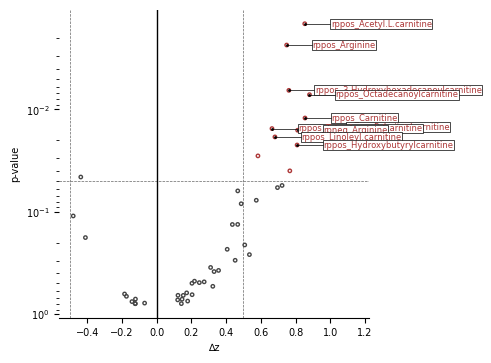

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.627262,null,-1.728641,null,-1.173779,-0.84158,-1.000139,-0.923439,-2.181236,-0.919689,-0.579179,0.082419,-1.473882,-0.512808,-2.129273,-1.217991,-1.588233,-1.032691,-1.963764,-0.376579,-0.819717,-1.310512,-0.515021,-0.38647,1.454946,-0.264087,-0.882361,-0.891168,-0.470562,1.005753,0.522939,-0.229449,-0.464548,-1.375386,0.093458,-0.459609,…,0.367394,1.405613,0.100269,-0.274047,0.472574,1.113026,-0.421497,0.434716,0.135653,0.037356,0.708997,0.040625,0.606192,2.465368,0.483378,-0.694471,0.865921,1.481337,1.168988,1.92229,1.10073,1.513613,-0.335591,2.359188,0.44346,null,null,0.100071,0.421228,0.28873,0.087038,1.291219,1.484238,1.238767,0.540662,0.76167,0.006525
"""rppos_Acetyl.L.carnitine""",1.665457,null,-1.215304,null,-2.789439,-0.690226,-1.338227,1.303796,-0.707346,0.230492,0.436804,0.456092,-0.43065,-0.293198,-1.367427,-0.22048,-1.620034,0.135837,0.378186,0.483009,0.070968,-2.194102,1.23043,-0.122903,1.815929,-1.668681,-0.674515,-0.464662,0.683773,-0.090329,-0.133137,0.100574,-2.635757,-0.690593,1.554094,-1.87758,…,0.485596,0.045952,-1.004947,0.392409,0.780311,0.651253,1.300663,-0.609512,1.300113,0.450839,0.195933,0.57115,-0.186318,1.611606,0.48636,-1.22579,0.346405,-1.050748,-0.343177,0.473576,-1.067694,0.871053,0.275676,-1.548762,0.375803,null,null,0.132057,1.079936,1.188326,-0.034954,1.3909,1.049922,0.589209,0.712224,0.853271,0.001459
"""rppos_Arginine""",0.84406,null,-0.748368,null,-0.358998,-0.761296,-0.227874,-2.979938,0.662461,1.52451,0.028864,1.28337,-0.000367,0.019274,1.056697,1.078023,0.482683,-1.884898,1.570979,1.261979,0.557614,-0.071675,2.156052,0.220687,-0.566167,-0.085609,0.274503,0.057158,-1.20592,1.319299,0.47461,0.759909,-2.02005,0.972984,0.403817,-1.814312,…,1.248966,-1.016832,0.367677,-2.10274,-0.398923,1.737171,0.21304,-0.915441,-0.431769,-0.640186,-0.254855,-0.013253,0.074592,-0.328334,0.081285,-0.548406,0.44657,-0.356315,0.431033,0.462211,-1.169373,-0.607425,-0.182714,-0.57642,0.19517,null,null,0.709278,1.704419,0.352811,0.542514,0.904255,0.223661,0.32615,0.598016,0.748978,0.002356
"""rppos_Carnitine""",-0.629036,null,-0.075422,null,-3.177657,-0.860112,-1.458331,0.426135,-0.916754,-0.291709,-1.229098,0.47321,-0.054967,-0.423866,-1.620205,-0.409276,-1.653238,-0.20421,0.183168,-0.355954,-0.270061,-2.449391,1.108858,-1.028242,1.111794,-1.840371,-0.077061,-0.273083,0.527298,-0.326387,-0.247441,0.395245,-2.339368,-0.01544,1.067889,-1.884087,…,0.421091,0.453257,-0.621301,0.555392,0.427468,0.767449,0.822672,-0.0717,1.121326,1.064094,0.618091,0.59413,0.293402,1.97242,0.70535,-0.104651,0.937036,-0.922418,-0.104,0.360421,-0.222589,1.270876,1.074336,-1.481506,1.316374,null,null,-0.590249,0.944409,1.182983,0.029119,1.039198,1.389985,0.604637,1.518105,0.854747,0.012151
"""rppos_Dodecanoylcarnitine""",1.887397,null,-2.031757,null,-2.605235,-2.07261,-2.543125,-0.550198,-2.003355,0.024818,0.127185,0.21801,-1.757611,0.23158,-1.667495,-1.181468,-0.918559,-0.508848,-0.805886,-

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITDxNPM1-WT ============
Transcriptomics


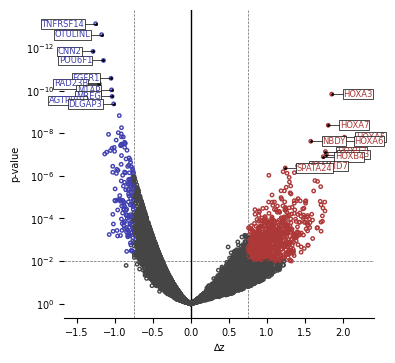

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SARM1""",null,-0.877701,null,-0.65171,-0.85041,null,-1.023292,-0.799344,1.636794,-1.022921,-1.039287,-0.972078,-0.662364,-0.903129,-0.862983,0.022863,-1.016854,-1.177662,null,0.614546,-0.790077,null,null,-0.351337,-1.139606,-0.76965,-0.24241,null,-0.991596,0.44202,-0.219142,-0.693387,0.357854,-0.887782,-0.181789,null,…,null,null,null,null,null,null,null,null,null,null,null,0.177006,1.829341,-0.777487,0.317893,-0.378989,null,null,1.584777,0.878849,1.318459,null,1.402476,0.024148,null,0.490286,null,1.45356,0.584368,0.449715,0.502989,null,1.866341,1.180483,null,0.9639,0.000145
"""DVL2""",null,0.97082,null,1.138095,-0.916933,null,0.382584,-0.725174,-0.184571,-0.419465,0.350802,-0.52162,-1.176702,-1.056591,0.778772,0.771227,-1.636757,-1.388091,null,-1.392316,-1.481718,null,null,1.44878,0.803229,-0.608768,-0.609173,null,-1.106106,-0.028363,0.056034,-0.454076,-0.253449,0.098832,0.425875,null,…,null,null,null,null,null,null,null,null,null,null,null,0.984728,2.398989,1.63255,0.035565,-0.627869,null,null,0.522642,0.860971,1.056407,null,1.600164,-0.667064,null,1.478116,null,1.310516,-1.010849,0.774023,0.005546,null,1.682686,0.618544,null,0.945335,0.001127
"""LIG3""",null,-0.151467,null,-0.33892,-0.489638,null,0.522734,-0.369341,-0.202582,-1.453795,-1.695998,-0.36646,-1.732867,-1.353166,-0.720057,-0.478218,-0.973628,-1.475048,null,1.113025,-1.823392,null,null,0.944806,-0.370645,0.732547,0.663157,null,-0.420892,1.729488,-0.551118,-0.543925,0.210022,-0.094932,0.860226,null,…,null,null,null,null,null,null,null,null,null,null,null,1.009836,2.024756,-0.073366,0.625371,-0.078605,null,null,0.509287,0.391246,1.221684,null,0.432412,-0.81632,null,1.352943,null,3.743926,0.041523,0.329605,0.751859,null,2.572171,0.706887,null,1.101417,0.000895
"""WDR54""",null,-0.509161,null,-0.310385,-1.388758,null,-0.177727,-0.379717,0.822861,-0.966683,0.025753,-0.146608,1.325045,-0.449613,-0.265709,-0.349708,-1.606747,-0.32512,null,-0.116603,-1.588371,null,null,-1.327487,-0.570411,-0.534638,-0.504323,null,0.30384,0.035633,0.887749,-0.889401,-0.93997,-0.360302,1.382969,null,…,null,null,null,null,null,null,null,null,null,null,null,0.109022,-0.890412,-0.541938,1.563398,0.526266,null,null,2.887537,0.810537,2.557424,null,0.814262,-0.480732,null,1.171199,null,1.639306,-0.00282,1.615946,1.022527,null,1.293784,0.15775,null,1.064654,0.000891
"""GDE1""",null,0.758226,null,0.260086,-1.268099,null,1.263094,-0.272044,0.017704,0.541863,-1.747178,-0.986999,-0.023057,-0.798709,2.638004,-0.051162,-0.869443,-0.453551,null,-1.910616,-0.82267,null,null,1.152661,-0.793509,-0.51519,-0.701861,null,0.552197,-0.687321,-0.122369,0.567641,-0.066183,-0.528979,-1.050659,null,…,null,null,null,null,null,null,null,null,null,null,null,1.396058,1.611347,2.788271,0.870785,-0.810908,null,null,1.000963,0.791108,0.325348,null,0.709463,1.292448,null,0.638681,null,0.008604,-0.423066,0.635391,0.37941,null,0.668425,1.114906,null,0.970848,0.000225
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ST7""",null,0.647423,null,2.509013,0.549558,null,-0.687299,-0.300414,-0.216114,-0.123449,1.20141,-0.941357,-1.016609,-0.6177,0.586022,0.415973,-0.60585,-0.811152,null,0.753136,-0.666466,null,null,1.034291,2.541823,0.605907,1.109047,null,-0.303913,1.676371,-0.112385,0.496539,0.654265,0.379471,-0.899235,null,…,null,null,null,null,null,null,null,null,null,null,null,-1.37069,-1.363661,-1.363733,-1.321576,-0.009784,null,null,-0.778901,-1.337348,-1.00753,null,-1.364083,-0.14939,null,-1.380552,null,-1.216278,-0.425584,-1.360068,-0.399639,null,-0.72057,-1.269721,null,-1.257823,5.8887e-10
"""KDM7A""",null,-0.366398,null,-0.726779,1.052546,null,-0.580649,0.481196,0.693235,1.142471,-1.060895,0.870381,-1.140374,-0.00304,-0.252134,0.180498,2.662563,0.606359,null,1.148474,2.302163,null,null,-0.318794,-0.904026,-0.746796,-0.311068,null,0.157268,-0.547705,-0.621326,-0.278208,1.191963,0.053336,-1.00754,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.961088,-1.238572,-0.000579,-0.664734,-0.867177,null,null,-0.59072,-0.661974,-0.151132,null,-1.443099,0.137198,null,-0.915028,null,-0.695443,-0.218841,-0.753128,-0.896816,null,-0.243197,-0.259806,null,-0.778647,0.000021
"""ELOVL5""",null,0.973571,null,1.706359,1.073595,null,0.363955,0.619425,1.699127,-0.148634,0.270305,-1.196692,-1.477024,-0.254172,-0.093943,0.79516,2.061339,-0.284704,null,2.099682,0.518171,null,null,2.836847,0.343133,0.759826,0.49527,null,-0.331627,-0.321524,-0.45419,0.212799,1.157903,-0.075967,-0.83564,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.898079,-0.625711,0.237027,-0.803125,-0.454659,null,null,-1.090791,-1.716811,-0.2759,null,-1.55175,-1.194278,null,-2.656985,null,-0.026292,0.71679,-1.218546,-1.76836,null,0.832613,-1.178773,null,-1.021373,0.000398
"""VAMP3""",null,1.723438,null,-0.430541,1.149889,null,-0.351758,1.435521,0.401263,2.306573,-0.269883,1.592967,0.333261,1.347897,1.278531,-0.575716,0.739966,-0.361481,null,0.036386,3.184092,null,null,-0.30796,0.017456,-0.214333,-0.244593,null,1.867143,-0.790548,-0.582291,-0.637798,0.08369,-0.182749,-0.650349,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.59718,-1.504459,-2.055268,-0.372003,-0.789094,null,null,-1.320974,-0.399647,-0.896968,null,-0.272945,0.511147,null,-1.056391,null,-0.890117,-0.087089,-0.468544,-0.471064,null,-0.159738,-0.541376,null,-0.849427,0.000072
"""NEDD4L""",null,2.457832,null,-0.751447,2.467761,null,-0.355211,-0.690596,0.224386,-0.884094,-0.338185,-0.615318,-0.689571,-0.495185,-0.205074,1.398168,0.104968,0.707849,null,0.92066,0.109943,null,null,-0.885007,-0.156141,3.216763,2.427635,null,-0.79122,-0.876334,-0.606353,1.709675,0.925339,-0.766745,-0.873531,null,…,null,null,null,null,null,null,null,null,null,null,null,-0.940121,-0.951287,-0.821633,-0.77306,-0.664477,null,null,-0.404115,-0.82274,0.046886,null,-0.910999,-0.441127,null,-0.950441,null,-0.482323,-0.770298,-0.409392,-0.63848,null,-0.366278,-0.803806,null,-0.829407,3.6070e-7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Proteomics


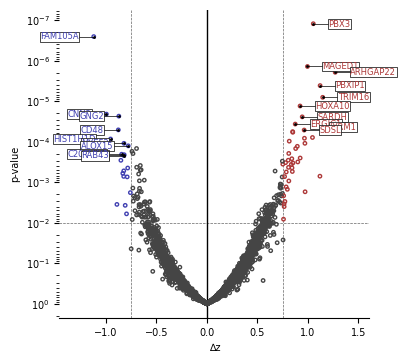

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADGRG1""",1.377401,-0.371549,0.717795,null,-0.194808,1.420212,-1.573961,-1.537496,null,0.169891,0.992116,null,0.356824,0.018623,-0.534473,null,null,-0.946527,null,-0.108994,-0.729932,-0.142326,null,-0.592618,-0.545647,null,-0.969994,0.12533,-0.309705,null,-1.94697,null,-0.977684,null,0.61907,-0.317783,…,-0.046654,0.496916,-1.529166,-1.899862,-0.573172,1.6672,1.7291,-0.76506,-1.329819,-0.66904,1.140037,null,2.065088,1.231095,0.651859,null,1.38798,null,-0.298425,0.469336,-0.056661,-2.076971,1.132417,0.444569,null,2.314613,1.71812,1.500289,0.397223,-0.021737,1.276081,-0.470223,-0.499625,0.84194,0.025464,0.773146,0.003
"""APLF""",-0.28655,0.980898,0.581386,-1.004123,-1.13031,-0.871536,-2.626024,-2.308031,-0.820428,1.278983,0.390156,0.051555,0.245205,-0.63325,1.277565,-1.076173,-1.974408,0.18465,0.280219,-0.20551,-0.595119,-0.191523,1.337315,1.116531,0.509908,0.297476,1.523569,0.602842,1.251904,0.074786,-1.137095,0.152531,-1.799887,0.461195,0.164781,-0.782304,…,-1.351228,-0.299254,-0.457024,-1.321323,0.527198,1.963999,0.739191,-0.03746,-1.459345,0.031006,0.819423,1.516412,2.300488,1.225262,-0.08074,1.169112,0.784102,0.610804,-0.476986,-0.14028,1.034443,-0.837511,1.377455,1.185101,-0.873528,0.148077,0.934223,1.475889,1.115903,0.052036,1.307083,-1.000971,0.540707,0.031366,1.071798,0.752451,0.00036
"""ARHGAP22""",null,0.285923,-0.18177,-0.989095,-0.21305,-0.585831,-1.779033,-1.672788,0.565205,-0.368538,1.407788,-0.038947,-0.183689,-0.417637,0.202544,null,-1.130992,-0.439154,0.166135,null,-0.55439,1.299964,null,-1.008907,-0.6324,-0.12958,null,0.241102,null,null,null,null,-0.992888,-0.49211,-0.020243,-0.808925,…,-1.715487,-0.293116,-1.212125,-1.387367,-0.043843,1.696012,2.270245,null,-2.114708,0.319425,0.595292,1.679291,2.549735,1.646576,null,0.748884,1.502666,null,0.419387,0.488808,null,-0.056595,1.120712,null,null,1.530612,1.532463,1.67701,0.39725,0.74258,1.131054,null,0.478591,0.405144,0.665008,1.271627,0.000002
"""ARSD""",0.888892,1.040769,0.359022,-0.840375,-0.272674,0.242891,-2.682395,-1.729053,-1.092958,1.052105,-0.692051,-0.051188,0.738922,-0.529355,0.828757,-0.434146,-1.324356,-0.610466,1.022369,0.31069,-0.981415,0.415248,0.275122,0.067241,0.75553,1.297221,0.585774,2.21662,0.455268,0.310904,-1.780126,0.402691,-1.662905,-0.37885,0.104663,-0.561713,…,-0.947382,1.321401,-1.259449,-0.935408,-0.325525,1.537104,-0.000537,-0.363587,-1.387719,-1.027416,0.616492,1.760376,1.635954,2.150112,-0.69594,0.774848,0.483947,-0.020263,1.193665,0.766772,0.420733,-0.266053,1.202583,1.251655,0.938435,-0.118817,1.606193,1.772043,1.830332,0.554868,0.957892,-0.391029,0.314195,-0.944041,1.268592,0.81138,0.000196
"""CLIC2""",1.40841,0.017617,1.531158,-1.230389,-0.427205,1.169975,-1.912761,-1.606824,-0.432858,-0.432386,-0.189796,-0.737218,-0.712425,0.312297,-1.284496,0.338025,-0.512669,0.018108,-0.580397,-0.243245,-0.581038,0.915674,-0.237371,-0.751022,-0.449132,-0.314913,-0.35387,0.876062,0.330894,-0.203011,-2.030618,0.924652,-0.571859,0.153112,-0.445021,0.106481,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALOX15""",0.421881,0.010444,0.300715,-0.92176,1.450358,null,-1.646735,0.794214,2.054851,0.32381,-0.0112,0.812095,-0.128585,null,null,null,-0.868774,1.784566,1.11359,-0.152888,-0.663797,-1.614076,null,0.700155,0.142577,0.389882,-0.009439,null,-0.109144,null,0.846568,-0.549757,0.022756,1.876385,-0.38103,0.96187,…,-0.934638,-0.642548,1.442805,-0.980915,-0.155709,null,-0.834958,-1.614948,null,-0.844031,-0.631309,-0.407092,-0.464178,null,0.487822,-0.181005,-0.615086,null,-1.407629,-0.728235,-1.474986,null,-0.516914,-0.324389,-1.701874,null,0.493636,0.151357,null,null,null,-0.439377,-1.020302,null,-0.015285,-0.779639,0.000127
"""BCL6""",-0.182264,null,1.04252,-1.114184,1.036601,null,null,null,-0.218647,1.942779,null,0.426058,null,0.859838,null,null,null,0.619472,0.272067,1.213514,0.348385,0.115988,null,-1.461926,-0.132212,0.43844,1.073052,null,1.957417,null,-1.116658,1.025598,0.600788,-0.373905,0.314657,-0.575695,…,-0.319587,0.15154,-0.077641,0.083441,1.378154,1.314226,-0.654235,0.010761,-0.035044,-0.844392,null,-0.430087,-0.983697,null,null,null,-0.215898,null,-2.335297,null,-1.443097,-1.080138,null,null,-2.637538,-1.153884,-0.070828,-1.168396,0.851372,-0.991955,0.561245,null,null,-1.148932,0.697695,-0.809757,0.00374
"""C20orf27""",-0.83434,0.58023,1.341475,-0.881558,-0.115389,1.146385,-1.626438,-0.381963,0.64933,1.757133,-0.100551,0.834706,1.36702,0.768001,0.091013,1.068959,-0.313798,0.121983,0.920367,0.719167,0.515028,-1.138891,0.037716,-0.687378,0.578097,0.391474,-0.089089,0.407996,1.178069,-0.142988,-1.38216,1.03941,0.297943,0.616706,0.18651,-1.3196,…,0.755122,0.316005,0.481702,1.501058,2.469032,0.170655,-0.575546,-0.609164,-2.035461,-2.066141,0.119942,-0.636706,0.894596,0.934913,-0.479236,-0.070103,-1.327596,-0.534146,-1.882158,-0.659702,-2.265874,-1.902479,-0.795756,1.110442,-1.53883,-0.934146,-0.166327,0.012855,1.286027,-0.583868,0.60284,-1.631773,-1.133341,-1.831588,-0.025758,-0.844709,0.000205
"""CD48""",0.479721,0.202705,0.988355,0.001226,0.347998,1.853086,-0.887838,-0.101618,-1.015071,2.79858,-0.013002,1.245144,-0.227892,0.226599,0.976049,-0.43797,-0.682694,0.745398,1.006068,0.919003,0.164343,-0.720944,0.789524,0.651684,0.931815,-0.238939,0.523046,-0.026567,-0.15467,-0.882883,-1.13541,1.687161,-0.043301,0.390557,0.254651,-0.672034,…,-2.473251,1.355426,-1.563791,0.27448,0.760085,0.129103,-1.097013,-1.11269,-0.97315,-2.169992,1.386704,-0.583884,-0.349384,0.085964,-0.597298,0.070217,-0.507906,0.160406,-1.79254,0.073192,-2.165527,-2.418812,-0.620239,1.044523,-2.154963,-0.965954,-0.536582,-0.213166,0.732421,-1.029686,-0.332885,-0.657734,-1.591107,-0.663386,-0.433651,-0.878017,0.000051
"""CLEC5A""",-0.078711,-0.22392,1.454079,-0.678551,0.800478,null,-1.619105,-0.509167,1.142918,0.995437,null,0.514463,0.241784,0.829307,null,0.797743,0.401227,0.230801,2.076071,0.95486,0.625906,-0.635721,-0.535541,-0.941392,1.071635,-0.255969,-0.552149,null,1.337072,-0.100213,-1.295931,1.338503,0.404061,1.746889,0.574113,-0.156238,…,-0.563571,-0.622566,1.114

Phosphoproteomics


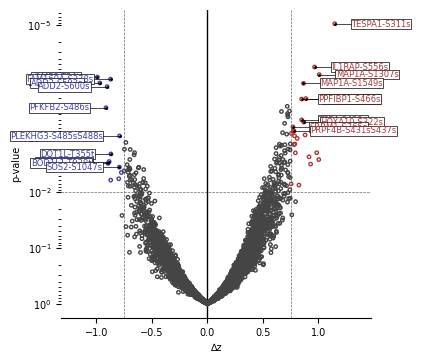

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ATN1-S101s""",0.580361,1.186735,null,-0.914622,null,null,null,-2.602384,-0.420851,null,1.287474,0.455979,0.516913,null,null,-0.33948,-0.238197,null,1.63862,null,null,null,0.334395,-0.981585,null,-0.864721,0.616412,null,null,0.429904,null,null,-1.995657,0.295136,null,null,…,-0.048874,-0.974941,-0.23387,-0.560614,-0.416809,null,1.181058,null,null,-0.97215,1.584444,0.970052,null,null,0.835576,1.328428,null,1.293737,null,-0.170869,null,null,1.059899,1.502549,null,null,0.85869,null,null,null,null,-1.3452,0.046874,null,0.808084,0.824801,0.007416
"""BEGAIN-S465s""",-0.624267,0.708133,0.456449,-1.189836,null,-0.00125,-2.623077,-1.252202,-0.545639,null,null,-0.187142,-0.220925,-1.188941,-0.346498,-1.732609,null,-0.42976,0.817922,null,-0.505343,-0.536836,-0.187983,-0.361085,null,0.849502,0.564158,0.403524,null,0.507099,null,null,-1.181645,-0.571236,-0.051846,null,…,null,0.941776,0.281368,-0.527056,null,1.595357,2.33504,null,-1.987151,null,null,2.816047,null,-0.096491,null,0.269911,null,1.014958,null,-0.200452,null,0.739206,1.152124,null,null,0.39793,1.066836,2.209342,0.053036,-0.840978,0.402098,null,1.464677,0.946789,0.297427,0.985036,0.001946
"""GLYR1-S149s""",0.71727,0.425177,0.182595,null,-0.603588,-0.777168,-1.026432,-1.306666,null,1.401682,null,null,-0.070003,null,-1.336056,0.273047,null,0.348532,null,-0.703614,-0.510707,0.277416,-0.142634,1.320825,-0.917553,null,-0.231819,1.366761,-0.22711,-1.491513,-1.858091,-0.742745,-1.740734,null,-0.300204,-1.294693,…,0.868889,-0.331018,-1.854379,-1.266042,-1.319801,null,0.697124,-0.56704,null,null,null,null,1.330726,0.745571,1.073215,null,0.727848,1.054415,0.758012,0.329571,1.764404,null,1.120219,-0.010182,1.787348,null,0.895985,1.35996,null,null,null,-2.150507,2.021388,null,0.320204,0.969171,0.000821
"""HOXA10-S322s""",null,-0.411263,0.263777,-1.299794,null,0.00959,-1.27091,null,-0.992101,null,-0.586862,-0.878338,0.402348,-1.272461,1.265286,-0.077457,null,-0.073738,0.387837,null,-0.158545,0.314319,0.036983,-1.151599,null,-0.493006,null,-0.150712,null,-0.992978,null,-0.892442,null,-0.520482,1.366697,null,…,1.403644,1.222015,-1.311489,-0.169863,-0.993082,0.221792,1.93186,null,-1.926187,null,1.915618,1.286183,null,0.285843,-0.042914,1.112461,null,0.144691,null,0.802969,null,-0.089805,1.935295,1.705833,0.472567,1.052677,0.85152,1.049741,1.09077,0.377671,0.552898,-1.107895,0.692198,-0.167705,null,0.867778,0.00055
"""IL1RAP-S556s""",-0.149495,0.740201,null,-1.077919,null,-0.479561,-2.211759,-1.015795,-2.0698,1.136244,-0.408955,0.403774,-0.236816,0.188747,0.805714,-1.456177,-1.951795,null,0.948427,null,null,null,0.448414,-0.963445,0.364783,0.474051,0.473709,0.217703,null,0.18255,null,0.188364,-1.85543,0.222584,null,-0.29454,…,-0.860908,0.711389,-1.476991,-1.09256,-1.25054,1.445136,0.087096,null,-1.025683,-0.475203,1.268634,2.199202,null,2.155831,null,0.88765,0.158161,1.44693,null,0.671802,null,0.239208,1.144921,null,-0.404804,0.755915,1.397692,null,1.541575,-0.118708,0.825238,null,0.019275,0.70366,0.886799,0.9

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADD2-S592s""",null,null,0.414568,0.649921,null,-0.538859,null,null,null,0.629677,-0.594816,-1.48992,null,-0.829766,2.016121,0.668817,-0.56642,-0.103002,0.509603,1.283547,-1.078652,-1.037008,1.081835,null,1.093503,0.969143,null,0.16235,1.278457,1.173548,-1.424167,null,null,null,0.741767,0.499561,…,1.267656,0.462108,0.9745,1.084059,-1.599759,-0.238362,null,-1.083158,-1.438435,-1.208164,-0.785202,null,null,-0.482439,null,0.792653,-1.146026,-0.636097,null,null,-1.892419,-1.768298,null,null,null,-0.879078,null,0.509753,-0.135933,-0.831133,-0.00009,null,null,-1.511166,-0.025272,-0.969211,0.000109
"""ADD2-S600s""",-0.100718,null,null,-0.457858,1.881499,null,null,null,0.571571,-0.055998,-0.027594,0.037094,null,-0.773464,null,0.754194,null,null,0.231224,null,null,null,1.134569,1.721355,1.110114,-0.187038,0.941827,null,null,2.997431,null,-0.051676,-1.228318,-0.525708,null,0.484497,…,0.584661,0.54812,0.196405,0.366724,null,-0.621426,-0.056421,null,-1.798013,null,-1.012071,-0.442873,-0.757679,null,0.887009,null,-2.198424,0.5445,-1.314272,null,null,-0.801971,null,-0.461267,-1.406909,-0.921129,0.291162,null,0.057346,-0.685867,-0.128724,-1.212461,null,-1.410121,-0.140351,-0.903556,0.000127
"""BOD1L1-T938t""",-0.305435,null,1.282518,-0.322041,0.60817,-0.03251,null,null,-0.085903,1.168495,1.7369,0.219528,null,-0.802612,0.787392,-0.496382,null,-0.25516,0.633378,0.753349,-0.373711,-0.694497,0.981389,null,1.039696,-0.281467,1.002709,0.138303,0.680056,-0.142189,-0.78817,0.721896,null,-0.032197,1.052389,-0.551667,…,0.522001,-0.02047,0.486305,-0.84826,0.013163,1.114912,null,-0.449288,-2.287036,null,0.139199,0.820392,-1.002652,-0.081314,-0.544389,null,-1.105185,-0.102835,-2.234697,null,-3.073652,-1.812506,null,0.578439,-3.010906,-0.131726,null,0.548198,1.025456,-1.341927,0.018108,-1.087343,null,-1.498753,0.357896,-0.8961,0.003028
"""DAPK2-S299s""",null,0.225715,-0.364162,-0.502505,0.00525,null,-1.741909,-0.980086,0.752447,null,null,0.876286,-0.447576,0.277837,null,null,null,-1.266984,1.449155,0.971556,0.731948,-0.806484,null,-0.115534,null,-0.015567,null,null,0.091845,null,-0.24005,-0.197939,0.974115,1.658998,-0.091498,null,…,-0.677618,0.653584,0.265304,0.516415,-0.107486,-0.239013,-1.138032,-1.126628,-1.257841,-1.14375,null,-0.026911,-0.416205,null,0.098913,null,null,null,-1.951508,1.056648,-1.630192,null,-0.817386,0.217108,-2.292628,-1.437264,-0.565003,0.26236,0.533558,-0.275735,1.857513,null,-0.759291,-2.185494,0.945372,-0.775417,0.004413
"""DOT1L-T355t""",0.180427,null,null,null,0.506971,null,null,null,-0.406614,null,null,null,null,-1.147497,null,-0.35055,null,null,null,1.198818,null,null,0.153516,0.50991,null,null,0.659683,null,0.752571,0.773906,-0.699555,0.064208,-0.356733,0.84357,null,null,…,null,0.524663,0.014274,-1.151994,null,-0.750654,0.754146,0.096131,null,-1.913431,null,-0.066758,-1.240867,null,null,null,null,-0.747987,-0.966696,null,-2.907581,-1.066325,null,null,-1.139467,-0.633731,0.12386,null,0.638488,-0.633731,0.163012,null,null,-0.78673,0.20520

Lipidomics


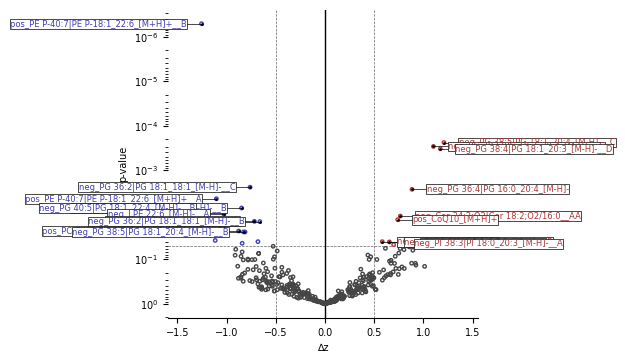

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 20:2_[M-H]-__B""",1.135775,1.841093,0.978365,0.179813,1.540997,0.296066,-1.081014,-0.15207,-1.620128,-0.566186,-0.42478,0.597902,-0.268859,0.952543,0.05369,-0.096104,-1.680746,0.640716,0.79093,-2.549281,-0.296414,null,-1.547479,-0.074639,-1.741333,-1.0055,-0.915579,null,null,null,-1.18457,null,null,null,null,null,…,null,null,null,null,null,0.294427,null,null,null,null,0.458001,0.65847,0.886586,1.226724,null,null,null,null,null,null,null,0.315574,null,null,null,null,null,null,-0.415915,null,null,null,null,null,null,0.581661,0.040279
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-0.743886,1.123634,1.98482,-1.15378,-1.016881,-0.576549,-0.099197,-2.331863,-1.292387,1.34881,-0.186137,-0.045886,-1.638487,-0.045185,0.033684,1.650144,-1.008628,-0.733247,0.747037,1.10399,-0.738727,null,0.862671,-0.066471,-0.113485,0.522803,-0.931117,null,null,null,1.226205,null,null,null,null,null,…,null,null,null,null,null,0.504463,null,null,null,null,0.969242,0.340214,1.024657,1.540559,null,null,null,null,null,null,null,1.530025,null,null,null,null,null,null,0.575056,null,null,null,null,null,null,1.101566,0.000293
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-0.316126,0.085681,-0.196974,-1.008608,-0.777241,-1.061408,1.182961,-0.160641,-2.257265,0.278395,1.292951,-0.16027,-0.810914,1.388575,0.108181,1.283117,0.398503,-0.204988,1.366758,1.248989,-0.630652,null,-0.431755,0.935859,-0.385109,-0.875959,-0.493212,null,null,null,0.682433,null,null,null,null,null,…,null,null,null,null,null,0.152133,null,null,null,null,1.401876,0.638478,0.657436,1.462419,null,null,null,null,null,null,null,0.417319,null,null,null,null,null,null,0.47391,null,null,null,null,null,null,0.884004,0.002691
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.041531,0.263501,2.084381,-1.331206,-1.075364,-0.450082,0.000525,-1.60006,-1.7418,1.128955,0.045585,0.443526,-1.805042,-0.540163,-0.487176,1.416679,-0.339389,-1.004379,-0.279032,0.795419,-1.031467,null,1.837889,-0.186379,-0.509573,0.127642,-0.73979,null,null,null,0.55845,null,null,null,null,null,…,null,null,null,null,null,0.003056,null,null,null,null,1.016435,0.720668,1.128402,1.305097,null,null,null,null,null,null,null,1.557361,null,null,null,null,null,null,1.382652,null,null,null,null,null,null,1.2085,0.000239
"""neg_PI 36:3|PI 18:1_18:2_[M-H]…",-0.393367,-0.031553,-1.432235,-1.927836,0.142251,0.027424,0.567251,-2.191872,-1.031933,0.760279,-0.005306,-0.557024,-0.97634,-0.395788,0.341437,2.895639,-0.907268,0.438861,0.164749,0.382791,-0.587942,null,1.512299,-1.037893,-0.376137,-0.529823,-1.458495,null,null,null,1.523288,null,null,null,null,null,…,null,null,null,null,null,0.819009,null,null,null,null,0.067673,0.604233,-0.004663,1.714621,null,null,null,null,null,null,null,0.646317,null,null,null,null,null,null,0.002306,null,null,null,null,null,null,0.653969,0.040813
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""neg_PI 38:3|PI 18:0_20:3_[M-H]…",-0.543239,-1.266258,-

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 22:6_[M-H]-__A""",-0.460707,0.896676,-1.697031,1.489828,0.613906,1.00602,0.935023,1.587102,1.561234,-1.229779,0.99351,0.931242,0.896037,-1.473138,-0.663125,-0.821631,-0.284194,1.336353,-0.626367,-0.276427,-0.113798,null,-0.22428,0.229311,2.403452,-0.781932,1.12162,null,null,null,-0.268657,null,null,null,null,null,…,null,null,null,null,null,-0.271974,null,null,null,null,-1.348836,0.558816,-1.471615,-1.054741,null,null,null,null,null,null,null,-1.413696,null,null,null,null,null,null,-1.042,null,null,null,null,null,null,-1.026788,0.009767
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.221729,-3.150554,0.518126,0.593269,-1.122698,0.908136,0.397297,-1.057737,0.891119,1.949008,-0.16094,-0.262276,0.968426,-1.788961,0.833445,-1.056018,0.172965,0.893796,0.654319,2.109382,0.596242,null,-0.742359,0.318646,-0.071093,0.48673,-0.13294,null,null,null,-0.435933,null,null,null,null,null,…,null,null,null,null,null,0.493691,null,null,null,null,-0.169882,-1.569149,-1.158134,-1.312315,null,null,null,null,null,null,null,-0.640098,null,null,null,null,null,null,-0.516752,null,null,null,null,null,null,-0.827784,0.024359
"""neg_PG 40:5|PG 18:1_22:4_[M-H]…",-0.169529,-3.493045,-1.059181,1.955363,-0.347865,0.680773,0.317906,0.396517,0.441727,0.508429,0.121531,0.435771,0.080429,-0.664657,-0.005128,0.056043,0.773235,0.912779,0.188114,0.187809,0.948459,null,-0.721974,0.618494,-0.820202,0.848913,0.810439,null,null,null,-0.762324,null,null,null,null,null,…,null,null,null,null,null,-1.487757,null,null,null,null,null,-1.319933,-0.093319,-1.914296,null,null,null,null,null,null,null,-0.883427,null,null,null,null,null,null,-0.307328,null,null,null,null,null,null,-1.163336,0.007109
"""neg_PG 36:2|PG 18:1_18:1_[M-H]…",-0.004674,-2.110579,-0.147511,-0.068673,-0.671968,2.290811,-0.017434,-0.159789,2.015521,0.505258,-0.235829,0.333534,-0.115154,-1.48738,-0.685858,-1.105352,-0.220154,0.769541,-0.223767,1.405337,0.035764,null,-0.766064,-0.381353,0.025161,0.112833,-0.337126,null,null,null,-0.856927,null,null,null,null,null,…,null,null,null,null,null,-0.281826,null,null,null,null,-1.097182,-0.224553,-1.22478,-0.732696,null,null,null,null,null,null,null,-0.303329,null,null,null,null,null,null,-0.032061,null,null,null,null,null,null,-0.661941,0.014264
"""neg_PG 36:2|PG 18:1_18:1_[M-H]…",0.202628,-1.898118,0.006535,-0.373228,-0.643133,2.51688,-0.064162,-0.318887,1.818364,0.366882,-0.312586,0.163471,-0.38312,-1.254914,-0.32738,-1.123116,-0.27874,0.723201,-0.24322,1.064382,0.351247,null,-0.78281,-0.302626,-0.310351,0.372929,-0.644205,null,null,null,-0.588226,null,null,null,null,null,…,null,null,null,null,null,-0.390204,null,null,null,null,-1.058397,-0.099061,-1.091483,-0.599707,null,null,null,null,null,null,null,-0.90995,null,null,null,null,null,null,-0.333287,null,null,null,null,null,null,-0.761436,0.002411
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""pos_LPC 22:6_[M+H]+""",-1.7087,

Metabolomics


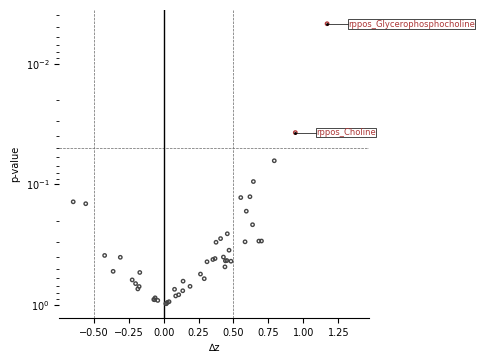

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Glycerophosphocholine""",-1.525368,-0.490655,0.218077,0.393941,-0.526777,-1.18809,-0.03048,-0.644415,-1.70884,0.976253,2.559148,-1.544796,1.358663,1.783964,0.144447,0.044546,-0.753339,-1.460808,-0.006744,0.887762,-1.196113,null,-0.354707,-0.382567,-0.575947,-0.049314,-0.469316,null,null,null,0.283644,null,null,null,null,null,…,null,null,null,null,null,-0.161068,null,null,null,null,1.239456,1.14183,1.274865,0.21274,null,null,null,null,null,null,null,2.116387,null,null,null,null,null,null,1.06117,null,null,null,null,null,null,1.169717,0.004679
"""rppos_Choline""",0.816674,0.123737,0.179857,0.008195,-0.681301,-0.723329,-0.11092,-0.389458,0.129536,-0.655214,1.458238,-0.601165,0.4546,2.706476,-0.326051,-0.007612,-0.414137,-0.722305,-1.197313,1.61168,-1.19024,null,-0.782432,-0.184384,-1.297634,-0.998926,-0.85799,null,null,null,-0.923552,null,null,null,null,null,…,null,null,null,null,null,1.110494,null,null,null,null,0.189745,1.234211,-0.055479,-0.303664,null,null,null,null,null,null,null,2.373437,null,null,null,null,null,null,0.998404,null,null,null,null,null,null,0.942373,0.037314


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,16-00306,…,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge,delta_z,ttest_p
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


In [7]:
# key: (subset_id, block)
# value: {"up": top_n_up_df, "down": top_n_down_df}
top_up_and_down = {}

for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    print("============", subset_id, "============")
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Acetylomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        if (df := comps.get((subset_id, block))) is not None:
            print(block)
            top_up, top_down = plot_volcano_and_select_top_features(
                df,
                # use slightly less stringent criteria for the lipidomics and 
                # metabolomics data to get more significant features
                0.5 if block in ["Lipidomics", "Metabolomics"] else 0.75, 
                0.05 if block in ["Lipidomics", "Metabolomics"] else 0.01,
                subset_id,
                block
            )
            display(top_up)
            display(top_down)
            top_up_and_down[(subset_id, block)] = {"up": top_up, "down": top_down}

### Compare counts of selected features between black and white patients

#### NPM1

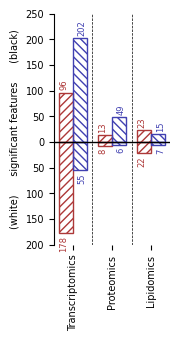

In [8]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITD

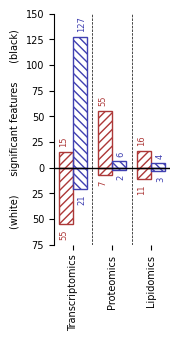

In [9]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITD-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITDxNPM1 vs. WT

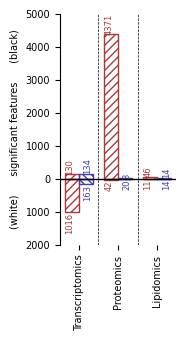

In [10]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITDxNPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()
